# Notebook 8 – Cost-Benefit Analysis (CBA) and Budget Optimization

This notebook integrates outputs from three policy notebooks (AC, EWS, Trees)
to perform a comprehensive cost-benefit analysis and budget optimization.

## Overview

This notebook performs a comprehensive Cost-Benefit Analysis (CBA)
comparing three heat adaptation policies for Copenhagen:

1. **Air Conditioning (AC)** - Private adaptation, reduces vulnerability  
   through indoor cooling

2. **Early Warning Systems (EWS)** - Public intervention, reduces vulnerability  
   through heat alerts

3. **Urban Vegetation (Trees)** - Public infrastructure, reduces hazard  
   through outdoor cooling

Methodological framing for Copenhagen:
- **Track A (standard)** keeps the baseline cross-city workflow for comparability, but policy runs are disabled in this city setup.
- **Track B (extreme-event)** uses the heatwave/event hazard workflow and is the policy-analysis track used in this notebook.
- This notebook reads whichever track is selected by `HAZARD_TRACK` (defaulting to Track B when enabled in config), so all CBA outputs below must be interpreted in that selected-track context.

In [1]:
import os
os.environ["URBAN_HEAT_OUTPUT_VARIANT"] = "masselot_main_agnostic"
os.environ["IF_MAIN_FAMILY"] = "masselot_tail"


In [2]:
# City selector - the ONLY per-city line in this agnostic notebook.
# Set CITY to rome / athens / lisbon / copenhagen (any configured city).
import os
os.environ["CITY"] = "Rome"


In [3]:
# generic bootstrap 
from pathlib import Path
import os, sys

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand/"cityheat").is_dir() and (cand/"configs").is_dir():
            return cand
    raise RuntimeError("Repo root not found.")
ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup_masselot_main import bootstrap
from cityheat.paths import make_P, ensure_out

# choose city here
SLUG = globals().get("SLUG", os.environ["CITY"]).lower()

C    = bootstrap(SLUG)      # reads configs/<slug>.yml and syncs that city only if wanted
CFG  = C["CFG"]; CITY = C["CITY"]
BASE = C["BASE"]; OUT = C["OUT"]; INT = C["INT"]

P    = make_P(BASE)         # read-only path helper
OUTP = ensure_out(OUT)      # write-safe path helper
print(f"→ City: {CITY}  |  BASE={BASE}  OUT={OUT}  INT={INT}")

→ City: Rome  |  BASE=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/data/Rome  OUT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main_agnostic/rome  INT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main_agnostic/rome/interim


In [4]:
# city config + file paths from YAML 
cfg = C.get("cfg", {})                      # full YAML for the selected city
SLUG = cfg.get("slug", SLUG).lower()        
CITY = cfg.get("city_name", CITY)

paths    = cfg.get("files", {})             # {gvi_csv, lcz_candidates, cooling_coeffs_csv, ...}
osm_cfg  = cfg.get("osm", {})               # OSM settings used later in NB5
trees_cfg = cfg.get("trees", {})            # TARGET/CAP for NB5
urbclim   = cfg.get("urbclim", {})          # UrbClim folder/settings for NB5

lcz_candidates = [P(p) for p in paths.get("lcz_candidates", [])]
gvi_path = P(paths.get("gvi_csv", ""))

# FUA geopackage written in NB2 
fua_gpkg = Path(paths.get("fua_gpkg", f"{OUT}/{SLUG}_fua.gpkg"))

cool_csv = P(paths.get("cooling_coeffs_csv", ""))

# checks
print("SLUG/CITY:", SLUG, CITY)
print("GVI CSV:  ", gvi_path)
print("LCZ cand: ", [str(p) for p in lcz_candidates])
print("FUA GPKG: ", fua_gpkg)
print("Cooling CSV:", cool_csv)

SLUG/CITY: rome Rome
GVI CSV:   /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/data/Rome/gvi/gvi_356_cities.csv
LCZ cand:  ['/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/data/Rome/LCZ/lcz_filter_v3.tif', '/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/data/Rome/LCZ/lcz_v3.tif']
FUA GPKG:  /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main_agnostic/rome/rome_fua.gpkg
Cooling CSV: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/data/Rome/CoolingEff/coefs_GVI_lst.csv


In [5]:
# Standard imports
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Set paths
OUT = Path(OUT)
INT = Path(INT)
TAB_DIR = OUT / "tables"
FIG_DIR = OUT / "figures"
TAB_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Tables: {TAB_DIR}")
print(f"Figures: {FIG_DIR}")

Tables: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main_agnostic/rome/tables
Figures: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main_agnostic/rome/figures


## CBA Parameters

These are the core economic parameters used throughout the analysis.

In [6]:
# CBA PARAMETERS

cba_cfg = cfg.get("cba", {}) or {}
trees_cfg = cfg.get("trees", {}) or {}
ac_cfg = cfg.get("ac", {}) or {}

# Discount rate and time horizon
R = float(cba_cfg.get("discount_rate", 0.03))
T = int(cba_cfg.get("horizon_years", 25))

# Tree maturity parameters
TREE_RAMP_YEARS = int(trees_cfg.get("ramp_years", 12))
TREE_START_AGE_CENTRAL = int(trees_cfg.get("start_age_central_years", 5))
TREE_START_AGE_SENS = int(trees_cfg.get("start_age_sensitivity_years", 0))
TREE_LIFETIME = int(trees_cfg.get("lifetime_years", 25))

# Tree cost parameters
CAPEX_PER_INDEX_PT = float(trees_cfg.get("capex_per_index_pt_eur", 10_000_000.0))
CAPEX_PER_TREE = float(trees_cfg.get("capex_per_tree_eur", 210.0))
OM_PER_TREE_YR = float(trees_cfg.get("om_per_tree_per_year_eur", 27.0))
OM_PER_INDEX_PT_YR = (OM_PER_TREE_YR / CAPEX_PER_TREE) * CAPEX_PER_INDEX_PT if CAPEX_PER_TREE > 0 else 0.0

# Tree O&M sensitivity
TARGET_OM_TO_CAPEX_PV_RATIO = float(cba_cfg.get("target_om_to_capex_pv_ratio", 5.0))

# AC cost parameters
AC_CAPEX_PER_USER = float(ac_cfg.get("capex_per_user", 500.0))
AC_MAINT_RATE = float(ac_cfg.get("maint_rate", 0.05))
AC_LIFETIME_YEARS = int(ac_cfg.get("lifetime_years", 10))
TARIFF_EUR_PER_KWH = float(ac_cfg.get("tariff_eur_per_kwh", ac_cfg.get("tariff_eur_kwh", 0.25)))

# Region label used in vegetation outputs (NB7)
VEG_REGION_LABEL = str(trees_cfg.get("veg_region_label", "Region"))

print("="*70)
print("CBA PARAMETERS")
print("="*70)
print(f"Discount rate:        {R*100:.0f}%")
print(f"Time horizon:         {T} years")
print(f"Tree maturity ramp:   {TREE_RAMP_YEARS} years")
print(f"Tree starting age:    {TREE_START_AGE_CENTRAL} years (central)")
print(f"CAPEX per GVI point:  €{CAPEX_PER_INDEX_PT/1e6:.0f}M")
print(f"O&M per GVI pt/yr:    €{OM_PER_INDEX_PT_YR/1e6:.2f}M")
print(f"AC CAPEX per user:    €{AC_CAPEX_PER_USER:.0f}")
print(f"AC lifetime:          {AC_LIFETIME_YEARS} years")
print(f"Electricity tariff:   €{TARIFF_EUR_PER_KWH:.2f}/kWh")
print("="*70)
print("(Loaded from cfg.cba / cfg.trees / cfg.ac with hardcoded fallbacks)")


CBA PARAMETERS
Discount rate:        3%
Time horizon:         25 years
Tree maturity ramp:   12 years
Tree starting age:    5 years (central)
CAPEX per GVI point:  €10M
O&M per GVI pt/yr:    €1.29M
AC CAPEX per user:    €500
AC lifetime:          10 years
Electricity tariff:   €0.25/kWh
(Loaded from cfg.cba / cfg.trees / cfg.ac with hardcoded fallbacks)


## Discount and Annuity Helpers

Standard present value and equivalent annual cost calculations.

In [7]:
# DISCOUNT HELPERS

def pv_level_flow(annual, r=R, T=T):
    """PV of a constant annual amount paid at end of years 1..T."""
    yrs = np.arange(1, T+1, dtype=float)
    return float(np.sum(annual * (1 + r) ** (-yrs)))

def pv_from_stream(stream, r=R):
    """PV of an arbitrary cashflow stream (length T)."""
    T_local = len(stream)
    yrs = np.arange(1, T_local+1, dtype=float)
    return float(np.sum(np.asarray(stream, float) * (1 + r) ** (-yrs)))

def annuity_factor(r=R, T=T):
    """Present value of €1 per year for T years."""
    return (1 - (1 + r) ** (-T)) / r

def pv_replacements(n_items, capex_per_item, r=R, T=T, life=20):
    """PV of buying n_items at t=0 and replacing every 'life' years."""
    pv = 0.0
    t = 0
    while t <= T:
        pv += n_items * capex_per_item / ((1+r)**t if t > 0 else 1.0)
        t += life
    return float(pv)

# Compute annuity factor
AF = annuity_factor(R, T)
print(f"Annuity factor (r={R*100:.0f}%, T={T}): {AF:.4f}")

Annuity factor (r=3%, T=25): 17.4131


# SECTION 1: DATA LOADING

Load pre-computed outputs from the three policy notebooks:
- NB5: AC policy costs, coverage, electricity, waste heat parameters
- NB6: EWS costs and benefits
- NB7: Trees costs and benefits

## 1.1 Load AC Data (from NB5)

In [8]:
print("="*70)
print("SECTION 1.1: AC POLICY DATA (from NB5)")
print("="*70)

# AC cost parameters
ac_cost_path = INT / f"ac_cost_params_{SLUG}.json"
if ac_cost_path.exists():
    with open(ac_cost_path) as f:
        ac_cost_params = json.load(f)
    tariff_loaded = ac_cost_params.get("tariff_eur_per_kwh", ac_cost_params.get("tariff_eur_kwh", TARIFF_EUR_PER_KWH))
    ac_cost_params["tariff_eur_per_kwh"] = float(tariff_loaded)

    print(f"✓ Loaded: {ac_cost_path.name}")
    print(f"  CAPEX/user: €{ac_cost_params.get('capex_per_user', AC_CAPEX_PER_USER)}")
    print(f"  Tariff: €{ac_cost_params['tariff_eur_per_kwh']}/kWh")
else:
    print(f"⚠ Using defaults (file not found: {ac_cost_path.name})")
    ac_cost_params = {
        "capex_per_user": AC_CAPEX_PER_USER,
        "maint_rate": AC_MAINT_RATE,
        "lifetime_years": AC_LIFETIME_YEARS,
        "tariff_eur_per_kwh": TARIFF_EUR_PER_KWH,
    }

# Municipality coverage by year (for AC cost calculation)
muni_cov_path = OUT / f"{SLUG}_muni_cov_yearly.csv"
if muni_cov_path.exists():
    muni_cov_yearly = pd.read_csv(muni_cov_path)
    print(f"✓ Loaded: {muni_cov_path.name} ({len(muni_cov_yearly)} rows)")
else:
    # Fallback to allpol version
    muni_cov_path = INT / f"{SLUG}_muni_cov_yearly_allpol.csv"
    if muni_cov_path.exists():
        muni_cov_yearly = pd.read_csv(muni_cov_path)
        print(f"✓ Loaded: {muni_cov_path.name} ({len(muni_cov_yearly)} rows)")
    else:
        raise FileNotFoundError("AC coverage data not found")

# AC electricity consumption by municipality
muni_kwh_path = OUT / f"{SLUG}_muni_ac_consumption_summary.csv"
if muni_kwh_path.exists():
    muni_kwh = pd.read_csv(muni_kwh_path)
    print(f"✓ Loaded: {muni_kwh_path.name} ({len(muni_kwh)} rows)")
else:
    raise FileNotFoundError(f"AC consumption data not found: {muni_kwh_path}")


SECTION 1.1: AC POLICY DATA (from NB5)
✓ Loaded: ac_cost_params_rome.json
  CAPEX/user: €500.0
  Tariff: €0.25/kWh
✓ Loaded: rome_muni_cov_yearly.csv (64 rows)
✓ Loaded: rome_muni_ac_consumption_summary.csv (60 rows)


## 1.2 Load Waste Heat Feedback Parameters (from NB5)


In [9]:
print("\n" + "="*70)
print("SECTION 1.2: WASTE HEAT FEEDBACK PARAMETERS (from NB5)")
print("="*70)

# Load waste heat parameters from NB5 (single source of truth)
wasteheat_path = INT / f"wasteheat_params_{SLUG}.json"
if wasteheat_path.exists():
    with open(wasteheat_path) as f:
        wasteheat_params = json.load(f)
    
    USE_AC_FEEDBACK = wasteheat_params.get("use_feedback", True)
    DELTA_T_CASE = wasteheat_params.get("lut_case", "central")
    DAILYMEAN_FROM_NIGHT = float(wasteheat_params.get("dailymean_from_night", 0.50))
    AC_WASTEHEAT_LUT = {float(k): v for k, v in wasteheat_params.get("lut", {}).items()}
    
    # COP degradation (Kou et al. 2026)
    COP_DEGRADATION_ENABLED = wasteheat_params.get("cop_degradation_enabled", False)
    COP_SENSITIVITY_DICT = wasteheat_params.get("cop_sensitivity", {"low": 0.04, "central": 0.065, "high": 0.09})
    COP_REF = float(wasteheat_params.get("cop_ref", 3.0))
    
    print(f"✓ Loaded: {wasteheat_path.name}")
    print(f"  LUT case: {DELTA_T_CASE}")
    print(f"  Night-to-daily factor: {DAILYMEAN_FROM_NIGHT}")
    print(f"  COP degradation: {COP_DEGRADATION_ENABLED}"
          f" (sensitivity={COP_SENSITIVITY_DICT}, COP_ref={COP_REF})")
    print(f"  Sources: {wasteheat_params.get('lut_source', 'n/a')}, "
          f"{wasteheat_params.get('cop_source', 'n/a')}")
else:
    print(f"⚠ NB5 wasteheat_params not found — using hardcoded defaults")
    USE_AC_FEEDBACK = True
    DELTA_T_CASE = "central"
    DAILYMEAN_FROM_NIGHT = 0.50
    COP_DEGRADATION_ENABLED = False
    COP_SENSITIVITY_DICT = {"low": 0.04, "central": 0.065, "high": 0.09}
    COP_REF = 3.0
    AC_WASTEHEAT_LUT = {
        0.00: {"low": 0.00, "central": 0.00, "high": 0.00},
        0.35: {"low": 0.25, "central": 0.375, "high": 0.50},
        0.65: {"low": 0.50, "central": 0.750, "high": 1.00},
        1.00: {"low": 1.00, "central": 1.250, "high": 1.50},
    }

# Marginal deaths per °C (from NB5 +1°C perturbation)
marginal_path = INT / f"marginal_heat_deaths_perC_currentAC_{SLUG}.csv"
if marginal_path.exists():
    marginal_df = pd.read_csv(marginal_path, index_col="year").sort_index()
    marginal_df.index = marginal_df.index.astype(int)
    
    if "marginal_per_C" in marginal_df.columns:
        print(f"✓ Loaded: {marginal_path.name}")
        print(f"  Years: {list(marginal_df.index)}")
        print(f"  Marginal deaths/°C (2020): {marginal_df.loc[2020, 'marginal_per_C']:.1f}")
    elif "total" in marginal_df.columns:
        print(f"✓ Loaded: {marginal_path.name} (using 'total' column)")
        print(f"  Years: {list(marginal_df.index)}")
    else:
        print(f"⚠ No marginal column found in {marginal_path.name}")
        marginal_df = None
else:
    print(f"⚠ Marginal deaths file not found: {marginal_path.name}")
    marginal_df = None

# Display waste heat LUT
print(f"\nWaste heat LUT (nighttime °C at penetration levels):")
for pen in sorted(AC_WASTEHEAT_LUT.keys()):
    vals = AC_WASTEHEAT_LUT[pen]
    print(f"  {pen*100:3.0f}%: low={vals['low']:.2f}, central={vals['central']:.2f}, high={vals['high']:.2f}")


SECTION 1.2: WASTE HEAT FEEDBACK PARAMETERS (from NB5)
✓ Loaded: wasteheat_params_rome.json
  LUT case: central
  Night-to-daily factor: 0.5
  COP degradation: True (sensitivity={'low': 0.04, 'central': 0.065, 'high': 0.09}, COP_ref=3.0)
  Sources: Salamanca et al. 2014 (Phoenix WRF+BEM), Kou et al. 2026 (Science Bulletin)
✓ Loaded: marginal_heat_deaths_perC_currentAC_rome.csv
  Years: [2020, 2030, 2040, 2050]
  Marginal deaths/°C (2020): 385.6

Waste heat LUT (nighttime °C at penetration levels):
    0%: low=0.00, central=0.00, high=0.00
   35%: low=0.25, central=0.38, high=0.50
   65%: low=0.50, central=0.75, high=1.00
  100%: low=1.00, central=1.25, high=1.50


## 1.3 Load EWS Data (from NB6)

In [10]:
print("\n" + "="*70)
print("SECTION 1.3: EWS POLICY DATA (from NB6)")
print("="*70)

# load EWS 25-year benefits
ews_benefits_path = TAB_DIR / f"ews_benefits_25y_{SLUG}.csv"
ews_timeseries_path = TAB_DIR / f"ews_timeseries_25y_{SLUG}.csv"

ews_benefits_25y = None
ews_timeseries_25y = None

if ews_benefits_path.exists():
    ews_benefits_25y = pd.read_csv(ews_benefits_path)
    print(f"✓ Loaded: {ews_benefits_path.name} ({len(ews_benefits_25y)} rows)")
elif ews_timeseries_path.exists():
    ews_timeseries_25y = pd.read_csv(ews_timeseries_path)
    print(f"✓ Loaded: {ews_timeseries_path.name} ({len(ews_timeseries_25y)} rows)")
else:
    print("⚠ EWS 25-year files not found (expected NB6 outputs).")
    print(f"  Tried: {ews_benefits_path.name}, {ews_timeseries_path.name}")

# load EWS parameters (PV costs, etc.)
ews_params_path = TAB_DIR / f"{SLUG}_ews_parameters.json"
ews_params = {}
PV_ews_total = 0.0

if ews_params_path.exists():
    with open(ews_params_path) as f:
        ews_params = json.load(f)
    print(f"✓ Loaded: {ews_params_path.name}")

    ews_costs = ews_params.get("costs", {}) or {}
    PV_ews_total = float(ews_costs.get("pv_total_25y", ews_costs.get("pv_total_anchor", 0.0)) or 0.0)
    if PV_ews_total > 0:
        print(f"  PV Total Cost (25y): €{PV_ews_total:,.0f}")

    # if PV missing but timeseries exists, recompute from cost_pv
    if (PV_ews_total == 0.0) and (ews_timeseries_25y is not None) and ("cost_pv" in ews_timeseries_25y.columns):
        PV_ews_total = float(ews_timeseries_25y["cost_pv"].sum())
        print(f"  PV Total Cost (25y) recomputed from timeseries: €{PV_ews_total:,.0f}")
else:
    print("⚠ EWS parameters file not found (expected NB6 output).")
    print(f"  Tried: {ews_params_path.name}")

# echo EWS cost parameters from YAML (should match NB6)
ews_cfg = cfg.get("ews", {}) or {}
EWS_INTERPRETATION = str(ews_cfg.get("interpretation", "marginal")).strip().lower()
cost_source = ews_cfg.get("cost_source", "(not specified)")

opex_used_cfg = ews_cfg.get("opex_per_warning_day_incremental", None)
if opex_used_cfg is None:
    opex_used_cfg = ews_cfg.get("opex_per_warning_day", None)
if (opex_used_cfg is None) and ("opex_per_warning_day_basic" in ews_cfg) and ("opex_per_warning_day_enhanced" in ews_cfg):
    try:
        opex_used_cfg = float(ews_cfg["opex_per_warning_day_enhanced"]) - float(ews_cfg["opex_per_warning_day_basic"])
    except Exception:
        opex_used_cfg = None
if opex_used_cfg is None:
    opex_used_cfg = ews_cfg.get("opex_per_warning_day_enhanced", np.nan)
opex_used_cfg = float(opex_used_cfg)

capex_setup_cfg = float(ews_cfg.get("capex_setup_incremental", ews_cfg.get("capex_setup", 0.0)) or 0.0)
opex_fixed_cfg  = float(ews_cfg.get("opex_annual_fixed_incremental", ews_cfg.get("opex_annual_fixed", 0.0)) or 0.0)

EWS_ARCHETYPE = str(ews_cfg.get("archetype", "(not specified)"))
EWS_TRIGGER_MODE = str(ews_cfg.get("operational_trigger_mode", ews_cfg.get("threshold_method", "epi_deaths_file")))

warning_meta = {}
if isinstance(ews_params, dict):
    warning_meta = ews_params.get("warning_season_resolved", {}) or {}
if not warning_meta:
    warning_meta = ews_cfg.get("warning_season", {}) or {}

if warning_meta.get("start_md") and warning_meta.get("end_md"):
    EWS_WARNING_SEASON = f"{warning_meta['start_md']} to {warning_meta['end_md']}"
    EWS_WARNING_SOURCE = str(warning_meta.get("source", "warning_season"))
else:
    months = ews_cfg.get("warning_months", [5, 6, 7, 8, 9])
    EWS_WARNING_SEASON = f"months {months}"
    EWS_WARNING_SOURCE = "warning_months_fallback"

alert_tiers_cfg = ews_cfg.get("alert_tiers", {}) or {}
targeting_cfg = ews_cfg.get("targeting", {}) or {}
cost_components_cfg = ews_cfg.get("cost_components", {}) or {}


print(f"  Interpretation mode: {EWS_INTERPRETATION}")
print(f"  Archetype: {EWS_ARCHETYPE}")
print(f"  Trigger mode: {EWS_TRIGGER_MODE}")
print(f"  Warning season: {EWS_WARNING_SEASON} ({EWS_WARNING_SOURCE})")
if alert_tiers_cfg:
    print(f"  Alert tiers: {alert_tiers_cfg}")
if targeting_cfg:
    print(f"  Targeting: {targeting_cfg}")
if cost_components_cfg:
    print(f"  Cost components: {cost_components_cfg}")
print(f"  Cost source (cfg): {cost_source}")
print(f"  Cost params (cfg): capex_setup=€{capex_setup_cfg:,.0f}, opex_fixed=€{opex_fixed_cfg:,.0f}/y, opex_per_warning_day_used=€{opex_used_cfg:,.0f}")

# load EWS avoided deaths (anchor years) for quick checks
ews_avoided_path = TAB_DIR / f"annual_heat_deaths_avoided_EWS_{SLUG}.csv"
ews_avoided_df = None
CUM_ews_anchor = 0.0

if ews_avoided_path.exists():
    ews_avoided_df = pd.read_csv(ews_avoided_path)
    print(f"✓ Loaded: {ews_avoided_path.name}")

    anchor_col = next((c for c in ["net_avoided_deaths", "avoided_deaths", "gross_avoided_deaths"] if c in ews_avoided_df.columns), None)
    if "scenario" in ews_avoided_df.columns and anchor_col is not None:
        ews_central = ews_avoided_df[ews_avoided_df["scenario"] == "central"]
        if len(ews_central) > 0:
            CUM_ews_anchor = float(ews_central[anchor_col].sum())
            print(f"  Anchor years avoided (central, {anchor_col}): {CUM_ews_anchor:.1f} deaths")
else:
    print(" EWS avoided deaths file not found (expected NB6 output).")
    print(f"  Tried: {ews_avoided_path.name}")



SECTION 1.3: EWS POLICY DATA (from NB6)
✓ Loaded: ews_benefits_25y_rome.csv (75 rows)
✓ Loaded: rome_ews_parameters.json
  PV Total Cost (25y): €21,972,678
  Interpretation mode: marginal
  Archetype: mature_hhwws
  Trigger mode: epi_deaths_file
  Warning season: 05-01 to 09-30 (warning_season)
  Alert tiers: {'levels': ['advisory', 'watch', 'warning'], 'source': 'Rome HHWWS operational practice (simplified)'}
  Targeting: {'primary_groups': ['65+', 'chronic conditions', 'socially isolated'], 'channels': ['health services', 'municipal outreach', 'media alerts']}
  Cost components: {'model_default': 'pavanello', 'source_note': 'See pavanello/chiabai subsections below'}
  Cost source (cfg): (not specified)
  Cost params (cfg): capex_setup=€0, opex_fixed=€0/y, opex_per_warning_day_used=€nan
✓ Loaded: annual_heat_deaths_avoided_EWS_rome.csv
  Anchor years avoided (central, net_avoided_deaths): 158.8 deaths


## 1.4 Load Trees Data (from NB7)

In [11]:
print("\n" + "="*70)
print("SECTION 1.4: TREES POLICY DATA (from NB7)")
print("="*70)

# Trees 25-year benefits
trees_benefits_path = TAB_DIR / f"trees_benefits_25y_{SLUG}.csv"
if trees_benefits_path.exists():
    trees_benefits_25y = pd.read_csv(trees_benefits_path)
    print(f"✓ Loaded: {trees_benefits_path.name} ({len(trees_benefits_25y)} rows)")
else:
    print(" Trees benefits file not found, will compute from anchor years")
    trees_benefits_25y = None

# Trees CEA summary
trees_cea_path = TAB_DIR / f"trees_cea_summary_{SLUG}.json"
if trees_cea_path.exists():
    with open(trees_cea_path) as f:
        trees_cea = json.load(f)

    pv_base = float(trees_cea.get("pv_cost_base", trees_cea.get("pv_capex", 0.0)) or 0.0)
    pv_5x = float(trees_cea.get("pv_cost_5x", trees_cea.get("pv_om_5x", 0.0)) or 0.0)

    print(f"✓ Loaded: {trees_cea_path.name}")
    print(f"  PV cost (base): €{pv_base:,.0f}")
    if pv_5x > 0:
        print(f"  PV cost (5x O&M): €{pv_5x:,.0f}")
    print(f"  Avoided deaths (25y): {trees_cea.get('avoided_deaths_25y', np.nan):.1f}")
else:
    print(" Trees CEA file not found")
    trees_cea = {}

# Trees cost parameters / DELTA_INDEX
delta_index = None

trees_cost_candidates = [
    TAB_DIR / f"tree_cost_params_{SLUG}.json",  # legacy location
    INT / f"tree_cost_params_{SLUG}.json",      # NB7 current location
]

for trees_cost_path in trees_cost_candidates:
    if trees_cost_path.exists():
        with open(trees_cost_path) as f:
            trees_cost_params = json.load(f)
        delta_index = trees_cost_params.get("delta_index_total", trees_cost_params.get("delta_gvi_total", None))
        if delta_index is not None:
            delta_index = float(delta_index)
            print(f"✓ Loaded ΔGVI from {trees_cost_path.name}: {delta_index:.2f} points")
            break

if delta_index is None:
    trees_cost_summary_path = TAB_DIR / f"tree_cost_summary_{SLUG}.csv"
    if trees_cost_summary_path.exists():
        tree_cost_summary = pd.read_csv(trees_cost_summary_path)
        for col in ["delta_index_total", "delta_gvi_total", "total_dGVI", "delta_index"]:
            if col in tree_cost_summary.columns and len(tree_cost_summary) > 0:
                delta_index = float(tree_cost_summary[col].iloc[0])
                print(f"✓ Loaded ΔGVI from {trees_cost_summary_path.name}:{col} = {delta_index:.2f}")
                break

if delta_index is None:
    delta_index = trees_cea.get("delta_index_total", trees_cea.get("delta_gvi_total", None))
    if delta_index is not None:
        delta_index = float(delta_index)
        print(f"✓ Loaded ΔGVI from trees_cea_summary: {delta_index:.2f} points")

if delta_index is None:
    veg_diag_path = OUT / f"{SLUG}_veg_diagnostics.json"
    if veg_diag_path.exists():
        with open(veg_diag_path) as f:
            veg_diag = json.load(f)
        delta_index = veg_diag.get("total_dGVI_points", veg_diag.get("citywide_dGVI_popw", None))
        if delta_index is not None:
            delta_index = float(delta_index)
            print(f"✓ Loaded ΔGVI from veg_diagnostics: {delta_index:.2f} points")

if delta_index is None:
    raise ValueError(
        f"Could not determine DELTA_INDEX for {SLUG}. Tried: "
        f"tree_cost_params in tables/interim, tree_cost_summary, trees_cea_summary, veg_diagnostics."
    )

DELTA_INDEX = float(delta_index)
print(f"  Total ΔGVI used in CBA: {DELTA_INDEX:.2f} points")

# AC gross benefits (for AC+Trees combination)
if trees_benefits_25y is not None and "ac_gross" in trees_benefits_25y.columns:
    AC_GROSS_25Y = float(trees_benefits_25y["ac_gross"].sum())
    print(f"  AC GROSS (25y, from trees_benefits_25y): {AC_GROSS_25Y:.1f}")
else:
    ac_gross_from_cea = trees_cea.get("ac_gross_25y", None)
    if ac_gross_from_cea is None:
        raise ValueError(
            f"Missing AC gross 25y benefit for {SLUG}: neither trees_benefits_25y.ac_gross "
            f"nor trees_cea_summary.ac_gross_25y is available."
        )
    AC_GROSS_25Y = float(ac_gross_from_cea)
    print(f"  AC GROSS (25y, from trees_cea_summary): {AC_GROSS_25Y:.1f}")

print("\n" + "="*70)
print("DATA LOADING COMPLETE")
print("="*70)



SECTION 1.4: TREES POLICY DATA (from NB7)
✓ Loaded: trees_benefits_25y_rome.csv (25 rows)
✓ Loaded: trees_cea_summary_rome.json
  PV cost (base): €346,681,171
  PV cost (5x O&M): €965,561,560
  Avoided deaths (25y): 181.3
✓ Loaded ΔGVI from tree_cost_params_rome.json: 23.10 points
  Total ΔGVI used in CBA: 23.10 points
  AC GROSS (25y, from trees_benefits_25y): 818.2

DATA LOADING COMPLETE


## SECTION 1.5: STUDY AREA CHARACTERISTICS


SECTION 1.5: STUDY AREA CHARACTERISTICS
    ✓ CITY_MASK: (301, 301) | pixels=77,929

[1] Loading policy-region raster data from NB5...
    ✓ GVI table: rome_trees_municipio.csv (15 rows)
    ✓ Region geometry: municipi_rome.gpkg (15 rows)
    ✓ Policy-domain pixels: 70,694
    ✓ Remainder (CITY_MASK outside policy regions): 7,235

[2] Loading population grid...
    Population data not found: pop_on_ref_rome.npz

[3] Loading projected vulnerability grids...
    ✓ projected vulnerability grids loaded for 2050 (SSP2): True
    ✓ vulnerability stats weighted with matching population grid: (301, 301)

[4] Merging GVI by Municipio (from NB7 outputs)...
    ✓ GVI merged using column 'gvi_baseline'

[5] Computing %65+ by region (if age grids exist)...
    No age grids found (checked age_on_ref / age / age_data). Skipping %65+.

[6] Computing vulnerability stats by region (if available)...
    ✓ Vulnerability stats computed for 2050 (SSP2)

[7] Creating Municipio characteristics figure...


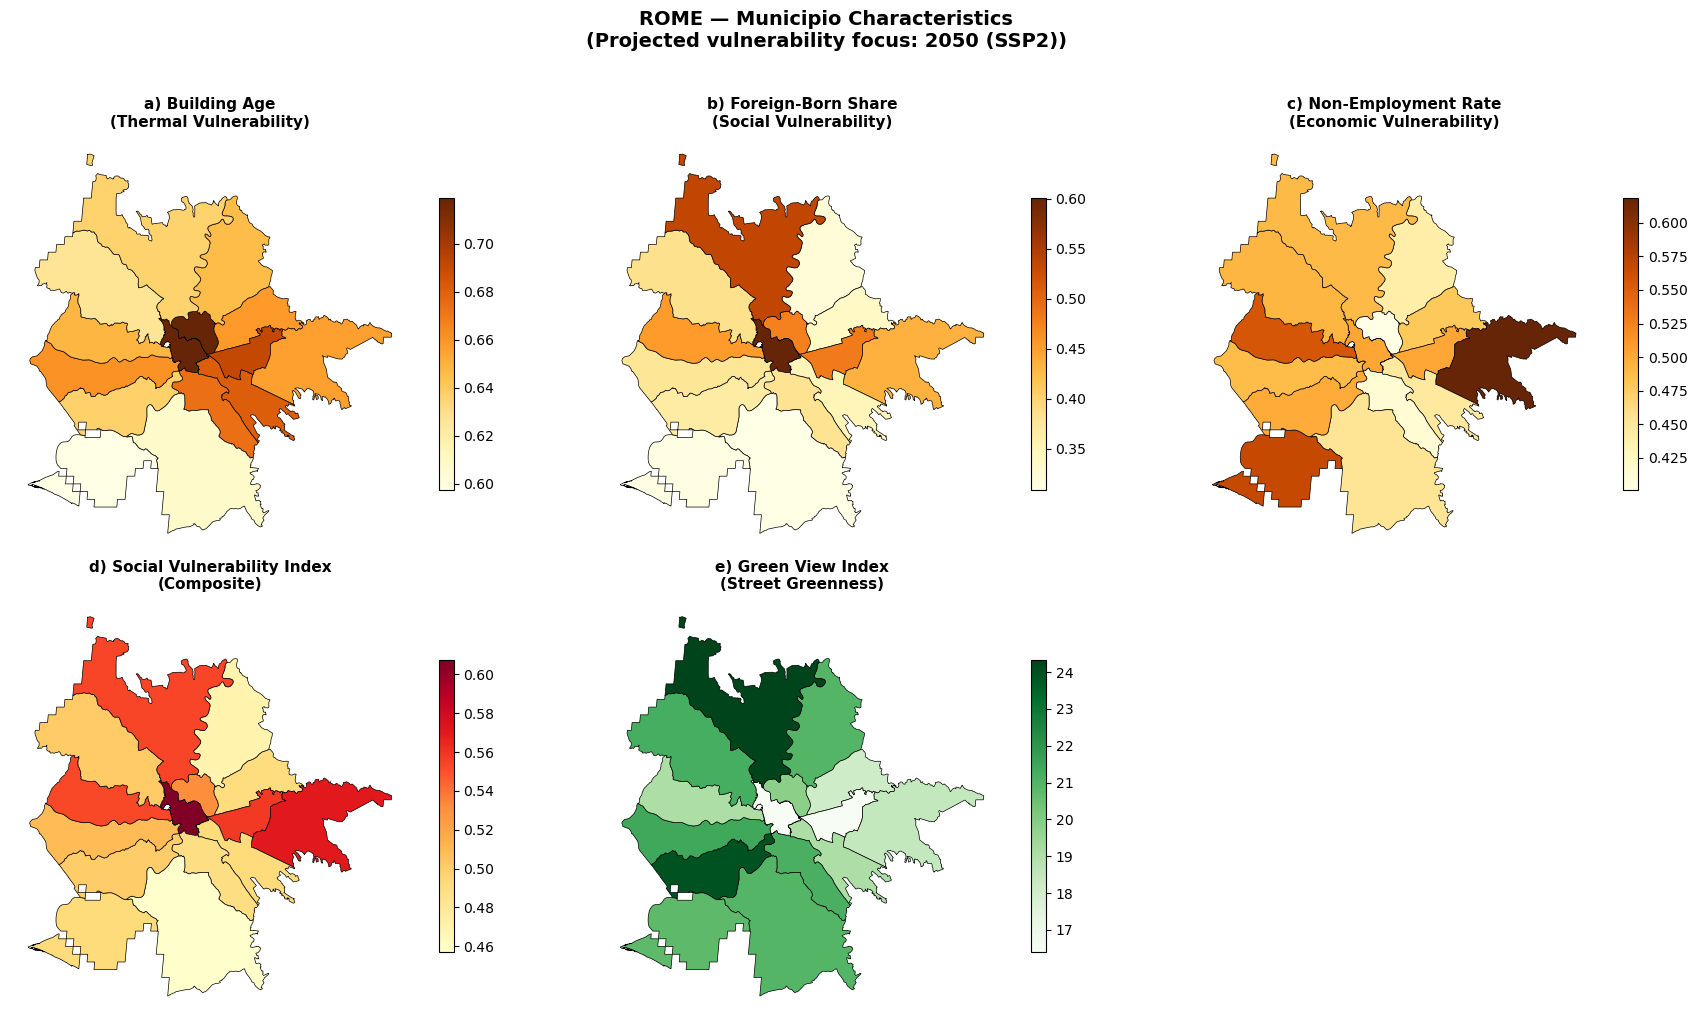

    ✓ Saved: rome_municipio_characteristics.png
    ✓ Saved: rome_municipio_characteristics.csv



In [12]:
print("\n" + "="*70)
print("SECTION 1.5: STUDY AREA CHARACTERISTICS")
print("="*70)

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio as rio
import matplotlib.pyplot as plt

# ref grid + CITY_MASK (same source as NB5)
tmpl_path = INT / "template_ref.tif"
mask_tif  = INT / "city_mask.tif"

with rio.open(tmpl_path) as src:
    ref_crs = src.crs
    HGT, WDT = src.height, src.width

with rio.open(mask_tif) as src:
    CITY_MASK = src.read(1).astype(bool)

print(f"    ✓ CITY_MASK: {CITY_MASK.shape} | pixels={int(CITY_MASK.sum()):,}")

# Load region rasters + masks from NB5
print("\n[1] Loading policy-region raster data from NB5...")
regions_cfg = cfg.get("regions", {}) or {}
zones_cfg = cfg.get("zones", {}) or {}
_trees_cfg = cfg.get("trees", {}) or {}

VEG_REGION_SOURCE = str(_trees_cfg.get("veg_regions", "regions")).strip().lower()
VEG_REGION_LABEL = str(_trees_cfg.get("veg_region_label", VEG_REGION_LABEL if "VEG_REGION_LABEL" in globals() else "Region")).strip()
VEG_REGION_LABEL_LOW = VEG_REGION_LABEL.lower()

muni_npz_path = INT / regions_cfg.get("raster_cache_file", f"muni_on_ref_{SLUG}.npz")
if not muni_npz_path.exists():
    raise FileNotFoundError(f"Missing NB5 output: {muni_npz_path.name}")

z = np.load(muni_npz_path)
muni_on_ref = z["muni_on_ref"].astype("int32")
muni_cov = z["muni_cov"].astype(bool)
ANALYSIS_MASK_MUNI = z["analysis_mask_muni"].astype(bool)

MASK_CITY = CITY_MASK
MASK_MUNI = muni_cov
MASK_POLICY = ANALYSIS_MASK_MUNI

assert muni_on_ref.shape == MASK_CITY.shape == MASK_MUNI.shape == MASK_POLICY.shape
assert np.all(MASK_POLICY <= MASK_CITY), "Policy domain must be subset of CITY_MASK"
assert np.all(MASK_POLICY <= MASK_MUNI), "Policy domain must be subset of muni_cov"
assert not np.any((muni_on_ref > 0) & (~MASK_MUNI)), "Leakage: labels outside muni_cov"
assert np.all(muni_on_ref[MASK_POLICY] > 0), "Unlabeled pixels inside policy domain"

# Region config from NB7 / YAML

# Load GVI-by-region table first (NB7 output) for ID/name normalization
gvi_region = None
gvi_candidates = [
    TAB_DIR / f"{SLUG}_trees_{VEG_REGION_LABEL_LOW}.csv",
    TAB_DIR / f"{SLUG}_trees_municipio.csv",  # the city legacy naming
]
for p in gvi_candidates:
    if p.exists():
        gvi_region = pd.read_csv(p)
        rename_map = {}
        if "region_id" in gvi_region.columns and "muni_id" not in gvi_region.columns:
            rename_map["region_id"] = "muni_id"
        if "region_name" in gvi_region.columns and "muni_name" not in gvi_region.columns:
            rename_map["region_name"] = "muni_name"
        if rename_map:
            gvi_region = gvi_region.rename(columns=rename_map)
        print(f"    ✓ GVI table: {p.name} ({len(gvi_region)} rows)")
        break
if gvi_region is None:
    print("    ⚠ GVI-by-region table not found in expected locations.")

# Load region geometry (file naming varies by city)
if VEG_REGION_SOURCE == "regions":
    gpkg_candidates = [
        INT / regions_cfg.get("cache_file", f"municipi_{SLUG}.gpkg"),
        INT / f"municipi_{SLUG}.gpkg",
        INT / f"regions_{SLUG}.gpkg",
        INT / f"zones_{SLUG}.gpkg",
        INT / f"freguesia_{SLUG}.gpkg",
    ]
else:
    zone_cache_name = zones_cfg.get("cache_file", f"zones_{SLUG}.gpkg")
    gpkg_candidates = [
        INT / zone_cache_name,
        INT / f"zones_{SLUG}.gpkg",
        INT / f"freguesia_{SLUG}.gpkg",
        INT / f"municipi_{SLUG}.gpkg",
        INT / f"regions_{SLUG}.gpkg",
    ]

muni_gpkg_path = next((p for p in gpkg_candidates if p.exists()), None)
if muni_gpkg_path is None:
    raise FileNotFoundError(
        f"Missing region geometry for {SLUG}. Tried: {[p.name for p in gpkg_candidates]}"
    )

muni = gpd.read_file(muni_gpkg_path)
print(f"    ✓ Region geometry: {muni_gpkg_path.name} ({len(muni)} rows)")
print(f"    ✓ Policy-domain pixels: {int(MASK_POLICY.sum()):,}")
print(f"    ✓ Remainder (CITY_MASK outside policy regions): {int((MASK_CITY & ~MASK_MUNI).sum()):,}")

# Normalize columns to muni_id / muni_name
cols = list(muni.columns)
id_col = next((c for c in ["muni_id", "region_id", "zone_id", "zone_code", "cap_code", "id"] if c in cols), None)
name_col = next((c for c in ["muni_name", "region_name", "zone_name", "freguesia", "name"] if c in cols), None)

if name_col is None:
    non_geom = [c for c in cols if c != "geometry"]
    name_col = non_geom[0] if non_geom else None

if id_col is not None and id_col != "muni_id":
    muni = muni.rename(columns={id_col: "muni_id"})
if name_col is not None and name_col != "muni_name":
    muni = muni.rename(columns={name_col: "muni_name"})

if "muni_name" not in muni.columns:
    if "muni_id" in muni.columns:
        muni["muni_name"] = muni["muni_id"].astype(str)
    else:
        muni["muni_name"] = np.arange(1, len(muni) + 1).astype(str)

muni["muni_name"] = muni["muni_name"].astype(str)
muni = muni.loc[muni["muni_name"].str.strip().str.lower() != "nan"].copy()

raster_ids = sorted(int(x) for x in np.unique(muni_on_ref[MASK_POLICY]) if x > 0)

if "muni_id" in muni.columns:
    muni_id_num = pd.to_numeric(muni["muni_id"], errors="coerce")
else:
    muni_id_num = pd.Series(np.nan, index=muni.index, dtype=float)

# If IDs are not numeric (the city/the city), map names to IDs from NB7 table
if gvi_region is not None and {"muni_id", "muni_name"}.issubset(gvi_region.columns):
    gvi_tmp = gvi_region[["muni_id", "muni_name"]].copy()
    gvi_tmp["muni_id"] = pd.to_numeric(gvi_tmp["muni_id"], errors="coerce")
    gvi_tmp = gvi_tmp.dropna(subset=["muni_id", "muni_name"])

    def _norm_name(s):
        s = str(s).strip().lower()
        return "".join(ch for ch in s if ch.isalnum())

    name_to_id = {
        _norm_name(n): int(i)
        for i, n in zip(gvi_tmp["muni_id"].astype(int), gvi_tmp["muni_name"].astype(str))
    }
    mapped = muni["muni_name"].map(lambda s: name_to_id.get(_norm_name(s), np.nan))
    muni_id_num = muni_id_num.fillna(mapped)

# Final fallback: assign remaining IDs by raster order
missing = muni_id_num.isna()
if missing.any():
    used_ids = set(int(v) for v in muni_id_num.dropna().astype(int).tolist())
    remaining_ids = [rid for rid in raster_ids if rid not in used_ids]
    n_assign = min(int(missing.sum()), len(remaining_ids))
    if n_assign > 0:
        idx_to_fill = list(muni.index[missing])[:n_assign]
        muni_id_num.loc[idx_to_fill] = remaining_ids[:n_assign]

# Keep rows with mapped IDs; extra gpkg rows can be outside policy raster
after_map_missing = int(muni_id_num.isna().sum())
if after_map_missing > 0:
    print(
        f"    ⚠ Dropping {after_map_missing} geometry rows without mapped region_id "
        f"(outside policy raster or unmatched names)."
    )

muni = muni.copy()
muni["muni_id"] = pd.to_numeric(muni_id_num, errors="coerce")
muni = muni.dropna(subset=["muni_id"]).copy()
muni["muni_id"] = muni["muni_id"].astype(int)

# Keep only IDs that appear in the policy raster domain
muni = muni.loc[muni["muni_id"].isin(raster_ids)].copy()
muni = muni.sort_values("muni_id").drop_duplicates("muni_id", keep="first")

if muni.empty:
    raise ValueError(
        f"No mapped region geometries overlap policy raster IDs for {SLUG}."
    )

missing_geom_ids = sorted(set(raster_ids) - set(muni["muni_id"].tolist()))
if missing_geom_ids:
    print(f"    ⚠ {len(missing_geom_ids)} raster region IDs have no geometry row: {missing_geom_ids[:8]}")

# Base characteristics table
muni_cols = ["muni_id", "geometry", "muni_name"]
muni_chars = muni[muni_cols].copy()

# Load inputs used for region characteristics
print("\n[2] Loading population grid...")
pop_path = INT / f"pop_on_ref_{SLUG}.npz"
if pop_path.exists():
    pop_grid = np.load(pop_path)["pop"].astype(float)
    print(f"    ✓ baseline pop_grid: {pop_grid.shape}")
else:
    pop_grid = None
    print(f"    Population data not found: {pop_path.name}")

print("\n[3] Loading projected vulnerability grids...")
from cityheat.vulnerability_layer import load_vulnerability

manifest_path = INT / "exposure_manifest.json"
vuln_dyn_cfg = cfg.get("vulnerability", {}).get("dynamic", {}) or {}
VULN_FOCUS_YEAR = int(vuln_dyn_cfg.get("characteristics_year", 2050))
VULN_FOCUS_SCENARIO = None
VULN_FOCUS_LABEL = str(VULN_FOCUS_YEAR)
pop_grid_vuln = pop_grid


def _match_scenario(exp_scen, keys):
    if not keys:
        return None
    if exp_scen in keys:
        return exp_scen
    norm = str(exp_scen).replace("_", "-").upper()
    for k in keys:
        if str(k).replace("_", "-").upper() == norm:
            return k
    norm_flat = norm.replace("-", "")
    for k in keys:
        k_norm = str(k).replace("_", "-").upper()
        if k_norm.replace("-", "") == norm_flat:
            return k
    return keys[0]


try:
    expo_manifest = json.load(open(manifest_path)) if manifest_path.exists() else {}

    if VULN_FOCUS_YEAR <= 2030:
        vuln = load_vulnerability(INT, SLUG, year=VULN_FOCUS_YEAR)
        pop_info = (expo_manifest.get("direct_worldpop") or {}).get(str(VULN_FOCUS_YEAR), {})
    else:
        scen_keys = list((expo_manifest.get("scenarios") or {}).keys())
        VULN_FOCUS_SCENARIO = _match_scenario(cfg.get("exp_scenario", "SSP2"), scen_keys) if scen_keys else str(cfg.get("exp_scenario", "SSP2"))
        vuln = load_vulnerability(INT, SLUG, year=VULN_FOCUS_YEAR, scenario=VULN_FOCUS_SCENARIO)
        pop_info = ((expo_manifest.get("scenarios") or {}).get(VULN_FOCUS_SCENARIO, {}) or {}).get(str(VULN_FOCUS_YEAR), {})

    pop_npz = pop_info.get("pop_npz") if isinstance(pop_info, dict) else None
    if pop_npz and Path(pop_npz).exists():
        pop_grid_vuln = np.load(pop_npz)["pop"].astype(float)

    thermal_grid = vuln.get("thermal", None)
    foreign_grid = vuln.get("foreign", None)
    unemp_grid = vuln.get("unemp", None)
    svi_grid = vuln.get("svi", None)
    HAS_VULN_GRIDS = all(x is not None for x in [thermal_grid, foreign_grid, unemp_grid, svi_grid])

    if VULN_FOCUS_SCENARIO is not None:
        VULN_FOCUS_LABEL = f"{VULN_FOCUS_YEAR} ({VULN_FOCUS_SCENARIO})"
    print(f"    ✓ projected vulnerability grids loaded for {VULN_FOCUS_LABEL}: {HAS_VULN_GRIDS}")
    if pop_grid_vuln is not None:
        print(f"    ✓ vulnerability stats weighted with matching population grid: {pop_grid_vuln.shape}")
except FileNotFoundError as exc:
    HAS_VULN_GRIDS = False
    thermal_grid = foreign_grid = unemp_grid = svi_grid = None
    pop_grid_vuln = pop_grid
    raise FileNotFoundError(
        f"Projected vulnerability layers are required for Section 1.5 (dynamic workflow). Missing for {SLUG}, year={VULN_FOCUS_YEAR}, scenario={VULN_FOCUS_SCENARIO}."
    ) from exc

print(f"\n[4] Merging GVI by {VEG_REGION_LABEL} (from NB7 outputs)...")
if gvi_region is not None:
    gvi_col = "gvi_popw" if "gvi_popw" in gvi_region.columns else ("gvi_baseline" if "gvi_baseline" in gvi_region.columns else None)
    if gvi_col is not None and "muni_id" in gvi_region.columns:
        gvi_use = gvi_region[["muni_id", gvi_col]].copy()
        gvi_use["muni_id"] = pd.to_numeric(gvi_use["muni_id"], errors="coerce")
        gvi_use = gvi_use.dropna(subset=["muni_id"]).copy()
        gvi_use["muni_id"] = gvi_use["muni_id"].astype(int)

        muni_chars = muni_chars.merge(gvi_use, on="muni_id", how="left")
        muni_chars = muni_chars.rename(columns={gvi_col: "gvi"})
        print(f"    ✓ GVI merged using column '{gvi_col}'")
    else:
        print("    ⚠ GVI table found but missing ID/metric columns for merge.")
else:
    print("    ⚠ GVI data not available.")

# %65+ (choropleth) from age grids (robust to shares vs counts)
print("\n[5] Computing %65+ by region (if age grids exist)...")

def _npz_get(zobj, *keys):
    for k in keys:
        if k in zobj.files:
            return zobj[k]
    return None

age_candidates = [
    INT / f"age_on_ref_{SLUG}.npz",
    INT / f"age_{SLUG}.npz",
    INT / f"age_data_{SLUG}.npz",
]

age_npz = None
for p in age_candidates:
    if p.exists():
        age_npz = np.load(p)
        age_path = p
        break

if age_npz is not None:
    lt15 = _npz_get(age_npz, "lt15", "age_lt15", "u15", "lt_15")
    a15_64 = _npz_get(age_npz, "a15_64", "age_a15_64", "age_15_64", "a15_64")
    g65 = _npz_get(age_npz, "g65", "age_g65", "ge65", "age_65p", "p65")

    if (lt15 is None) or (a15_64 is None) or (g65 is None):
        print(f"    Age NPZ found ({age_path.name}) but missing required keys (lt15, a15_64, g65). Skipping %65+.")
    else:
        lt15 = lt15.astype(float)
        a15_64 = a15_64.astype(float)
        g65 = g65.astype(float)
        den = lt15 + a15_64 + g65

        share_mode = False
        try:
            den_max = float(np.nanmax(den[MASK_POLICY]))
            g65_max = float(np.nanmax(g65[MASK_POLICY]))
            if (den_max <= 1.5) and (g65_max <= 1.0):
                share_mode = True
        except Exception:
            pass

        if share_mode and (pop_grid is not None):
            num_grid = g65 * pop_grid
            den_grid = pop_grid
        else:
            num_grid = g65
            den_grid = den

        muni_ids = sorted(int(x) for x in np.unique(muni_on_ref[MASK_POLICY]) if x > 0)

        pct65 = {}
        for mid in muni_ids:
            m = (muni_on_ref == mid) & MASK_POLICY & np.isfinite(num_grid) & np.isfinite(den_grid)
            d = float(np.nansum(den_grid[m]))
            pct65[mid] = (100.0 * float(np.nansum(num_grid[m])) / d) if d > 0 else np.nan

        muni_chars["pct_65plus"] = muni_chars["muni_id"].map(pct65)
        print(f"    ✓ %65+ computed from {age_path.name} | share_mode={share_mode}")
else:
    print("    No age grids found (checked age_on_ref / age / age_data). Skipping %65+.")

# Vulnerability stats (always using MASK_POLICY)
print("\n[6] Computing vulnerability stats by region (if available)...")

def compute_muni_popw_stat(grid, muni_raster, pop_grid, muni_ids, mask):
    """Population-weighted mean per region (restricted to mask)."""
    results = {}
    for mid in muni_ids:
        m = (muni_raster == mid) & mask & np.isfinite(grid)
        if m.sum() == 0:
            results[mid] = np.nan
            continue
        vals = grid[m]
        if pop_grid is not None:
            pops = np.nan_to_num(pop_grid[m], nan=0.0)
            results[mid] = float(np.average(vals, weights=pops)) if pops.sum() > 0 else float(np.nanmean(vals))
        else:
            results[mid] = float(np.nanmean(vals))
    return results

muni_ids = sorted(int(x) for x in np.unique(muni_on_ref[MASK_POLICY]) if x > 0)

if HAS_VULN_GRIDS:
    muni_chars["thermal_vuln"] = muni_chars["muni_id"].map(
        compute_muni_popw_stat(thermal_grid, muni_on_ref, pop_grid_vuln, muni_ids, MASK_POLICY)
    )
    muni_chars["foreign_vuln"] = muni_chars["muni_id"].map(
        compute_muni_popw_stat(foreign_grid, muni_on_ref, pop_grid_vuln, muni_ids, MASK_POLICY)
    )
    muni_chars["unemp_vuln"] = muni_chars["muni_id"].map(
        compute_muni_popw_stat(unemp_grid, muni_on_ref, pop_grid_vuln, muni_ids, MASK_POLICY)
    )
    muni_chars["svi"] = muni_chars["muni_id"].map(
        compute_muni_popw_stat(svi_grid, muni_on_ref, pop_grid_vuln, muni_ids, MASK_POLICY)
    )
    print(f"    ✓ Vulnerability stats computed for {VULN_FOCUS_LABEL}")
else:
    print("    Vulnerability grids missing: skipping vulnerability panels")

muni_chars = gpd.GeoDataFrame(muni_chars, geometry="geometry", crs=muni.crs)

# Map panels
print(f"\n[7] Creating {VEG_REGION_LABEL} characteristics figure...")
muni_plot = muni_chars.to_crs(epsg=4326) if muni_chars.crs is not None else muni_chars

panels = [
    ("thermal_vuln", "a) Building Age\n(Thermal Vulnerability)", "YlOrBr"),
    ("foreign_vuln", "b) Foreign-Born Share\n(Social Vulnerability)", "YlOrBr"),
    ("unemp_vuln", "c) Non-Employment Rate\n(Economic Vulnerability)", "YlOrBr"),
    ("svi", "d) Social Vulnerability Index\n(Composite)", "YlOrRd"),
    ("gvi", "e) Green View Index\n(Street Greenness)", "Greens"),
    ("pct_65plus", "f) Population 65+\n(% of population)", "PuRd"),
]

panels = [(col, title, cmap) for col, title, cmap in panels if (col in muni_plot.columns) and muni_plot[col].notna().any()]

if len(panels) == 0:
    print(f"    No {VEG_REGION_LABEL} panel data available to plot.")
else:
    n_panels = len(panels)
    ncols = min(3, n_panels)
    nrows = (n_panels + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, (col, title, cmap) in zip(axes, panels):
        muni_plot.plot(
            column=col,
            ax=ax,
            legend=True,
            legend_kwds={"shrink": 0.7},
            cmap=cmap,
            edgecolor="black",
            linewidth=0.5,
            missing_kwds={"color": "lightgray", "label": "No data"},
        )
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.set_axis_off()

    for ax in axes[len(panels):]:
        ax.set_visible(False)

    plt.suptitle(f"{CITY.upper()} — {VEG_REGION_LABEL} Characteristics\n(Projected vulnerability focus: {VULN_FOCUS_LABEL})", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()

    fig_path = FIG_DIR / f"{SLUG}_{VEG_REGION_LABEL_LOW}_characteristics.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"    ✓ Saved: {fig_path.name}")

    out_csv = TAB_DIR / f"{SLUG}_{VEG_REGION_LABEL_LOW}_characteristics.csv"
    muni_chars.drop(columns=["geometry"]).to_csv(out_csv, index=False)
    print(f"    ✓ Saved: {out_csv.name}")

print("\n" + "="*70)


# SECTION 2: POPULATION SCALING

Load population projections for scaling AC costs over time.
Uses SSP2 scenario from exposure manifest.

In [13]:
print("\n" + "="*70)
print("SECTION 2: POPULATION SCALING")
print("="*70)

expo_manifest = {}
manifest_path = INT / "exposure_manifest.json"

if manifest_path.exists():
    with open(manifest_path) as f:
        expo_manifest = json.load(f)

    exp_scen_raw = cfg.get("exp_scenario", "SSP2")
    scen_keys = list((expo_manifest.get("scenarios") or {}).keys())

    def _match_scenario(exp_scen, keys):
        if exp_scen in keys:
            return exp_scen
        up = str(exp_scen).upper()
        if up in keys:
            return up
        cleaned = up.replace("-", "").replace("_", "")
        for k in keys:
            if k.replace("-", "").replace("_", "").upper() == cleaned:
                return k
        return keys[0] if keys else None

    def _pop_sum_from_record(rec):
        if not isinstance(rec, dict):
            return None
        p = rec.get("pop_npz")
        if not p:
            return None
        p = Path(p)
        if not p.exists():
            return None
        return float(np.load(p)["pop"].sum())

    scen_key = _match_scenario(exp_scen_raw, scen_keys)
    if scen_key is None:
        raise ValueError(f"No population scenarios found in {manifest_path}")

    print(f"Using population scenario: {scen_key}")
    scen_dict = expo_manifest["scenarios"][scen_key]

    years_scen = sorted(int(y) for y in scen_dict.keys())
    totals_scen = np.array([
        float(np.load(scen_dict[str(y)]["pop_npz"])["pop"].sum())
        for y in years_scen
    ], dtype=float)

    baseline_rec = expo_manifest.get("baseline", {}) or {}
    BASELINE_YEAR = int(baseline_rec.get("year", 2020))
    total_base = _pop_sum_from_record(baseline_rec)

    # Handle manifests using direct_worldpop instead of baseline block
    if total_base is None:
        direct_wp = expo_manifest.get("direct_worldpop", {}) or {}
        direct_rec = direct_wp.get(str(BASELINE_YEAR))
        if direct_rec is None and "2020" in direct_wp:
            BASELINE_YEAR = 2020
            direct_rec = direct_wp["2020"]
        total_base = _pop_sum_from_record(direct_rec)

    # Last fallback: local 2020 pop_on_ref NPZ
    if total_base is None:
        pop_npz_path = INT / f"pop_on_ref_{SLUG}.npz"
        if pop_npz_path.exists():
            total_base = float(np.load(pop_npz_path)["pop"].sum())
            BASELINE_YEAR = 2020
        else:
            raise FileNotFoundError(
                f"Could not determine baseline population for {SLUG}. "
                f"Checked baseline/direct_worldpop in manifest and {pop_npz_path}."
            )

    years_all = np.array(sorted({BASELINE_YEAR, *years_scen}), dtype=float)
    totals_all = np.array([
        total_base if int(y) == BASELINE_YEAR else totals_scen[years_scen.index(int(y))]
        for y in years_all
    ], dtype=float)

    def pop_total_for_year(y, xp=years_all, fp=totals_all):
        return float(np.interp(float(y), xp, fp, left=fp[0], right=fp[-1]))

    print(f"Population anchor years: {[int(y) for y in years_all]}")
    print(f"Population totals: {[f'{int(t):,}' for t in totals_all]}")

else:
    pop_npz_path = INT / f"pop_on_ref_{SLUG}.npz"
    if not pop_npz_path.exists():
        raise FileNotFoundError(
            f"Exposure manifest missing ({manifest_path}) and fallback not found ({pop_npz_path})."
        )

    total_base = float(np.load(pop_npz_path)["pop"].sum())
    BASELINE_YEAR = 2020
    years_all = np.array([BASELINE_YEAR], dtype=float)
    totals_all = np.array([total_base], dtype=float)

    def pop_total_for_year(y):
        return total_base

    print(f"⚠ Exposure manifest not found, using constant population from {pop_npz_path.name}")
    print(f"Population total (2020): {int(total_base):,}")



SECTION 2: POPULATION SCALING
Using population scenario: SSP2
Population anchor years: [2020, 2040, 2050]
Population totals: ['2,634,831', '2,488,442', '2,439,832']


# SECTION 3: AC COSTS CALCULATION

Calculate AC policy costs with dynamic coverage and electricity consumption.

Cost components:
- **CAPEX**: Installation cost per AC unit, with 10-year replacement cycle
- **Maintenance**: 5% of CAPEX per user per year, on all incremental users
- **Electricity**: tariff × kWh/user × added users (incremental policy vs current AC reference)

The calculation is incremental: we compute costs for the ADDITIONAL users
brought by the policy compared to the baseline (exogenous) AC adoption.

In [14]:
print("\n" + "="*70)
print("SECTION 3: AC COSTS CALCULATION")
print("="*70)

# Time horizon years
START_YEAR = 2020
ELEC_YEARS = np.arange(START_YEAR, START_YEAR + T, dtype=int)

# Extract cost parameters
AC_CAPEX = ac_cost_params.get("capex_per_user", AC_CAPEX_PER_USER)
AC_MAINT = ac_cost_params.get("maint_rate", AC_MAINT_RATE)
AC_LIFE = ac_cost_params.get("lifetime_years", AC_LIFETIME_YEARS)
TARIFF = float(ac_cost_params.get("tariff_eur_per_kwh", ac_cost_params.get("tariff_eur_kwh", TARIFF_EUR_PER_KWH)))
maint_per_user_yr = AC_MAINT * AC_CAPEX

print("AC Cost Parameters:")
print(f"  CAPEX per user:    €{AC_CAPEX:.0f}")
print(f"  Maintenance rate:  {AC_MAINT*100:.0f}% of CAPEX/yr")
print(f"  Replacement cycle: {AC_LIFE} years")
print(f"  Electricity tariff: €{TARIFF:.2f}/kWh")

# Build yearly coverage and consumption from municipality data
if "muni_id" in muni_cov_yearly.columns:
    muni_cov_yearly = muni_cov_yearly.loc[muni_cov_yearly["muni_id"] > 0].copy()

# Interpolate coverage to full horizon
rows_interp = []
for muni_id, g in muni_cov_yearly.groupby("muni_id"):
    g = g.sort_values("year")
    known_years = g["year"].to_numpy(int)

    known_base = g["ac_base_muni"].to_numpy(float)
    known_pol = g["ac_policy_muni"].to_numpy(float)

    # Baseline (2020) municipal population
    pop_2020 = float(g["pop_muni"].iloc[0])

    # Scale population over time
    pop_2020_total = pop_total_for_year(2020)
    pop_scale_t = np.array([
        pop_total_for_year(y) / pop_2020_total for y in ELEC_YEARS
    ], dtype=float)
    pop_muni_t = pop_2020 * pop_scale_t

    # Interpolate AC shares
    base_t = np.interp(ELEC_YEARS, known_years, known_base)
    pol_t = np.interp(ELEC_YEARS, known_years, known_pol)

    # Flat extrapolation
    base_t[ELEC_YEARS <= known_years[0]] = known_base[0]
    base_t[ELEC_YEARS >= known_years[-1]] = known_base[-1]
    pol_t[ELEC_YEARS <= known_years[0]] = known_pol[0]
    pol_t[ELEC_YEARS >= known_years[-1]] = known_pol[-1]

    base_t = np.clip(base_t, 0.0, 1.0)
    pol_t = np.clip(pol_t, 0.0, 1.0)
    dshare_t = np.clip(pol_t - base_t, 0.0, 1.0)

    for year, bs, ps, ds, pm in zip(ELEC_YEARS, base_t, pol_t, dshare_t, pop_muni_t):
        rows_interp.append({
            "year": int(year),
            "muni_id": muni_id,
            "pop_muni": float(pm),
            "base_share_t": float(bs),
            "policy_share_t": float(ps),
            "dshare_t": float(ds),
        })

cov_yearly = pd.DataFrame(rows_interp)
cov_yearly["year"] = cov_yearly["year"].astype(int)

# Compute users: baseline vs policy → incremental users + cohorts
users_base_t = (
    cov_yearly.assign(users=lambda d: d["pop_muni"] * d["base_share_t"])
    .groupby("year")["users"].sum()
    .reindex(ELEC_YEARS).to_numpy(float)
)

users_policy_t = (
    cov_yearly.assign(users=lambda d: d["pop_muni"] * d["policy_share_t"])
    .groupby("year")["users"].sum()
    .reindex(ELEC_YEARS).to_numpy(float)
)

added_users_t = users_policy_t - users_base_t  # incremental users
new_users_t = np.empty_like(added_users_t)
new_users_t[0] = added_users_t[0]
new_users_t[1:] = added_users_t[1:] - added_users_t[:-1]
new_users_t = np.maximum(new_users_t, 0.0)  # cohorts must be non-negative

added_users_final = float(added_users_t[-1])
print("\nAC users (incremental policy vs current AC):")
print(f"  Year 1: {added_users_t[0]:,.0f}")
print(f"  Year {T}: {added_users_final:,.0f}")

# Merge kWh/user data
rows_kwh = []
for muni_id, g in muni_kwh.groupby("muni_id"):
    g = g.sort_values("year")
    known_years = g["year"].to_numpy(int)
    vals = g["kwh_per_user_muni"].to_numpy(float)

    kwh_interp = np.interp(ELEC_YEARS, known_years, vals)
    kwh_interp[ELEC_YEARS <= known_years[0]] = vals[0]
    kwh_interp[ELEC_YEARS >= known_years[-1]] = vals[-1]

    for y, v in zip(ELEC_YEARS, kwh_interp):
        rows_kwh.append({
            "year": int(y),
            "muni_id": muni_id,
            "kwh_per_user_muni": float(v),
        })

muni_kwh_full = pd.DataFrame(rows_kwh)
cov_yearly = (
    cov_yearly.merge(muni_kwh_full, on=["year", "muni_id"], how="left")
    .fillna({"kwh_per_user_muni": 0.0})
)

# vegetation feedback on AC electricity (Falchetta et al. 2026) 
# Trees reduce summer AC electricity consumption by ~0.8%/GVI point at ~30C.
# We keep standalone AC costs clean, and track the vegetation interaction explicitly.
elec_fb = cfg.get("electricity_feedback", {}) or {}
ELEC_FB_ENABLED = bool(elec_fb.get("enabled", False))
VEG_ELEC_PCT_PER_PT = 0.0
VEG_ELEC_SUMMER_FRAC = 0.0
VEG_CO2_gCO2_PER_KWH = 0.0

if ELEC_FB_ENABLED:
    VEG_ELEC_PCT_PER_PT = float(elec_fb["pct_reduction_per_gvi_point"])
    VEG_ELEC_SUMMER_FRAC = float(elec_fb.get("summer_months", 3)) / 12.0
    VEG_CO2_gCO2_PER_KWH = float(elec_fb.get("co2_intensity_gCO2_per_kwh", 0))

    # Load per-region dGVI from trees policy table
    _trees_tbl_candidates = [
        TAB_DIR / f"{SLUG}_trees_tbl.csv",
        TAB_DIR / f"{SLUG}_trees_{VEG_REGION_LABEL.lower()}.csv",
    ]
    _trees_tbl_path = next((p for p in _trees_tbl_candidates if p.exists()), None)
    if _trees_tbl_path is None:
        raise FileNotFoundError(f"Trees dGVI table not found: {[p.name for p in _trees_tbl_candidates]}")
    _trees_tbl = pd.read_csv(_trees_tbl_path)
    _dgvi_col = "dGVI" if "dGVI" in _trees_tbl.columns else "dGVI_points"
    _id_col = "muni_id" if "muni_id" in _trees_tbl.columns else "region_id"
    _dgvi_map = _trees_tbl.set_index(_id_col)[_dgvi_col].to_dict()

    cov_yearly["dGVI"] = cov_yearly["muni_id"].map(_dgvi_map).fillna(0.0)

    # Tree maturity per year (linear ramp from start age)
    _years_since = (cov_yearly["year"].astype(float) - START_YEAR)
    _maturity = ((_years_since + TREE_START_AGE_CENTRAL) / TREE_RAMP_YEARS).clip(0, 1)

    # Vegetation reduction: applies to SUMMER portion of annual kWh only
    cov_yearly["veg_reduction"] = VEG_ELEC_PCT_PER_PT * cov_yearly["dGVI"] * VEG_ELEC_SUMMER_FRAC * _maturity
    cov_yearly["kwh_per_user_veg"] = cov_yearly["kwh_per_user_muni"] * (1 - cov_yearly["veg_reduction"])

    _first = cov_yearly.drop_duplicates("muni_id")
    _pw_dgvi = float((_first["dGVI"] * _first["pop_muni"]).sum() / _first["pop_muni"].sum())
    print(f"\n  Falchetta veg feedback: ENABLED")
    print(f"    Elasticity: {VEG_ELEC_PCT_PER_PT*100:.1f}%/GVI pt x {VEG_ELEC_SUMMER_FRAC:.0%} summer")
    print(f"    Pop-weighted mean dGVI: {_pw_dgvi:.2f} pts")
    print(f"    Loaded: {_trees_tbl_path.name} ({len(_dgvi_map)} regions)")
else:
    cov_yearly["kwh_per_user_veg"] = cov_yearly["kwh_per_user_muni"]
    cov_yearly["veg_reduction"] = 0.0
    print(f"\n  Falchetta veg feedback: disabled")

# Compute kWh totals: standalone AC and explicit AC+trees interaction
cov_yearly["kwh_base_noveg"] = cov_yearly["pop_muni"] * cov_yearly["base_share_t"] * cov_yearly["kwh_per_user_muni"]
cov_yearly["kwh_policy_noveg"] = cov_yearly["pop_muni"] * cov_yearly["policy_share_t"] * cov_yearly["kwh_per_user_muni"]
cov_yearly["kwh_base_with_trees"] = cov_yearly["pop_muni"] * cov_yearly["base_share_t"] * cov_yearly["kwh_per_user_veg"]
cov_yearly["kwh_policy_with_trees"] = cov_yearly["pop_muni"] * cov_yearly["policy_share_t"] * cov_yearly["kwh_per_user_veg"]

kwh_base_t = cov_yearly.groupby("year")["kwh_base_noveg"].sum().reindex(ELEC_YEARS).to_numpy(float)
kwh_policy_t = cov_yearly.groupby("year")["kwh_policy_noveg"].sum().reindex(ELEC_YEARS).to_numpy(float)
kwh_inc_t = kwh_policy_t - kwh_base_t

kwh_base_with_trees_t = cov_yearly.groupby("year")["kwh_base_with_trees"].sum().reindex(ELEC_YEARS).to_numpy(float)
kwh_policy_with_trees_t = cov_yearly.groupby("year")["kwh_policy_with_trees"].sum().reindex(ELEC_YEARS).to_numpy(float)
kwh_inc_with_trees_t = kwh_policy_with_trees_t - kwh_base_with_trees_t

# Penetration for waste heat calculation
pop_muni_total_t = cov_yearly.groupby("year")["pop_muni"].sum().reindex(ELEC_YEARS).to_numpy(float)
pen_base_t = users_base_t / pop_muni_total_t
pen_pol_t = users_policy_t / pop_muni_total_t

print("\nAC penetration:")
print(f"  Baseline: {pen_base_t[0]:.1%} → {pen_base_t[-1]:.1%}")
print(f"  Policy:   {pen_pol_t[0]:.1%} → {pen_pol_t[-1]:.1%}")

# CAPEX PV (with replacement cycle)
def pv_capex_with_ramp(new_users_t, capex_per_user, life, r=R):
    """PV of AC CAPEX when policy coverage ramps up over time."""
    T_local = len(new_users_t)
    pv = 0.0
    for t in range(T_local):
        cohort = float(new_users_t[t])
        if cohort <= 0:
            continue
        pay_year = t
        while pay_year < T_local:
            pv += cohort * capex_per_user / ((1 + r) ** (pay_year + 1))
            pay_year += life
    return float(pv)

PV_ac_capex = pv_capex_with_ramp(new_users_t, AC_CAPEX, AC_LIFE, R)

# Maintenance PV
yrs = np.arange(1, T + 1, dtype=float)
maint_eur_t = np.maximum(added_users_t, 0.0) * maint_per_user_yr
PV_ac_maint = float(np.sum(maint_eur_t * (1 + R) ** (-yrs)))

# Electricity PV: standalone AC versus explicit AC+trees interaction
PV_ac_elec = float(np.sum(np.maximum(kwh_inc_t, 0.0) * TARIFF * (1 + R) ** (-yrs)))
PV_ac_elec_no_veg = PV_ac_elec
PV_ac_elec_with_trees = float(np.sum(np.maximum(kwh_inc_with_trees_t, 0.0) * TARIFF * (1 + R) ** (-yrs)))
PV_ac_elec_veg_saving = PV_ac_elec - PV_ac_elec_with_trees

# Vegetation electricity co-benefits
kwh_saved_base_t = kwh_base_t - kwh_base_with_trees_t
kwh_saved_all_t = kwh_policy_t - kwh_policy_with_trees_t
CUM_veg_kwh_base = float(kwh_saved_base_t.sum())
PV_veg_eur_base = float(np.sum(kwh_saved_base_t * TARIFF * (1 + R) ** (-yrs)))
CUM_veg_co2_base_t = CUM_veg_kwh_base * VEG_CO2_gCO2_PER_KWH / 1e6
CUM_veg_kwh_all = float(kwh_saved_all_t.sum())
PV_veg_eur_all = float(np.sum(kwh_saved_all_t * TARIFF * (1 + R) ** (-yrs)))
CUM_veg_co2_t = CUM_veg_kwh_all * VEG_CO2_gCO2_PER_KWH / 1e6

# Total AC costs
PV_ac_total = PV_ac_capex + PV_ac_maint + PV_ac_elec
PV_ac_total_with_trees = PV_ac_capex + PV_ac_maint + PV_ac_elec_with_trees
EAC_ac_total = PV_ac_total / AF
EAC_ac_total_with_trees = PV_ac_total_with_trees / AF

print("\nAC Costs (25-year PV, standalone AC):")
print(f"  CAPEX:       €{PV_ac_capex:>15,.0f}")
print(f"  Maintenance: €{PV_ac_maint:>15,.0f}")
print(f"  Electricity: €{PV_ac_elec:>15,.0f}")
print("  ─────────────────────────────")
print(f"  TOTAL:       €{PV_ac_total:>15,.0f}")
print(f"  EAC:         €{EAC_ac_total:>15,.0f}/yr")

if ELEC_FB_ENABLED:
    print("\nAC + trees interaction (same AC policy, lower operating cost):")
    print(f"  Electricity: €{PV_ac_elec_with_trees:>15,.0f}")
    print(f"  TOTAL:       €{PV_ac_total_with_trees:>15,.0f}")
    print(f"  EAC:         €{EAC_ac_total_with_trees:>15,.0f}/yr")
    print(f"  Savings vs standalone AC: €{PV_ac_elec_veg_saving:>12,.0f} (incremental users only)")

if ELEC_FB_ENABLED:
    print("\nVegetation electricity co-benefits:")
    print(f"  Current AC users (25y PV):        €{PV_veg_eur_base:>15,.0f}")
    print(f"  All AC users in AC+trees (25y PV): €{PV_veg_eur_all:>14,.0f}")
    print(f"  CO2 avoided, current AC users:     {CUM_veg_co2_base_t:>15,.1f} tonnes")
    print(f"  CO2 avoided, all AC users:         {CUM_veg_co2_t:>15,.1f} tonnes")



SECTION 3: AC COSTS CALCULATION
AC Cost Parameters:
  CAPEX per user:    €500
  Maintenance rate:  5% of CAPEX/yr
  Replacement cycle: 10 years
  Electricity tariff: €0.25/kWh

AC users (incremental policy vs current AC):
  Year 1: 227,278
  Year 25: 166,992

  Falchetta veg feedback: ENABLED
    Elasticity: 0.8%/GVI pt x 25% summer
    Pop-weighted mean dGVI: 1.63 pts
    Loaded: rome_trees_municipio.csv (15 regions)

AC penetration:
  Baseline: 68.9% → 73.2%
  Policy:   78.0% → 80.3%

AC Costs (25-year PV, standalone AC):
  CAPEX:       €    253,511,231
  Maintenance: €     88,016,053
  Electricity: €    531,964,204
  ─────────────────────────────
  TOTAL:       €    873,491,488
  EAC:         €     50,162,757/yr

AC + trees interaction (same AC policy, lower operating cost):
  Electricity: €    529,965,950
  TOTAL:       €    871,493,234
  EAC:         €     50,048,001/yr
  Savings vs standalone AC: €   1,998,254 (incremental users only)

Vegetation electricity co-benefits:
  Curre

# SECTION 4: TREES COSTS CALCULATION

Calculate vegetation policy costs using the GVI (Green View Index) approach.

Cost model:
- **CAPEX**: €10M per +1 GVI point, linear rollout over 25 years
- **O&M**: Cohort-based with maturity scaling
  - Each cohort planted in year t generates O&M from year t+1 onward
  - O&M scales with tree maturity (0 at planting, full after 12 years)
  - Start age = 5 years for pre-grown trees (central case)

In [15]:
print("\n" + "="*70)
print("SECTION 4: TREES COSTS CALCULATION")
print("="*70)

# Tree cost parameters
print(f"Tree Cost Parameters:")
print(f"  Total ΔGVI:            {DELTA_INDEX:.2f} points")
print(f"  CAPEX per point:       €{CAPEX_PER_INDEX_PT/1e6:.0f}M")
print(f"  O&M per point/yr:      €{OM_PER_INDEX_PT_YR/1e6:.2f}M")
print(f"  Maturity ramp:         {TREE_RAMP_YEARS} years")
print(f"  Start age (central):   {TREE_START_AGE_CENTRAL} years")

# CAPEX: Linear rollout over T years
def npv_capex_linear(delta_index_total, years=T, r=R, capex_per_index=CAPEX_PER_INDEX_PT):
    """
    PV of CAPEX with linear rollout: we add delta_index_total/years points each year,
    and pay capex_per_index per point. Flows at end of years 1..T.
    """
    inc = delta_index_total / years
    pv = 0.0
    for t in range(1, years + 1):
        capex_t = capex_per_index * inc
        pv += capex_t / ((1 + r) ** t)
    return float(pv)

TREES_CAPEX_T0 = CAPEX_PER_INDEX_PT * DELTA_INDEX  # undiscounted total
PV_trees_capex = npv_capex_linear(DELTA_INDEX, T, R, CAPEX_PER_INDEX_PT)

print(f"\nCAPEX:")
print(f"  Undiscounted total:    €{TREES_CAPEX_T0:,.0f}")
print(f"  PV (linear rollout):   €{PV_trees_capex:,.0f}")

# O&M: Cohort-based with maturity scaling 
def cohort_rollout_maturity_factor_om(T, ramp_years, plant_share=None, lifetime=25, start_age_years=0):
    """
    Maturity factor for O&M: O&M starts year after planting and scales with maturity.
    factor[t] = sum_i plant_share[i] * maturity(age=t-i)
    - age=0 has maturity forced to 0 (no O&M in planting year)
    - from age>=1, maturity is shifted by start_age_years
    """
    if plant_share is None:
        plant_share = np.ones(T, dtype=float) / T
    max_age = min(T, lifetime)
    ages = np.arange(max_age + 1, dtype=float)
    maturity = np.minimum((ages + start_age_years) / ramp_years, 1.0)
    maturity[0] = 0.0  # no O&M in planting year
    return np.convolve(plant_share, maturity)[:T]

def npv_om_cohorts_scaled(delta_index_total, years=T, r=R, om_per_index_per_year=OM_PER_INDEX_PT_YR,
                          ramp_years=TREE_RAMP_YEARS, lifetime=TREE_LIFETIME, start_age_years=0):
    """PV of O&M with cohort-based maturity scaling."""
    plant_share = np.ones(years, dtype=float) / years
    factor_om = cohort_rollout_maturity_factor_om(
        T=years, ramp_years=ramp_years, plant_share=plant_share,
        lifetime=lifetime, start_age_years=start_age_years
    )
    om_stream = om_per_index_per_year * delta_index_total * factor_om
    yrs = np.arange(1, years + 1, dtype=float)
    pv = float(np.sum(om_stream * (1 + r) ** (-yrs)))
    return pv, om_stream

# Base O&M (central case: start age = 5)
PV_trees_om, om_stream = npv_om_cohorts_scaled(
    DELTA_INDEX, T, R, OM_PER_INDEX_PT_YR,
    TREE_RAMP_YEARS, TREE_LIFETIME, TREE_START_AGE_CENTRAL
)

print(f"\nO&M (base, start_age={TREE_START_AGE_CENTRAL}):")
print(f"  PV:                    €{PV_trees_om:,.0f}")
print(f"  Year 1 O&M:            €{om_stream[0]:,.0f}")
print(f"  Year {T} O&M:           €{om_stream[-1]:,.0f}")

# 5× O&M sensitivity
# Compute multiplier to achieve PV(O&M) = 5 × PV(CAPEX)
k_5x = (TARGET_OM_TO_CAPEX_PV_RATIO * PV_trees_capex) / PV_trees_om
OM_PER_INDEX_PT_YR_5x = OM_PER_INDEX_PT_YR * k_5x

PV_trees_om_5x, om_stream_5x = npv_om_cohorts_scaled(
    DELTA_INDEX, T, R, OM_PER_INDEX_PT_YR_5x,
    TREE_RAMP_YEARS, TREE_LIFETIME, TREE_START_AGE_CENTRAL
)

print(f"\nO&M (5× sensitivity):")
print(f"  Multiplier:            {k_5x:.2f}×")
print(f"  PV:                    €{PV_trees_om_5x:,.0f}")

# Total Tree Costs 
PV_trees_total = PV_trees_capex + PV_trees_om
PV_trees_total_5x = PV_trees_capex + PV_trees_om_5x
EAC_trees = PV_trees_total / AF
EAC_trees_5x = PV_trees_total_5x / AF

print(f"\nTree Costs Summary (25-year PV):")
print(f"                           Base O&M      5× O&M")
print(f"  CAPEX:                  €{PV_trees_capex:>12,.0f}  €{PV_trees_capex:>12,.0f}")
print(f"  O&M:                    €{PV_trees_om:>12,.0f}  €{PV_trees_om_5x:>12,.0f}")
print(f"  ───────────────────────────────────────────────────")
print(f"  TOTAL:                  €{PV_trees_total:>12,.0f}  €{PV_trees_total_5x:>12,.0f}")
print(f"  EAC:                    €{EAC_trees:>12,.0f}/yr  €{EAC_trees_5x:>12,.0f}/yr")


SECTION 4: TREES COSTS CALCULATION
Tree Cost Parameters:
  Total ΔGVI:            23.10 points
  CAPEX per point:       €10M
  O&M per point/yr:      €1.29M
  Maturity ramp:         12 years
  Start age (central):   5 years

CAPEX:
  Undiscounted total:    €231,042,270
  PV (linear rollout):   €160,926,927

O&M (base, start_age=5):
  PV:                    €185,754,244
  Year 1 O&M:            €0
  Year 25 O&M:           €26,437,837

O&M (5× sensitivity):
  Multiplier:            4.33×
  PV:                    €804,634,634

Tree Costs Summary (25-year PV):
                           Base O&M      5× O&M
  CAPEX:                  € 160,926,927  € 160,926,927
  O&M:                    € 185,754,244  € 804,634,634
  ───────────────────────────────────────────────────
  TOTAL:                  € 346,681,171  € 965,561,560
  EAC:                    €  19,909,162/yr  €  55,450,145/yr


# SECTION 5: EWS COSTS

Load Early Warning System costs from NB6 outputs.

In [16]:
print("\n" + "="*70)
print("SECTION 5: EWS COSTS")
print("="*70)

# Robust EWS cost resolution (keeps both Pavanello and Chiabai models)
def _to_float(v, default=0.0):
    try:
        if v is None:
            return float(default)
        return float(v)
    except Exception:
        return float(default)


def _mean_warning_days(default_days=23.0):
    out = _to_float(default_days, 23.0)
    if ews_timeseries_25y is not None:
        for _col in ["n_warning_days", "warning_days"]:
            if _col in ews_timeseries_25y.columns:
                vals = pd.to_numeric(ews_timeseries_25y[_col], errors="coerce")
                m = _to_float(vals.mean(), out)
                if np.isfinite(m) and m >= 0:
                    return m
    if ews_avoided_df is not None:
        for _col in ["n_warning_days", "warning_days"]:
            if _col in ews_avoided_df.columns:
                vals = pd.to_numeric(ews_avoided_df[_col], errors="coerce")
                m = _to_float(vals.mean(), out)
                if np.isfinite(m) and m >= 0:
                    return m
    return out


def _estimate_pop_ref():
    # Try best-available reference population for Pavanello fallback
    if "cov_yearly" in globals() and cov_yearly is not None and len(cov_yearly) > 0 and "pop_muni" in cov_yearly.columns:
        if "year" in cov_yearly.columns and "START_YEAR" in globals():
            v = _to_float(cov_yearly.loc[cov_yearly["year"] == int(START_YEAR), "pop_muni"].sum(), np.nan)
            if np.isfinite(v) and v > 0:
                return v
        try:
            byy = cov_yearly.groupby("year")["pop_muni"].sum().sort_index()
            if len(byy) > 0:
                v = _to_float(byy.iloc[0], np.nan)
                if np.isfinite(v) and v > 0:
                    return v
        except Exception:
            pass
    for _name in ["pop_2020_total", "pop_2020"]:
        if _name in globals():
            v = _to_float(globals()[_name], np.nan)
            if np.isfinite(v) and v > 0:
                return v
    return np.nan


# Resolve config + NB6 artifacts
ews_cfg_local = (ews_cfg if "ews_cfg" in globals() else (cfg.get("ews", {}) or {}))
costs = (ews_params.get("costs", {}) if isinstance(ews_params, dict) else {}) or {}

cost_model = str(costs.get("cost_model", ews_cfg_local.get("cost_model", "pavanello"))).strip().lower()

pavanello_cfg = (costs.get("pavanello", {}) or ews_cfg_local.get("pavanello", {}) or {})
chiabai_cfg = (costs.get("chiabai", {}) or ews_cfg_local.get("chiabai", {}) or {})

capex_setup = _to_float(
    costs.get("capex_setup", ews_cfg_local.get("capex_setup_incremental", ews_cfg_local.get("capex_setup", 0.0))),
    0.0,
)
opex_fixed = _to_float(
    costs.get("opex_annual_fixed", ews_cfg_local.get("opex_annual_fixed_incremental", ews_cfg_local.get("opex_annual_fixed", 0.0))),
    0.0,
)

# Chiabai incremental cost per warning day
chi_inc = chiabai_cfg.get("opex_per_warning_day_incremental", None)
if chi_inc is None:
    b = chiabai_cfg.get("opex_per_warning_day_basic", None)
    e = chiabai_cfg.get("opex_per_warning_day_enhanced", None)
    if (b is not None) and (e is not None):
        chi_inc = _to_float(e, 0.0) - _to_float(b, 0.0)
chi_inc = _to_float(chi_inc, 0.0)

# Pavanello per-capita/day parameters
pav_usd_pc_day = _to_float(pavanello_cfg.get("usd_per_capita_per_day", 0.014), 0.014)
pav_eur_usd = _to_float(pavanello_cfg.get("eur_usd_rate", 0.92), 0.92)

avg_warning_days = _mean_warning_days(default_days=ews_cfg_local.get("target_activation_days", 23))
pop_ref = _estimate_pop_ref()

# Equivalent €/warning-day (for display only)
if cost_model == "chiabai":
    opex_per_day = chi_inc
elif np.isfinite(pop_ref) and pop_ref > 0:
    opex_per_day = pav_usd_pc_day * pav_eur_usd * pop_ref
else:
    opex_per_day = np.nan

# Prefer NB6 PV directly when available
PV_ews_total = _to_float(costs.get("pv_total_25y", costs.get("pv_total_anchor", np.nan)), np.nan)
pv_source = "nb6_costs"

if not (np.isfinite(PV_ews_total) and PV_ews_total > 0):
    if ews_timeseries_25y is not None and "cost_pv" in ews_timeseries_25y.columns:
        PV_ews_total = _to_float(pd.to_numeric(ews_timeseries_25y["cost_pv"], errors="coerce").sum(), np.nan)
        pv_source = "nb6_timeseries_cost_pv"

# Fallback estimate if NB6 PV unavailable
if not (np.isfinite(PV_ews_total) and PV_ews_total > 0):
    if cost_model == "chiabai":
        annual_opex = opex_fixed + chi_inc * avg_warning_days
    else:
        if np.isfinite(pop_ref) and pop_ref > 0:
            annual_opex = opex_fixed + (pav_usd_pc_day * pav_eur_usd * pop_ref) * avg_warning_days
        else:
            # Last-resort fallback if no population reference is available
            annual_opex = opex_fixed + chi_inc * avg_warning_days
    PV_ews_total = capex_setup + annual_opex * AF
    pv_source = "fallback_estimate"

EAC_ews = PV_ews_total / AF

print(f"EWS Costs (25-year PV):")
print(f"  Model: {cost_model}")
print(f"  Parameters:")
print(f"    CAPEX (one-time):     €{capex_setup:>10,.0f}")
print(f"    OPEX fixed (annual):  €{opex_fixed:>10,.0f}/yr")
if cost_model == "chiabai":
    print(f"    OPEX per warning day: €{chi_inc:>10,.0f}/day (incremental)")
else:
    print(f"    Pavanello usd/cap/day: {pav_usd_pc_day:.4f}")
    print(f"    FX EUR/USD:            {pav_eur_usd:.3f}")
    if np.isfinite(pop_ref) and pop_ref > 0:
        print(f"    Population reference:  {pop_ref:>10,.0f}")
        print(f"    OPEX per warning day: €{(pav_usd_pc_day * pav_eur_usd * pop_ref):>10,.0f}/day")
    else:
        print("    Population reference:  unavailable (fallback may be approximate)")
print(f"    Warning days (avg):    {avg_warning_days:>10.2f}")
print(f"  Cost source: {pv_source}")
print(f"  ───────────────────────────")
print(f"  PV TOTAL (25y):  €{PV_ews_total:>12,.0f}")
print(f"  EAC:             €{EAC_ews:>12,.0f}/yr")




SECTION 5: EWS COSTS
EWS Costs (25-year PV):
  Model: pavanello
  Parameters:
    CAPEX (one-time):     €         0
    OPEX fixed (annual):  €         0/yr
    Pavanello usd/cap/day: 0.0140
    FX EUR/USD:            0.920
    Population reference:   2,490,654
    OPEX per warning day: €    32,080/day
    Warning days (avg):         23.00
  Cost source: nb6_costs
  ───────────────────────────
  PV TOTAL (25y):  €  21,972,678
  EAC:             €   1,261,844/yr


# SECTION 6: BENEFITS (Avoided Deaths)

Compute health benefits for each policy as avoided heat-attributable deaths.

- **AC**: Immediate full effect, but subject to waste heat penalty
- **Trees**: Dynamic rollout + maturity ramp (benefits scale up over time)
- **EWS**: Immediate effect proportional to warning days and efficacy


In [17]:
print("\n" + "="*70)
print("SECTION 6: BENEFITS (Avoided Deaths)")
print("="*70)

YEARS = np.arange(START_YEAR, START_YEAR + T, dtype=int)

# Helper: interpolate to full horizon
def interpolate_to_horizon(s, years):
    """Interpolate a series to a full yearly horizon."""
    s = s.sort_index()
    known = s.index.to_numpy(int)
    vals = s.to_numpy(float)
    out = np.interp(years, known, vals)
    out[years <= known[0]] = vals[0]
    out[years >= known[-1]] = vals[-1]
    return out

# TREES BENEFITS
if trees_benefits_25y is not None and len(trees_benefits_25y) == T:
    trees_only_25y = trees_benefits_25y["trees_only_dynamic"].to_numpy(float)
    trees_on_top_25y = trees_benefits_25y["trees_on_top_dynamic"].to_numpy(float)

    if "trees_only_raw" in trees_benefits_25y.columns:
        trees_only_raw_25y = trees_benefits_25y["trees_only_raw"].to_numpy(float)
    else:
        trees_only_raw_25y = trees_only_25y

    print("Trees benefits loaded from NB7:")
    print(f"  Trees only (25y cum):     {trees_only_25y.sum():.2f}")
    print(f"  Trees on top (25y cum):   {trees_on_top_25y.sum():.2f}")
else:
    if not trees_cea:
        raise ValueError(
            f"Missing trees benefits for {SLUG}: neither trees_benefits_25y nor trees_cea_summary is available."
        )

    CUM_trees_only = trees_cea.get("avoided_deaths_25y", None)
    CUM_trees_on_top = trees_cea.get("avoided_deaths_on_top_25y", None)
    if CUM_trees_only is None or CUM_trees_on_top is None:
        raise KeyError(
            f"trees_cea_summary_{SLUG}.json missing avoided death keys (avoided_deaths_25y / avoided_deaths_on_top_25y)."
        )

    CUM_trees_only = float(CUM_trees_only)
    CUM_trees_on_top = float(CUM_trees_on_top)

    def cohort_rollout_maturity_factor(T, ramp_years, plant_share=None, start_age_years=0):
        """Maturity factor for benefits (same as O&M but for benefits)."""
        if plant_share is None:
            plant_share = np.ones(T, dtype=float) / T
        ages = np.arange(T + 1, dtype=float)
        maturity = np.minimum((ages + start_age_years) / ramp_years, 1.0)
        maturity[0] = 0.0
        return np.convolve(plant_share, maturity)[:T]

    trees_factor = cohort_rollout_maturity_factor(T, TREE_RAMP_YEARS, start_age_years=TREE_START_AGE_CENTRAL)
    trees_factor_sum = trees_factor.sum()

    trees_only_25y = (CUM_trees_only / trees_factor_sum) * trees_factor
    trees_on_top_25y = (CUM_trees_on_top / trees_factor_sum) * trees_factor
    trees_only_raw_25y = trees_only_25y / np.maximum(trees_factor, 1e-9)

    print("Trees benefits computed from trees_cea_summary:")
    print(f"  Trees only (25y cum):     {trees_only_25y.sum():.2f}")
    print(f"  Trees on top (25y cum):   {trees_on_top_25y.sum():.2f}")

# AC BENEFITS (GROSS, before waste heat penalty)
if trees_benefits_25y is not None and "ac_gross" in trees_benefits_25y.columns:
    ac_gross_25y = trees_benefits_25y["ac_gross"].to_numpy(float)
else:
    ac_avoided_path = INT / f"annual_heat_deaths_avoided_AC_curr_AC_{SLUG}.csv"
    if ac_avoided_path.exists():
        ac_df = pd.read_csv(ac_avoided_path, index_col="year")
        ac_df.index = ac_df.index.astype(int)
        ac_series = ac_df["overall"] if "overall" in ac_df.columns else ac_df.iloc[:, 0]
        ac_gross_25y = interpolate_to_horizon(ac_series, YEARS)
    else:
        if AC_GROSS_25Y is None:
            raise ValueError(
                f"Missing AC gross benefits for {SLUG}: no ac_gross in trees_benefits_25y and AC_GROSS_25Y unavailable."
            )
        ac_gross_25y = np.full(T, float(AC_GROSS_25Y) / T)

CUM_ac_gross = float(ac_gross_25y.sum())
print("\nAC benefits (GROSS, before waste heat):")
print(f"  25-year cumulative:       {CUM_ac_gross:.2f}")

# EWS BENEFITS

def _pick_ews_col(df):
    for c in ["net_avoided_deaths", "avoided_deaths", "gross_avoided_deaths"]:
        if c in df.columns:
            return c
    return None

if ews_benefits_25y is not None:
    ews_col = _pick_ews_col(ews_benefits_25y)
    if ews_col is None:
        raise KeyError(
            f"ews_benefits_25y_{SLUG}.csv missing avoided-deaths column (expected net_avoided_deaths)."
        )

    if "scenario" in ews_benefits_25y.columns:
        ews_central_df = ews_benefits_25y[ews_benefits_25y["scenario"] == "central"]
        if ews_central_df.empty:
            ews_central_df = ews_benefits_25y
    else:
        ews_central_df = ews_benefits_25y

    ews_25y = pd.to_numeric(ews_central_df[ews_col], errors="coerce").fillna(0.0).to_numpy(float)
    CUM_ews = float(np.nansum(ews_25y))
else:
    if ews_avoided_df is not None:
        ews_col = _pick_ews_col(ews_avoided_df)
        if ews_col is None:
            raise KeyError(
                f"annual_heat_deaths_avoided_EWS_{SLUG}.csv missing avoided-deaths column (expected net_avoided_deaths)."
            )

        if "scenario" in ews_avoided_df.columns:
            ews_central = ews_avoided_df[ews_avoided_df["scenario"] == "central"]
            if ews_central.empty:
                ews_central = ews_avoided_df
        else:
            ews_central = ews_avoided_df

        ews_series = pd.to_numeric(ews_central.set_index("year")[ews_col], errors="coerce").fillna(0.0)
        ews_series.index = ews_series.index.astype(int)
        ews_25y = np.nan_to_num(interpolate_to_horizon(ews_series, YEARS).astype(float), nan=0.0)
        CUM_ews = float(np.nansum(ews_25y))
    else:
        raise ValueError(
            f"Missing EWS benefit inputs for {SLUG}: neither ews_benefits_25y nor annual_heat_deaths_avoided_EWS is available."
        )

print("\nEWS benefits (central):")
print(f"  25-year cumulative:       {CUM_ews:.2f}")



SECTION 6: BENEFITS (Avoided Deaths)
Trees benefits loaded from NB7:
  Trees only (25y cum):     181.31
  Trees on top (25y cum):   170.34

AC benefits (GROSS, before waste heat):
  25-year cumulative:       818.21

EWS benefits (central):
  25-year cumulative:       973.65


In [18]:
# Vegetation -> Electricity feedback summary (Falchetta et al. 2026) 
# The feedback is now split into:
#   1. an AC operating-cost interaction (incremental policy users only), and
#   2. a tree-owned electricity co-benefit report.
#
# Variables set in Cell 24:
#   ELEC_FB_ENABLED, PV_ac_elec_veg_saving, PV_veg_eur_base, PV_veg_eur_all,
#   CUM_veg_kwh_base, CUM_veg_kwh_all, CUM_veg_co2_base_t, CUM_veg_co2_t

# Backward-compatible aliases for downstream cells
HAS_ELEC_SAVINGS = ELEC_FB_ENABLED
PV_elec_savings = PV_veg_eur_all       # PV of total electricity savings (all AC users in AC+trees scenario)
CUM_elec_kwh = CUM_veg_kwh_all         # cumulative kWh saved (all AC users)
CUM_elec_co2_t = CUM_veg_co2_t         # cumulative CO2 avoided (all AC users)

if HAS_ELEC_SAVINGS:
    print(f"\nVegetation electricity feedback (Falchetta et al. 2026):")
    print(f"  AC policy elec cost saving:            €{PV_ac_elec_veg_saving:>12,.0f} (incremental users only)")
    print(f"  Tree co-benefit, current AC users:     €{PV_veg_eur_base:>12,.0f}")
    print(f"  Tree co-benefit, all AC users:         €{PV_veg_eur_all:>12,.0f} (AC+trees scenario)")
    print(f"  Cumulative kWh saved, current AC:      {CUM_veg_kwh_base:>12,.0f}")
    print(f"  Cumulative kWh saved, all AC users:    {CUM_elec_kwh:>12,.0f}")
    print(f"  CO2 avoided, current AC users:         {CUM_veg_co2_base_t:>12,.1f} tonnes")
    print(f"  CO2 avoided, all AC users:             {CUM_elec_co2_t:>12,.1f} tonnes")
    print(f"  Tree cost coverage, current AC users:  {PV_veg_eur_base / max(PV_trees_total, 1e-6) * 100:>11.1f}%")
    print(f"  Tree cost coverage, all AC users:      {PV_elec_savings / max(PV_trees_total, 1e-6) * 100:>11.1f}%")
else:
    print("\nVegetation electricity feedback: disabled")



Vegetation electricity feedback (Falchetta et al. 2026):
  AC policy elec cost saving:            €   1,998,254 (incremental users only)
  Tree co-benefit, current AC users:     €  12,716,303
  Tree co-benefit, all AC users:         €  14,714,557 (AC+trees scenario)
  Cumulative kWh saved, current AC:        76,146,842
  Cumulative kWh saved, all AC users:      87,896,909
  CO2 avoided, current AC users:             28,326.6 tonnes
  CO2 avoided, all AC users:                 32,697.7 tonnes
  Tree cost coverage, current AC users:          3.7%
  Tree cost coverage, all AC users:              4.2%


### Interpretation: Electricity Feedback Bookkeeping

This notebook now treats the electricity feedback as an **explicit interaction**, not as part of the standalone AC row.

- `AC (NET)` is the standalone AC policy: AC CAPEX, AC maintenance, and AC electricity costs for the incremental AC policy **without** a tree discount.
- `AC (NET + trees)` is the explicit combined scenario: the same AC policy, but with lower AC operating cost because trees reduce `kwh_per_user`.
- Tree electricity savings are reported as **tree-owned co-benefits**, not silently subtracted from tree costs in the default tree CBA.
- The co-benefit is shown for two bases: current AC users, and all AC users in the combined `AC + trees` scenario.

This keeps the reporting clean: standalone rows remain standalone, and interactions are reported as interactions.


# SECTION 7: WASTE HEAT PENALTY

Convert AC waste heat warming into extra heat deaths.

Methodology:
1. Map AC penetration to nighttime warming using empirical data from Salamanca et al. (2014)
2. Convert nighttime warming to daily-mean warming with the `0.5` factor and apply the configured COP amplification
3. Use daily hazard temperatures from `NB05` to derive a Kou-style annual cooling-activity share for each modeled year
4. Translate warming into extra deaths in `NB05` using current-AC and policy-AC **activity-scaled** marginal deaths per `+1 °C`
5. Load the exported penalty series here and use the incremental penalty, defined as policy AC minus current AC, in the CBA


In [19]:
print("\n" + "="*70)
print("SECTION 7: WASTE HEAT PENALTY")
print("="*70)

wasteheat_series_path = INT / f"ac_wasteheat_timeseries_{SLUG}.csv"
if not wasteheat_series_path.exists():
    raise FileNotFoundError(f"Missing NB5 waste-heat time series: {wasteheat_series_path}")

wasteheat_df = pd.read_csv(wasteheat_series_path).sort_values("year")
wasteheat_df["year"] = wasteheat_df["year"].astype(int)
wasteheat_df = wasteheat_df.set_index("year").reindex(YEARS)
if wasteheat_df.isnull().any().any():
    missing = wasteheat_df.index[wasteheat_df.isnull().any(axis=1)].tolist()
    raise ValueError(f"NB5 waste-heat time series is missing years required by NB8: {missing}")

activity_share_t = wasteheat_df["activity_share"].to_numpy(float)
activity_days_equiv_t = wasteheat_df["activity_days_equiv"].to_numpy(float)
pen_current_t = wasteheat_df["pen_current"].to_numpy(float) if "pen_current" in wasteheat_df.columns else wasteheat_df["pen_base"].to_numpy(float)
pen_policy_t = wasteheat_df["pen_policy"].to_numpy(float)
pen_base_t = pen_current_t.copy()  # backward-compatible alias

dT_dm_current_t = wasteheat_df["dT_dm_current"].to_numpy(float) if "dT_dm_current" in wasteheat_df.columns else wasteheat_df["dT_dm_base"].to_numpy(float)
dT_dm_policy_t = wasteheat_df["dT_dm_policy"].to_numpy(float)
dT_dm_inc_t = wasteheat_df["dT_dm_incremental"].to_numpy(float)
dT_dm_base_t = dT_dm_current_t.copy()  # backward-compatible alias

dT_night_current_t = wasteheat_df["dT_night_current"].to_numpy(float) if "dT_night_current" in wasteheat_df.columns else wasteheat_df["dT_night_base"].to_numpy(float)
dT_night_policy_t = wasteheat_df["dT_night_policy"].to_numpy(float)
dT_night_inc_t = wasteheat_df["dT_night_incremental"].to_numpy(float)
dT_night_base_t = dT_night_current_t.copy()  # backward-compatible alias

marginal_current_full_t = wasteheat_df["marginal_current_full_perC"].to_numpy(float)
marginal_policy_full_t = wasteheat_df["marginal_policy_full_perC"].to_numpy(float)
marginal_current_active_t = wasteheat_df["marginal_current_active_perC"].to_numpy(float)
marginal_policy_active_t = wasteheat_df["marginal_policy_active_perC"].to_numpy(float)
marginal_total_perC_t = marginal_current_active_t.copy()  # backward-compatible alias

penalty_current_t = wasteheat_df["penalty_current"].to_numpy(float) if "penalty_current" in wasteheat_df.columns else wasteheat_df["penalty_base"].to_numpy(float)
penalty_policy_t = wasteheat_df["penalty_policy"].to_numpy(float)
penalty_base_t = penalty_current_t.copy()  # backward-compatible alias
penalty_pol_t = penalty_policy_t.copy()  # backward-compatible alias
warming_penalty_t = wasteheat_df["penalty_incremental"].to_numpy(float)  # standalone AC penalty

dT_eff_current_t = np.maximum(dT_dm_current_t, 0.0)
dT_eff_policy_t = np.maximum(dT_dm_policy_t, 0.0)
dT_eff_inc_t = np.maximum(dT_dm_inc_t, 0.0)

print(f"  Loaded: {wasteheat_series_path.name}")
print(f"  Current AC daily-mean dT: {dT_dm_current_t[0]:.3f}C -> {dT_dm_current_t[-1]:.3f}C")
print(f"  Policy AC daily-mean dT:  {dT_dm_policy_t[0]:.3f}C -> {dT_dm_policy_t[-1]:.3f}C")
print(f"  Incremental dT max:       {dT_dm_inc_t.max():.3f}C")
print(f"  Activity share range:     {activity_share_t.min():.3f} -> {activity_share_t.max():.3f}")
print(f"  Active-day equivalent:    {activity_days_equiv_t.min():.1f} -> {activity_days_equiv_t.max():.1f} days/year")

# ── Lambda_y: tree-cooled AC utilization scaling for the explicit AC+trees interaction ──
# The underlying NB05 penalty is already activity-weighted. lambda_y is a second-order
# correction that scales that penalty down under the tree-cooled hazard branch.
import h5py
import scipy.sparse as sp

lambda_y_t = np.ones(T, dtype=float)  # default: no scaling
LAMBDA_Y_ENABLED = False

ext_cfg = cfg.get("extreme_hazard", {}) or {}
track_default = "extreme" if bool(ext_cfg.get("enabled", False)) and bool(ext_cfg.get("run_extreme_track", False)) else "standard"
haz_track = str(os.environ.get("HAZARD_TRACK", track_default)).strip().lower()
use_extreme_track = haz_track in {"extreme", "event", "track_b", "heatwave"}
track_suffix = "_extreme" if use_extreme_track else ""
std_track_cfg = ext_cfg.get("standard_track", {}) or {}
if (not use_extreme_track) and (not bool(std_track_cfg.get("run_policies", True))):
    raise RuntimeError(
        "Policy runs for Track-A (standard) are disabled by config "
        "(extreme_hazard.standard_track.run_policies=false). "
        "Set HAZARD_TRACK=extreme to run the city policy notebooks."
    )

veg_aux_path = INT / f"{SLUG}_veg_aux_arrays.npz"
haz_daily_path = INT / f"hazard_T2M_daily_{SLUG}{track_suffix}.h5"
haz_events_path = INT / f"hazard_T2M_daily_events_{SLUG}{track_suffix}.csv"
if use_extreme_track and (not haz_daily_path.exists() or not haz_events_path.exists()):
    raise FileNotFoundError(
        f"Missing extreme hazard inputs: {haz_daily_path} | {haz_events_path}"
    )
if not haz_daily_path.exists():
    haz_daily_path = INT / f"hazard_T2M_daily_{SLUG}.h5"
if not haz_events_path.exists():
    haz_events_path = INT / f"hazard_T2M_daily_events_{SLUG}.csv"

if veg_aux_path.exists() and haz_daily_path.exists() and haz_events_path.exists():
    try:
        # Load monthly city-mean dT2M from vegetation (at full maturity)
        _veg_aux = np.load(veg_aux_path)
        _dT2M_monthly = _veg_aux["dT2M_month_ref_uniform_approx"]  # (12, H, W)
        _scope = _veg_aux["SCOPE_PHYS"]  # (H, W)
        _dT2M_citymean_monthly = np.array([
            float(_dT2M_monthly[m][_scope > 0].mean()) for m in range(12)
        ])  # shape (12,) — negative values = cooling

        # Load daily hazard (sparse) and compute city-mean daily T
        with h5py.File(haz_daily_path, "r") as _hf:
            _data = _hf["intensity/data"][:]
            _indices = _hf["intensity/indices"][:]
            _indptr = _hf["intensity/indptr"][:]
            _n_centroids = int(_hf["centroids/block0_values"].shape[0])
        _intensity = sp.csr_matrix((_data, _indices, _indptr),
                                    shape=(len(_indptr) - 1, _n_centroids))
        _nnz_per_row = np.diff(_intensity.indptr)
        _row_sums = np.array(_intensity.sum(axis=1)).flatten()
        _citymean_daily = _row_sums / np.maximum(_nnz_per_row, 1)

        # Event dates → month mapping
        _events = pd.read_csv(haz_events_path)
        _events["date"] = pd.to_datetime(_events["date"])
        _events["month"] = _events["date"].dt.month
        _events["year"] = _events["date"].dt.year

        # Kou ramp parameters (from NB5 wasteheat_params)
        _wh_params_path = INT / f"wasteheat_params_{SLUG}.json"
        with open(_wh_params_path) as _f:
            _wh_params = json.load(_f)
        _t_on = float(_wh_params.get("t_on_c", 18.0))
        _t_full = float(_wh_params.get("t_full_c", 25.0))

        # Compute lambda per anchor year, then interpolate to 25 years
        _anchor_years = sorted(_events["year"].unique())
        _lambda_anchor = {}
        for _ay in _anchor_years:
            _mask = _events["year"] == _ay
            _T_base = _citymean_daily[_mask.values]
            _months = _events.loc[_mask, "month"].values

            # Maturity at this anchor year
            _ys = _ay - START_YEAR
            _mat = min((_ys + TREE_START_AGE_CENTRAL) / TREE_RAMP_YEARS, 1.0)

            # Monthly tree cooling scaled by maturity
            _dT_daily = np.array([_dT2M_citymean_monthly[m - 1] * _mat for m in _months])
            _T_tree = _T_base + _dT_daily  # dT2M is negative (cooling)

            _s_base = np.clip((_T_base - _t_on) / (_t_full - _t_on), 0, 1).mean()
            _s_tree = np.clip((_T_tree - _t_on) / (_t_full - _t_on), 0, 1).mean()
            _lambda_anchor[_ay] = np.clip(_s_tree / max(_s_base, 1e-9), 0.0, 1.0)

        # Interpolate to full 25-year series
        _anchor_arr = np.array(sorted(_lambda_anchor.keys()))
        _lambda_arr = np.array([_lambda_anchor[y] for y in _anchor_arr])
        lambda_y_t = np.interp(YEARS, _anchor_arr, _lambda_arr)
        lambda_y_t = np.clip(lambda_y_t, 0.0, 1.0)
        LAMBDA_Y_ENABLED = True

        print(f"\n  Lambda_y (tree-cooled AC utilization):")
        print(f"    Kou ramp: t_on={_t_on}C, t_full={_t_full}C")
        print(f"    City-mean JJA dT2M (full maturity): {_dT2M_citymean_monthly[5:8].mean():.4f}C")
        for _ay in _anchor_arr:
            print(f"    {int(_ay)}: lambda={_lambda_anchor[_ay]:.6f} (reduction: {100*(1 - _lambda_anchor[_ay]):.2f}%)")
        print(f"    Mean lambda (25y): {lambda_y_t.mean():.6f}")

        # Clean up large arrays
        del _intensity, _data, _indices, _indptr, _citymean_daily, _veg_aux

    except Exception as e:
        print(f"\n  Lambda_y computation failed: {e}")
        print("  Proceeding without tree-cooled waste heat scaling")
        lambda_y_t = np.ones(T, dtype=float)
        LAMBDA_Y_ENABLED = False
else:
    missing = [p.name for p in [veg_aux_path, haz_daily_path, haz_events_path] if not p.exists()]
    print(f"\n  Lambda_y: disabled (missing: {', '.join(missing)})")

# Apply lambda_y only to the explicit AC+trees interaction branch
activity_share_tree_t = activity_share_t * lambda_y_t
warming_penalty_with_trees_t = warming_penalty_t * lambda_y_t

CUM_penalty = float(warming_penalty_t.sum())
CUM_penalty_with_trees = float(warming_penalty_with_trees_t.sum())
if LAMBDA_Y_ENABLED:
    print(f"\n  Waste heat penalty ({DELTA_T_CASE} case):")
    print(f"    Standalone AC:   {CUM_penalty:.2f} extra deaths")
    print(f"    AC + trees:      {CUM_penalty_with_trees:.2f} extra deaths")
    print(f"    Reduction:       {CUM_penalty - CUM_penalty_with_trees:.3f} deaths ({100*(CUM_penalty - CUM_penalty_with_trees)/max(CUM_penalty, 1e-9):.2f}%)")
else:
    print(f"\nWaste heat penalty ({DELTA_T_CASE} case):")
    print(f"  25-year cumulative:       {CUM_penalty:.2f} extra deaths")

# NET AC BENEFITS
ac_net_25y = ac_gross_25y - warming_penalty_t
ac_net_with_trees_25y = ac_gross_25y - warming_penalty_with_trees_t
CUM_ac_net = float(ac_net_25y.sum())
CUM_ac_net_with_trees = float(ac_net_with_trees_25y.sum())

print(f"\nAC benefits (NET, after waste heat penalty):")
print(f"  Standalone AC:")
print(f"    GROSS:                    {CUM_ac_gross:.2f}")
print(f"    Penalty:                 -{CUM_penalty:.2f}")
print(f"    NET:                      {CUM_ac_net:.2f}")
print(f"  AC + trees interaction:")
print(f"    Penalty:                 -{CUM_penalty_with_trees:.2f}")
print(f"    NET:                      {CUM_ac_net_with_trees:.2f}")



SECTION 7: WASTE HEAT PENALTY
  Loaded: ac_wasteheat_timeseries_rome.csv
  Current AC daily-mean dT: 0.417C -> 0.450C
  Policy AC daily-mean dT:  0.482C -> 0.501C
  Incremental dT max:       0.065C
  Activity share range:     0.289 -> 0.308
  Active-day equivalent:    105.6 -> 112.6 days/year

  Lambda_y (tree-cooled AC utilization):
    Kou ramp: t_on=18.0C, t_full=25.0C
    City-mean JJA dT2M (full maturity): -0.0439C
    2020: lambda=0.997948 (reduction: 0.21%)
    2030: lambda=0.995572 (reduction: 0.44%)
    2040: lambda=0.995400 (reduction: 0.46%)
    2050: lambda=0.995520 (reduction: 0.45%)
    Mean lambda (25y): 0.996034

  Waste heat penalty (central case):
    Standalone AC:   120.05 extra deaths
    AC + trees:      119.57 extra deaths
    Reduction:       0.474 deaths (0.39%)

AC benefits (NET, after waste heat penalty):
  Standalone AC:
    GROSS:                    818.21
    Penalty:                 -120.05
    NET:                      698.17
  AC + trees interaction:
 

In [20]:
# WASTE HEAT PENALTY VERIFICATION

print("\n" + "="*70)
print("WASTE HEAT PENALTY: VERIFICATION & DOCUMENTATION")
print("="*70)

print(f"\n1. SALAMANCA CALIBRATION:")
print(f"   Paper reports NIGHTTIME warming for Phoenix, AC65%: 0.5-1.0°C")
print(f"   We use CENTRAL case: 0.75°C nighttime")
print(f"   Convert to DAILY-MEAN (halving): 0.75 × 0.5 = 0.375°C")
print(f"")
print(f"   Current AC ({pen_current_t[0]:.1%}): {dT_dm_current_t[0]:.3f}°C daily-mean")
print(f"   Policy AC  ({pen_policy_t[0]:.1%}): {dT_dm_policy_t[0]:.3f}°C daily-mean")
print(f"   INCREMENTAL:                  {dT_dm_inc_t[0]:.4f}°C")

print(f"\n2. KOU-STYLE COOLING ACTIVITY SHARE:")
print(f"   We do not apply the waste-heat penalty as if AC were active all year.")
print(f"   Instead, daily hazard temperatures from NB5 are converted into an annual")
print(f"   activity share using the configured Kou ramp ({wasteheat_params.get('t_on_c', 18.0):.0f}–{wasteheat_params.get('t_full_c', 25.0):.0f}°C).")
print(f"   Average activity share over horizon: {activity_share_t.mean():.3f}")
print(f"   Average active-day equivalent:       {activity_days_equiv_t.mean():.1f} days/year")

print(f"\n3. PENALTY CALCULATION:")
print(f"   Formula: Extra deaths = active marginal deaths/°C × ΔT")
print(f"")
print(f"   Current AC active marginal (avg): {marginal_current_active_t.mean():.1f} deaths/°C")
print(f"   Policy AC active marginal (avg):  {marginal_policy_active_t.mean():.1f} deaths/°C")
print(f"   Incremental ΔT (avg):             {dT_dm_inc_t.mean():.4f}°C")
print(f"")
print(f"   Year-by-year penalty:")
print(f"     Year 1: current={penalty_current_t[0]:.2f}, policy={penalty_policy_t[0]:.2f}, incremental={warming_penalty_t[0]:.2f}")
print(f"     Year {T}: current={penalty_current_t[-1]:.2f}, policy={penalty_policy_t[-1]:.2f}, incremental={warming_penalty_t[-1]:.2f}")

CUM_penalty = float(warming_penalty_t.sum())
CUM_ac_gross = float(ac_gross_25y.sum())
CUM_ac_net = CUM_ac_gross - CUM_penalty
reduction_pct = 100 * CUM_penalty / CUM_ac_gross if CUM_ac_gross > 0 else 0

print(f"\n4. AC BENEFIT REDUCTION DUE TO WASTE HEAT:")
print(f"   ┌─────────────────────────────────────────────┐")
print(f"   │  AC GROSS benefit:      {CUM_ac_gross:>8.1f} deaths avoided  │")
print(f"   │  Waste heat penalty:   -{CUM_penalty:>8.1f} extra deaths     │")
print(f"   │  ─────────────────────────────────────────  │")
print(f"   │  AC NET benefit:        {CUM_ac_net:>8.1f} deaths avoided  │")
print(f"   │                                             │")
print(f"   │  REDUCTION: {reduction_pct:.1f}%                          │")
print(f"   └─────────────────────────────────────────────┘")

print(f"\n5. INTERPRETATION:")
print(f"   The waste heat feedback is evaluated as POLICY AC versus CURRENT AC.")
print(f"   The penalty is activity-scaled using daily hazard temperatures from NB5.")
print(f"   Net AC benefit after waste heat: {CUM_ac_net:.0f} avoided deaths over 25 years.")



WASTE HEAT PENALTY: VERIFICATION & DOCUMENTATION

1. SALAMANCA CALIBRATION:
   Paper reports NIGHTTIME warming for Phoenix, AC65%: 0.5-1.0°C
   We use CENTRAL case: 0.75°C nighttime
   Convert to DAILY-MEAN (halving): 0.75 × 0.5 = 0.375°C

   Current AC (69.6%): 0.417°C daily-mean
   Policy AC  (78.2%): 0.482°C daily-mean
   INCREMENTAL:                  0.0648°C

2. KOU-STYLE COOLING ACTIVITY SHARE:
   We do not apply the waste-heat penalty as if AC were active all year.
   Instead, daily hazard temperatures from NB5 are converted into an annual
   activity share using the configured Kou ramp (18–25°C).
   Average activity share over horizon: 0.301
   Average active-day equivalent:       110.0 days/year

3. PENALTY CALCULATION:
   Formula: Extra deaths = active marginal deaths/°C × ΔT

   Current AC active marginal (avg): 127.4 deaths/°C
   Policy AC active marginal (avg):  122.1 deaths/°C
   Incremental ΔT (avg):             0.0583°C

   Year-by-year penalty:
     Year 1: current=46

### Interpretation: `lambda_y` As A Marginal Interaction Correction

The waste-heat side is handled as a **marginal interaction correction**.

- `lambda_y` scales the **incremental** waste-heat penalty from AC policy expansion.
- It does **not** re-solve the full background waste heat from current AC users inside the reference and tree-only branches.
- This is intentional in the main specification: the CBA asks how trees interact with the **policy margin** of AC expansion while keeping standalone policy rows comparable.
- A full closure would also reduce background waste heat from existing AC users. That omitted term can be bounded in an appendix with a simple approximation such as `sum((1 - lambda_y_t) * penalty_current_t)`.

For Copenhagen, `lambda_y` also stays very close to one (`~0.9961` in the current run), so the omitted background correction is expected to be very small relative to the broader uncertainty envelope.


# SECTION 8: COST-EFFECTIVENESS ANALYSIS

Compare policies on cost per avoided death.

In [21]:
print("\n" + "="*70)
print("SECTION 8: COST-EFFECTIVENESS ANALYSIS")
print("="*70)

# Summary values
CUM_trees = float(trees_only_25y.sum())

def safe_ratio(cost, benefit):
    """Safe division for cost per death."""
    return float(cost / benefit) if benefit > 1e-9 else np.inf

# Build CEA table
cea_rows = []

# Trees (base O&M)
cea_rows.append({
    "Policy": "Trees (base O&M)",
    "PV_Cost_EUR": PV_trees_total,
    "Avoided_Deaths_25y": CUM_trees,
    "Cost_per_Death_EUR": safe_ratio(PV_trees_total, CUM_trees),
    "EAC_EUR_yr": EAC_trees,
})

# Trees (5x O&M)
cea_rows.append({
    "Policy": "Trees (5x O&M)",
    "PV_Cost_EUR": PV_trees_total_5x,
    "Avoided_Deaths_25y": CUM_trees,
    "Cost_per_Death_EUR": safe_ratio(PV_trees_total_5x, CUM_trees),
    "EAC_EUR_yr": EAC_trees_5x,
})

# AC (NET) = standalone AC only
cea_rows.append({
    "Policy": "AC (NET)",
    "PV_Cost_EUR": PV_ac_total,
    "Avoided_Deaths_25y": CUM_ac_net,
    "Cost_per_Death_EUR": safe_ratio(PV_ac_total, CUM_ac_net),
    "EAC_EUR_yr": EAC_ac_total,
})

# AC (NET + trees) = explicit combined scenario
if ELEC_FB_ENABLED or LAMBDA_Y_ENABLED:
    cea_rows.append({
        "Policy": "AC (NET + trees)",
        "PV_Cost_EUR": PV_ac_total_with_trees,
        "Avoided_Deaths_25y": CUM_ac_net_with_trees,
        "Cost_per_Death_EUR": safe_ratio(PV_ac_total_with_trees, CUM_ac_net_with_trees),
        "EAC_EUR_yr": EAC_ac_total_with_trees,
    })

# AC (GROSS) = standalone AC without waste heat
cea_rows.append({
    "Policy": "AC (GROSS)",
    "PV_Cost_EUR": PV_ac_total,
    "Avoided_Deaths_25y": CUM_ac_gross,
    "Cost_per_Death_EUR": safe_ratio(PV_ac_total, CUM_ac_gross),
    "EAC_EUR_yr": EAC_ac_total,
})

# EWS
if PV_ews_total > 0 and CUM_ews > 0:
    cea_rows.append({
        "Policy": "EWS (central)",
        "PV_Cost_EUR": PV_ews_total,
        "Avoided_Deaths_25y": CUM_ews,
        "Cost_per_Death_EUR": safe_ratio(PV_ews_total, CUM_ews),
        "EAC_EUR_yr": EAC_ews,
    })

cea_df = pd.DataFrame(cea_rows)

print("\nCost-Effectiveness Summary (25-year horizon):")
print("-" * 95)
print(f"{'Policy':<30} {'PV Cost':>15} {'Deaths Avoided':>15} {'EUR/Death':>15} {'EAC':>15}")
print("-" * 95)

for _, row in cea_df.iterrows():
    # formatting for cost per death
    cpd = row['Cost_per_Death_EUR']
    if cpd < 1_000_000:  # Less than 1M - show in thousands
        cpd_str = f"EUR{cpd/1e3:>10.0f}K"
    else:
        cpd_str = f"EUR{cpd/1e6:>10.1f}M"

    print(f"{row['Policy']:<30} EUR{row['PV_Cost_EUR']/1e6:>10.1f}M {row['Avoided_Deaths_25y']:>15.1f} {cpd_str:>15} EUR{row['EAC_EUR_yr']/1e6:>10.1f}M/yr")

print("-" * 95)

if ELEC_FB_ENABLED:
    print(f"\n  Note: Standalone AC row excludes the vegetation electricity interaction.")
    print(f"    AC + trees elec saving: EUR {PV_ac_elec_veg_saving/1e6:.2f}M (incremental users only)")
if LAMBDA_Y_ENABLED:
    print(f"  Note: AC + trees row scales the waste-heat penalty by lambda_y.")
    print(f"    Mean lambda_y: {lambda_y_t.mean():.6f}")

# Save CEA table
cea_df.to_csv(TAB_DIR / f"{SLUG}_cea_summary.csv", index=False)
print(f"\n  Saved: {SLUG}_cea_summary.csv")



SECTION 8: COST-EFFECTIVENESS ANALYSIS

Cost-Effectiveness Summary (25-year horizon):
-----------------------------------------------------------------------------------------------
Policy                                 PV Cost  Deaths Avoided       EUR/Death             EAC
-----------------------------------------------------------------------------------------------
Trees (base O&M)               EUR     346.7M           181.3  EUR       1.9M EUR      19.9M/yr
Trees (5x O&M)                 EUR     965.6M           181.3  EUR       5.3M EUR      55.5M/yr
AC (NET)                       EUR     873.5M           698.2  EUR       1.3M EUR      50.2M/yr
AC (NET + trees)               EUR     871.5M           698.6  EUR       1.2M EUR      50.0M/yr
AC (GROSS)                     EUR     873.5M           818.2  EUR       1.1M EUR      50.2M/yr
EWS (central)                  EUR      22.0M           973.7  EUR        23K EUR       1.3M/yr
--------------------------------------------------

### How To Read The Final CEA Rows

The final policy rows should be interpreted as follows.

- `Trees (base O&M)` is the standalone tree policy CBA, based on direct health benefits only.
- `AC (NET)` is the standalone AC policy after subtracting the **standalone** waste-heat penalty.
- `AC (NET + trees)` is the explicit combined AC + trees scenario: lowers AC operating cost and `lambda_y` lowers the **incremental** AC-policy waste-heat penalty.

So the main specification separates three things on purpose:

1. standalone AC
2. standalone trees
3. the explicit AC + trees interaction

This is the intended bookkeeping for the March 2026 production notebooks.


# SECTION 9: BUDGET OPTIMIZATION

Find optimal policy mixes under budget constraints.

This section:
1. Treats "full trees", "full AC", and "full EWS" as unit interventions
2. Evaluates linear mixes (shares of each policy)
3. Identifies:
   - Mix that maximizes avoided deaths
   - Mix that minimizes cost per death (subject to minimum benefit threshold)
4. Computes Pareto frontier and ICERs
5. Sensitivity to budget level

In [22]:
print("\n" + "="*70)
print("SECTION 9: BUDGET OPTIMIZATION")
print("="*70)

# Unit costs and benefits for each policy
PV_tree_unit = float(PV_trees_total)  # Base O&M
PV_ac_unit = float(PV_ac_total)
PV_ews_unit = float(PV_ews_total) if PV_ews_total > 0 else np.inf

BEN_tree_unit = float(CUM_trees)
BEN_ac_unit = float(CUM_ac_net)  # Use NET benefits
BEN_ews_unit = float(CUM_ews) if CUM_ews > 0 else 0

print(f"Policy unit costs and benefits:")
print(f"  Trees:  €{PV_tree_unit/1e6:>10.1f}M  |  {BEN_tree_unit:>8.1f} deaths avoided")
print(f"  AC:     €{PV_ac_unit/1e6:>10.1f}M  |  {BEN_ac_unit:>8.1f} deaths avoided")
if PV_ews_unit < np.inf:
    print(f"  EWS:    €{PV_ews_unit/1e6:>10.1f}M  |  {BEN_ews_unit:>8.1f} deaths avoided")


SECTION 9: BUDGET OPTIMIZATION
Policy unit costs and benefits:
  Trees:  €     346.7M  |     181.3 deaths avoided
  AC:     €     873.5M  |     698.2 deaths avoided
  EWS:    €      22.0M  |     973.7 deaths avoided


In [23]:
def eval_mix(share_trees, share_ac, share_ews=0.0):
    """
    Evaluate a combination of policy shares (0-1 each).
    Assumes linear scaling of costs and benefits.
    """
    cost = share_trees * PV_tree_unit + share_ac * PV_ac_unit
    benefit = share_trees * BEN_tree_unit + share_ac * BEN_ac_unit
    
    if PV_ews_unit < np.inf and share_ews > 0:
        cost += share_ews * PV_ews_unit
        benefit += share_ews * BEN_ews_unit
    
    return float(cost), float(benefit)

def search_optimal_mix(PV_budget, grid_step=0.01, min_benefit_frac=0.3, include_ews=True):
    """
    Search over policy shares to find optimal mixes under budget constraint.
    
    Parameters:
    - PV_budget: Maximum PV cost
    - grid_step: Search grid resolution
    - min_benefit_frac: Minimum fraction of max benefit for CE optimization
    - include_ews: Whether to include EWS in the mix
    
    Returns dict with feasible mixes, best solutions, and top-10 lists.
    """
    grid = np.arange(0.0, 1.0 + 1e-9, grid_step)
    
    rows = []
    for sT in grid:
        for sA in grid:
            if include_ews and PV_ews_unit < np.inf:
                for sE in grid:
                    cost, ben = eval_mix(sT, sA, sE)
                    if cost <= PV_budget * 1.0001:
                        rows.append({
                            "share_trees": sT,
                            "share_ac": sA,
                            "share_ews": sE,
                            "PV_cost": cost,
                            "benefit_deaths": ben,
                            "cost_per_death": cost / ben if ben > 0 else np.nan,
                            "budget_used_frac": cost / PV_budget if PV_budget > 0 else np.nan,
                        })
            else:
                cost, ben = eval_mix(sT, sA, 0.0)
                if cost <= PV_budget * 1.0001:
                    rows.append({
                        "share_trees": sT,
                        "share_ac": sA,
                        "share_ews": 0.0,
                        "PV_cost": cost,
                        "benefit_deaths": ben,
                        "cost_per_death": cost / ben if ben > 0 else np.nan,
                        "budget_used_frac": cost / PV_budget if PV_budget > 0 else np.nan,
                    })
    
    mix_df = pd.DataFrame(rows)
    
    if mix_df.empty:
        return {"mix_df": mix_df, "max_ben_row": None, "best_ce_row": None}
    
    # Max benefit mix
    max_idx = mix_df["benefit_deaths"].idxmax()
    max_ben_row = mix_df.loc[max_idx].copy()
    
    # Best cost-effectiveness (subject to minimum benefit)
    ben_max = max_ben_row["benefit_deaths"]
    ben_threshold = min_benefit_frac * ben_max
    
    cand = mix_df[mix_df["benefit_deaths"] >= ben_threshold].copy()
    cand_ce = cand[np.isfinite(cand["cost_per_death"])].copy() if not cand.empty else cand
    if not cand_ce.empty:
        ce_idx = cand_ce["cost_per_death"].idxmin()
        best_ce_row = cand_ce.loc[ce_idx].copy()
    elif not cand.empty:
        # No finite CE value (e.g., all benefits are zero): fallback to best benefit candidate.
        best_ce_row = cand.sort_values("benefit_deaths", ascending=False).iloc[0].copy()
    else:
        best_ce_row = max_ben_row.copy()
    
    # Top-10 lists
    top10_benefit = mix_df.sort_values("benefit_deaths", ascending=False).head(10)
    top10_ce = cand_ce.sort_values("cost_per_death", ascending=True).head(10) if not cand_ce.empty else top10_benefit
    
    return {
        "mix_df": mix_df,
        "max_ben_row": max_ben_row,
        "best_ce_row": best_ce_row,
        "top10_benefit": top10_benefit,
        "top10_ce": top10_ce,
    }


In [24]:
# Run optimization at reference budget
PV_budget = 1_500_000_000.0  # €1.5 billion

print(f"\nBudget optimization (PV budget: €{PV_budget/1e9:.1f}B)")
print("-" * 70)

res = search_optimal_mix(PV_budget, grid_step=0.02, min_benefit_frac=0.5, include_ews=True)

print(f"Feasible combinations: {len(res['mix_df'])}")

if res["max_ben_row"] is not None:
    mb = res["max_ben_row"]
    print(f"\nMax-benefit mix:")
    print(f"  Trees: {mb['share_trees']*100:.0f}%, AC: {mb['share_ac']*100:.0f}%, EWS: {mb['share_ews']*100:.0f}%")
    print(f"  Cost: €{mb['PV_cost']/1e6:.0f}M, Benefit: {mb['benefit_deaths']:.1f} deaths avoided")
    if np.isfinite(mb.get('cost_per_death', np.nan)):
        print(f"  €/death: €{mb['cost_per_death']/1e6:.2f}M")
    else:
        print("  €/death: N/A (non-positive avoided deaths)")

if res["best_ce_row"] is not None:
    ce = res["best_ce_row"]
    print(f"\nBest cost-effectiveness mix (≥50% of max benefit):")
    print(f"  Trees: {ce['share_trees']*100:.0f}%, AC: {ce['share_ac']*100:.0f}%, EWS: {ce['share_ews']*100:.0f}%")
    print(f"  Cost: €{ce['PV_cost']/1e6:.0f}M, Benefit: {ce['benefit_deaths']:.1f} deaths avoided")
    if np.isfinite(ce.get('cost_per_death', np.nan)):
        print(f"  €/death: €{ce['cost_per_death']/1e6:.2f}M")
    else:
        print("  €/death: N/A (non-positive avoided deaths)")


Budget optimization (PV budget: €1.5B)
----------------------------------------------------------------------
Feasible combinations: 132651

Max-benefit mix:
  Trees: 100%, AC: 100%, EWS: 100%
  Cost: €1242M, Benefit: 1853.1 deaths avoided
  €/death: €0.67M

Best cost-effectiveness mix (≥50% of max benefit):
  Trees: 0%, AC: 0%, EWS: 96%
  Cost: €21M, Benefit: 934.7 deaths avoided
  €/death: €0.02M


In [25]:
# Pareto frontier analysis
def find_pareto_frontier(mix_df):
    """Find Pareto-optimal mixes: no other mix has both lower cost AND higher benefit."""
    sorted_df = mix_df.sort_values("PV_cost").copy()
    pareto_indices = []
    max_benefit_so_far = -np.inf
    
    for idx, row in sorted_df.iterrows():
        if row["benefit_deaths"] > max_benefit_so_far:
            pareto_indices.append(idx)
            max_benefit_so_far = row["benefit_deaths"]
    
    return mix_df.loc[pareto_indices].sort_values("PV_cost")

if not res["mix_df"].empty:
    pareto_df = find_pareto_frontier(res["mix_df"])
    
    print(f"\nPareto frontier: {len(pareto_df)} efficient points")
    print(f"  (out of {len(res['mix_df'])} feasible combinations)")
    
    # Calculate ICER
    pareto_sorted = pareto_df.sort_values("PV_cost").copy()
    pareto_sorted["delta_cost"] = pareto_sorted["PV_cost"].diff()
    pareto_sorted["delta_benefit"] = pareto_sorted["benefit_deaths"].diff()
    pareto_sorted["ICER"] = pareto_sorted["delta_cost"] / pareto_sorted["delta_benefit"]
    
    print(f"\nIncremental Cost-Effectiveness Ratio (ICER):")
    print(f"  Minimum: €{pareto_sorted['ICER'].min()/1e6:.2f}M per additional death avoided")
    print(f"  Median:  €{pareto_sorted['ICER'].median()/1e6:.2f}M per additional death avoided")


Pareto frontier: 251 efficient points
  (out of 132651 feasible combinations)

Incremental Cost-Effectiveness Ratio (ICER):
  Minimum: €0.02M per additional death avoided
  Median:  €1.91M per additional death avoided


In [26]:
# Budget sensitivity analysis
def sensitivity_to_budget(budgets, grid_step=0.02, min_benefit_frac=0.5):
    """Evaluate optimal mixes across different budget levels."""
    results = []
    
    for budget in budgets:
        res_b = search_optimal_mix(budget, grid_step=grid_step, 
                                   min_benefit_frac=min_benefit_frac, include_ews=True)
        
        if res_b["max_ben_row"] is not None:
            mb = res_b["max_ben_row"]
            ce = res_b["best_ce_row"]
            
            results.append({
                "budget": budget,
                "max_ben_trees": mb["share_trees"],
                "max_ben_ac": mb["share_ac"],
                "max_ben_ews": mb["share_ews"],
                "max_benefit": mb["benefit_deaths"],
                "max_cost": mb["PV_cost"],
                "best_ce_trees": ce["share_trees"],
                "best_ce_ac": ce["share_ac"],
                "best_ce_ews": ce["share_ews"],
                "best_ce_benefit": ce["benefit_deaths"],
                "best_ce_cost": ce["PV_cost"],
            })
    
    return pd.DataFrame(results)

print("\n" + "="*70)
print("BUDGET SENSITIVITY ANALYSIS")
print("="*70)

budgets = np.linspace(500e6, 2000e6, 8)
sens_df = sensitivity_to_budget(budgets, grid_step=0.04)

print("\nOptimal mixes across budget levels:")
print("-" * 100)
print(f"{'Budget':>12} | {'Max Benefit Mix':<30} | {'Best CE Mix':<30} | {'Benefit':>10}")
print("-" * 100)
for _, row in sens_df.iterrows():
    mb_mix = f"T:{row['max_ben_trees']*100:.0f}% A:{row['max_ben_ac']*100:.0f}% E:{row['max_ben_ews']*100:.0f}%"
    ce_mix = f"T:{row['best_ce_trees']*100:.0f}% A:{row['best_ce_ac']*100:.0f}% E:{row['best_ce_ews']*100:.0f}%"
    print(f"€{row['budget']/1e9:>10.2f}B | {mb_mix:<30} | {ce_mix:<30} | {row['max_benefit']:>10.1f}")
print("-" * 100)

# Save sensitivity results
sens_df.to_csv(TAB_DIR / f"{SLUG}_budget_sensitivity.csv", index=False)
print(f"\n✓ Saved: {SLUG}_budget_sensitivity.csv")



BUDGET SENSITIVITY ANALYSIS

Optimal mixes across budget levels:
----------------------------------------------------------------------------------------------------
      Budget | Max Benefit Mix                | Best CE Mix                    |    Benefit
----------------------------------------------------------------------------------------------------
€      0.50B | T:4% A:52% E:100%              | T:0% A:0% E:72%                |     1344.0
€      0.71B | T:8% A:76% E:100%              | T:0% A:0% E:80%                |     1518.8
€      0.93B | T:8% A:100% E:100%             | T:0% A:0% E:88%                |     1686.3
€      1.14B | T:68% A:100% E:100%            | T:0% A:0% E:96%                |     1795.1
€      1.36B | T:100% A:100% E:100%           | T:0% A:0% E:96%                |     1853.1
€      1.57B | T:100% A:100% E:100%           | T:0% A:0% E:96%                |     1853.1
€      1.79B | T:100% A:100% E:100%           | T:0% A:0% E:96%                |     185

# SECTION 9A: WASTE HEAT VISUALIZATION


Visualize the Salamanca LUT, the current-AC/policy-AC warming trajectories, and the activity-scaled waste-heat logic exported by `NB05`.


SECTION 9A: WASTE HEAT VISUALIZATION


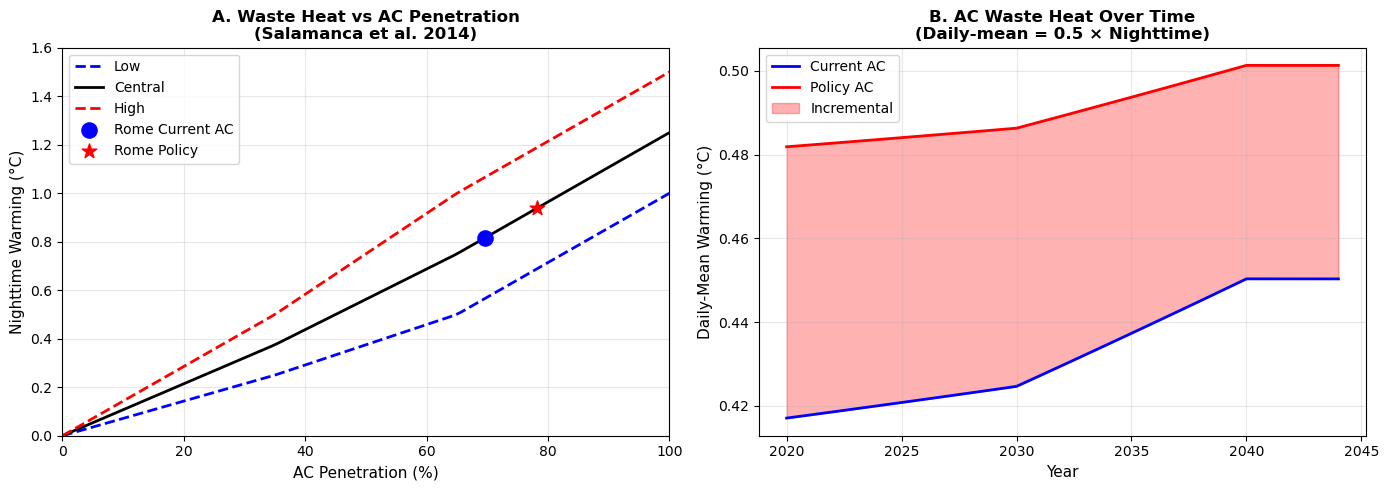

✓ Saved: rome_wasteheat_visualization.png


In [27]:
print("\n" + "="*70)
print("SECTION 9A: WASTE HEAT VISUALIZATION")
print("="*70)

# Figure 1: Salamanca LUT - Penetration vs Nighttime Warming
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def dT_night_from_lut(penetration, case="central"):
    pen_points = np.array(sorted(AC_WASTEHEAT_LUT.keys()), dtype=float)
    dT_points = np.array([AC_WASTEHEAT_LUT[p][case] for p in pen_points], dtype=float)
    return float(np.interp(float(penetration), pen_points, dT_points))

# Panel A: LUT interpolation curves
ax = axes[0]
pen_range = np.linspace(0, 1, 100)

for case, style, color in [("low", "--", "blue"), ("central", "-", "black"), ("high", "--", "red")]:
    pen_points = np.array(sorted(AC_WASTEHEAT_LUT.keys()))
    dT_points = np.array([AC_WASTEHEAT_LUT[p][case] for p in pen_points])
    dT_interp = np.interp(pen_range, pen_points, dT_points)
    ax.plot(pen_range * 100, dT_interp, linestyle=style, color=color, linewidth=2, label=f"{case.title()}")

# Add city points
pen_current_first = pen_current_t[0] if "pen_current_t" in dir() else (pen_base_t[0] if "pen_base_t" in dir() else 0.69)
pen_policy_first = pen_policy_t[0] if "pen_policy_t" in dir() else (pen_pol_t[0] if "pen_pol_t" in dir() else 0.78)
dT_current = dT_night_from_lut(pen_current_first, "central")
dT_policy = dT_night_from_lut(pen_policy_first, "central")

ax.scatter([pen_current_first * 100], [dT_current], color="blue", s=120, marker="o", zorder=5, label=f"{CITY} Current AC")
ax.scatter([pen_policy_first * 100], [dT_policy], color="red", s=120, marker="*", zorder=5, label=f"{CITY} Policy")

ax.set_xlabel("AC Penetration (%)", fontsize=11)
ax.set_ylabel("Nighttime Warming (°C)", fontsize=11)
ax.set_title("A. Waste Heat vs AC Penetration\n(Salamanca et al. 2014)", fontweight="bold")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 100)
ax.set_ylim(0, 1.6)

# Panel B: Time series of warming
ax = axes[1]
current_series = dT_dm_current_t if "dT_dm_current_t" in dir() else (dT_dm_base_t if "dT_dm_base_t" in dir() else None)
policy_series = dT_dm_policy_t if "dT_dm_policy_t" in dir() else (dT_dm_pol_t if "dT_dm_pol_t" in dir() else None)
if current_series is not None and policy_series is not None:
    ax.plot(YEARS, current_series, "b-", linewidth=2, label="Current AC")
    ax.plot(YEARS, policy_series, "r-", linewidth=2, label="Policy AC")
    ax.fill_between(YEARS, current_series, policy_series, alpha=0.3, color="red", label="Incremental")
    ax.set_xlabel("Year", fontsize=11)
    ax.set_ylabel("Daily-Mean Warming (°C)", fontsize=11)
    ax.set_title("B. AC Waste Heat Over Time\n(Daily-mean = 0.5 × Nighttime)", fontweight="bold")
    ax.legend(loc="upper left")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / f"{SLUG}_wasteheat_visualization.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Saved: {SLUG}_wasteheat_visualization.png")


# SECTION 9B: TREES VS AC WASTE HEAT

Direct comparison of tree cooling benefits vs AC waste heat penalty.
- Key question: "Do trees still matter on top of AC?"

In [28]:
print("\n" + "="*70)
print("SECTION 9B: HAZARD MODIFICATION COMPARISON")
print("Both trees and AC waste heat modify the hazard (temperature)")
print("="*70)

# PART A: DIRECT TEMPERATURE COMPARISON

# Tree cooling effect
try:
    veg_aux = np.load(INT / f"{SLUG}_veg_aux_arrays.npz")
    dT_month_key = "dT2M_month_ref_uniform_approx" if "dT2M_month_ref_uniform_approx" in veg_aux.files else "dT_month_ref_uniform"
    dT_month_ref = veg_aux[dT_month_key]  # (12, H, W)
    print(f"  Loaded {dT_month_key}: shape {dT_month_ref.shape}")

    # Load population weights
    pop_2050_path = expo_manifest["scenarios"][scen_key]["2050"]["pop_npz"]
    pop_2050 = np.load(pop_2050_path)["pop"].astype("float32")
    w = np.where(np.isfinite(pop_2050) & (pop_2050 > 0), pop_2050, 0)

    # Pop-weighted summer cooling (June-August)
    summer_idx = [5, 6, 7]
    pw_dT_summer_full = np.mean([np.nansum(dT_month_ref[m] * w) / w.sum() for m in summer_idx])

    # Apply tree maturity ramp (same as benefits)
    tree_maturity = cohort_rollout_maturity_factor(
        T=T,
        ramp_years=TREE_RAMP_YEARS,
        start_age_years=TREE_START_AGE_CENTRAL,
    )
    dT_trees_t = pw_dT_summer_full * tree_maturity

    tree_cooling_mature = float(pw_dT_summer_full)
    tree_cooling_avg = float(np.nanmean(dT_trees_t))
except Exception as exc:
    print(f"  ⚠ Could not compute tree cooling trajectory from veg_aux arrays: {exc}")
    tree_cooling_mature = np.nan
    tree_cooling_avg = np.nan
    dT_trees_t = np.full(T, np.nan, dtype=float)

# AC waste heat warming (incremental from policy)
ac_warming_avg = float(dT_dm_inc_t.mean())
ac_warming_max = float(dT_dm_inc_t.max())

ratio_waste_vs_trees = np.nan
if np.isfinite(tree_cooling_avg) and abs(tree_cooling_avg) > 1e-12:
    ratio_waste_vs_trees = abs(ac_warming_avg / tree_cooling_avg)

print("\n" + "─"*60)
print("PART A: DIRECT HAZARD MODIFICATION (Temperature Change)")
print("─"*60)
print(f"")
print(f"  TREE COOLING (hazard reduction):")
print(f"    At maturity:     {tree_cooling_mature:>+8.4f}°C")
print(f"    25-year avg:     {tree_cooling_avg:>+8.4f}°C")
print(f"")
print(f"  AC WASTE HEAT (hazard increase - INCREMENTAL policy vs current AC):")
print(f"    Maximum:         {ac_warming_max:>+8.4f}°C")
print(f"    25-year avg:     {ac_warming_avg:>+8.4f}°C")
print(f"")
if np.isfinite(ratio_waste_vs_trees):
    print(f"  ─────────────────────────────────────────────────")
    print(f"  RATIO (waste heat / tree cooling):  {ratio_waste_vs_trees:.1f}×")
    print(f"  ─────────────────────────────────────────────────")
    print(f"")
    print(f"  → AC waste heat is ~{ratio_waste_vs_trees:.0f}× larger than tree cooling")
    print(f"  → Trees CANNOT offset the incremental waste heat from AC policy")
else:
    print("  ─────────────────────────────────────────────────")
    print("  RATIO (waste heat / tree cooling):  n/a (tree cooling unavailable)")
    print("  ─────────────────────────────────────────────────")

# PART B: HEALTH IMPACT OF HAZARD CHANGES

print("\n" + "─"*60)
print("PART B: HEALTH IMPACT OF HAZARD MODIFICATIONS")
print("─"*60)

# Trees-on-top avoided deaths (from the hazard reduction)
cum_trees_top = float(trees_on_top_25y.sum())

# AC waste heat extra deaths (from the hazard increase)
cum_penalty = float(warming_penalty_t.sum())

# Net effect
net_trees_cum = cum_trees_top - cum_penalty

print(f"")
print(f"  TREE COOLING → Deaths avoided (trees-on-top):")
print(f"    25-year cumulative:  {cum_trees_top:>8.1f} deaths avoided")
print(f"")
print(f"  AC WASTE HEAT → Extra deaths (incremental warming):")
print(f"    25-year cumulative:  {cum_penalty:>8.1f} extra deaths")
print(f"")
print(f"  ─────────────────────────────────────────────────")
print(f"  NET HAZARD EFFECT:     {net_trees_cum:>8.1f} deaths")
print(f"  ─────────────────────────────────────────────────")

# PART C: KEY INSIGHTS

print("\n" + "─"*60)
print("PART C: KEY INSIGHTS")
print("─"*60)
print(f"")
print(f"  1. HAZARD COMPARISON:")
print(f"     Both trees and AC waste heat modify TEMPERATURE (the hazard)")
print(f"     Trees:     {tree_cooling_avg:+.4f}°C (cooling = hazard reduction)")
print(f"     AC waste:  {ac_warming_avg:+.4f}°C (warming = hazard increase)")
print(f"")
print(f"  2. WHY AC WASTE HEAT DOMINATES:")
print(f"     - Trees affect ~{DELTA_INDEX:.1f} GVI points across the city")
print(f"     - AC waste heat affects the ENTIRE urban area")
print(f"     - Salamanca et al. (2014): 0.5-1.0°C nighttime warming at 65% AC")
print(f"       → We halve to {0.75*0.5:.3f}°C daily-mean (our hazard metric)")
print(f"")
print(f"  3. HOWEVER - Trees still provide INDEPENDENT benefit:")
print(f"     - Trees alone (vs current AC reference): {CUM_trees:.1f} deaths avoided")
print(f"     - This benefit exists regardless of AC policy")
print(f"")
print(f"  4. AC POLICY NET BENEFIT (despite waste heat):")
print(f"     - AC GROSS benefit: {CUM_ac_gross:.1f} deaths avoided (cooling)")
print(f"     - AC penalty:      -{cum_penalty:.1f} deaths (waste heat)")
print(f"     - AC NET benefit:   {CUM_ac_net:.1f} deaths avoided")
print(f"")

# Build comparison DataFrame for export
comparison_df = pd.DataFrame({
    "year": YEARS,
    "tree_cooling_C": dT_trees_t,
    "ac_warming_C": dT_dm_inc_t,
    "net_dT_C": dT_trees_t + dT_dm_inc_t,
    "trees_on_top_deaths": trees_on_top_25y,
    "ac_penalty_deaths": warming_penalty_t,
    "net_health_impact": trees_on_top_25y - warming_penalty_t,
})

comparison_df.to_csv(TAB_DIR / f"{SLUG}_hazard_modification_comparison.csv", index=False)
print(f"\n✓ Saved: {SLUG}_hazard_modification_comparison.csv")



SECTION 9B: HAZARD MODIFICATION COMPARISON
Both trees and AC waste heat modify the hazard (temperature)
  Loaded dT2M_month_ref_uniform_approx: shape (12, 301, 301)
  ⚠ Could not compute tree cooling trajectory from veg_aux arrays: name 'cohort_rollout_maturity_factor' is not defined

────────────────────────────────────────────────────────────
PART A: DIRECT HAZARD MODIFICATION (Temperature Change)
────────────────────────────────────────────────────────────

  TREE COOLING (hazard reduction):
    At maturity:         +nan°C
    25-year avg:         +nan°C

  AC WASTE HEAT (hazard increase - INCREMENTAL policy vs current AC):
    Maximum:          +0.0648°C
    25-year avg:      +0.0583°C

  ─────────────────────────────────────────────────
  RATIO (waste heat / tree cooling):  n/a (tree cooling unavailable)
  ─────────────────────────────────────────────────

────────────────────────────────────────────────────────────
PART B: HEALTH IMPACT OF HAZARD MODIFICATIONS
──────────────────

# SECTION 9C: POLICY CONSTRAINTS ANALYSIS


Evaluate impact of political/equity constraints on optimal policy mix.

In [29]:
print("\n" + "="*70)
print("SECTION 9C: POLICY CONSTRAINTS ANALYSIS")
print("="*70)

def evaluate_constrained_mix(budget, min_trees=0.0, max_ac=1.0, include_ews=True):
    """Find optimal mix under constraints."""
    best = {"cost": 0, "benefit": 0, "trees": 0, "ac": 0, "ews": 0}
    
    for t in np.arange(min_trees, 1.01, 0.02):
        for a in np.arange(0, min(max_ac, 1.0) + 0.01, 0.02):
            e = 1.0 if include_ews else 0.0
            cost = t * PV_tree_unit + a * PV_ac_unit + e * PV_ews_unit
            if cost <= budget:
                benefit = t * BEN_tree_unit + a * BEN_ac_unit + e * BEN_ews_unit
                if benefit > best["benefit"]:
                    best = {"cost": cost, "benefit": benefit, "trees": t, "ac": a, "ews": e}
    return best

# Test at €1.5B budget
test_budget = 1_500_000_000.0
scenarios = [
    {"name": "Unconstrained", "min_trees": 0.0, "max_ac": 1.0},
    {"name": "Min 20% Trees", "min_trees": 0.2, "max_ac": 1.0},
    {"name": "Max 80% AC", "min_trees": 0.0, "max_ac": 0.8},
    {"name": "Balanced", "min_trees": 0.2, "max_ac": 0.8},
]

results = []
for s in scenarios:
    r = evaluate_constrained_mix(test_budget, min_trees=s["min_trees"], max_ac=s["max_ac"])
    r["scenario"] = s["name"]
    results.append(r)

constraint_df = pd.DataFrame(results)

print(f"\nPolicy Constraint Analysis (Budget: €{test_budget/1e9:.1f}B)")
print("="*70)
print(f"{'Scenario':<20} {'Trees%':>8} {'AC%':>8} {'EWS%':>8} {'Deaths':>12}")
print("-"*70)
for _, row in constraint_df.iterrows():
    print(f"{row['scenario']:<20} {row['trees']*100:>7.0f}% {row['ac']*100:>7.0f}% {row['ews']*100:>7.0f}% {row['benefit']:>12.0f}")

# Cost of constraints
unconstrained = constraint_df[constraint_df['scenario'] == 'Unconstrained'].iloc[0]
print("\nCost of constraints (fewer deaths avoided):")
for _, row in constraint_df.iterrows():
    if row['scenario'] != 'Unconstrained':
        cost_of_constraint = unconstrained['benefit'] - row['benefit']
        print(f"  {row['scenario']}: {cost_of_constraint:.0f} deaths")

constraint_df.to_csv(TAB_DIR / f"{SLUG}_policy_constraints.csv", index=False)
print(f"\n✓ Saved: {SLUG}_policy_constraints.csv")


SECTION 9C: POLICY CONSTRAINTS ANALYSIS

Policy Constraint Analysis (Budget: €1.5B)
Scenario               Trees%      AC%     EWS%       Deaths
----------------------------------------------------------------------
Unconstrained            100%     100%     100%         1853
Min 20% Trees            100%     100%     100%         1853
Max 80% AC               100%      80%     100%         1713
Balanced                 100%      80%     100%         1713

Cost of constraints (fewer deaths avoided):
  Min 20% Trees: 0 deaths
  Max 80% AC: 140 deaths
  Balanced: 140 deaths

✓ Saved: rome_policy_constraints.csv


# SECTION 9D: PUBLIC VS PRIVATE COSTS

Breakdown of who bears the costs for each policy.



SECTION 9D: PUBLIC VS PRIVATE COST BREAKDOWN

Cost Allocation by Policy (25-year PV)
Policy       Total (M€)  Public (M€) Private (M€)   Public %
----------------------------------------------------------------------
Trees             346.7        346.7          0.0       100%
AC                873.5         50.7        822.8         6%
EWS                22.0         22.0          0.0       100%


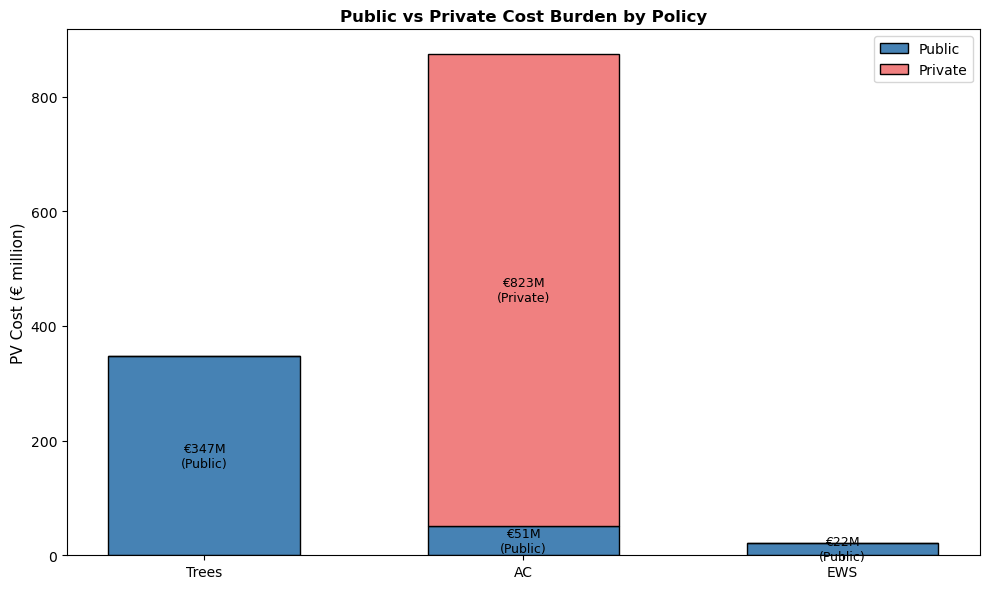


✓ Saved: rome_public_private_costs.png
✓ Saved: rome_public_private_costs.csv


In [30]:
print("\n" + "="*70)
print("SECTION 9D: PUBLIC VS PRIVATE COST BREAKDOWN")
print("="*70)

# Cost allocation assumptions
# Trees: 100% public (city plants and maintains)
# AC: CAPEX split (private purchase, some subsidies), Electricity private, Maintenance mixed
# EWS: 100% public (government warning system)

# Assumptions for AC cost split (these could be parameterized)
AC_CAPEX_PUBLIC_SHARE = 0.20  # 20% subsidy
AC_CAPEX_PRIVATE_SHARE = 0.80
AC_MAINT_PUBLIC_SHARE = 0.0   # Private maintenance
AC_MAINT_PRIVATE_SHARE = 1.0
AC_ELEC_PUBLIC_SHARE = 0.0    # Private electricity bills
AC_ELEC_PRIVATE_SHARE = 1.0

public_private = {
    "Trees": {
        "total_pv": PV_trees_total,
        "public_pv": PV_trees_total * 1.0,  # 100% public
        "private_pv": 0,
        "public_share": 1.0,
    },
    "AC": {
        "total_pv": PV_ac_total,
        "public_pv": (PV_ac_capex * AC_CAPEX_PUBLIC_SHARE + 
                      PV_ac_maint * AC_MAINT_PUBLIC_SHARE +
                      PV_ac_elec * AC_ELEC_PUBLIC_SHARE),
        "private_pv": (PV_ac_capex * AC_CAPEX_PRIVATE_SHARE + 
                       PV_ac_maint * AC_MAINT_PRIVATE_SHARE +
                       PV_ac_elec * AC_ELEC_PRIVATE_SHARE),
        "public_share": AC_CAPEX_PUBLIC_SHARE * PV_ac_capex / PV_ac_total,
    },
    "EWS": {
        "total_pv": PV_ews_total,
        "public_pv": PV_ews_total * 1.0,  # 100% public
        "private_pv": 0,
        "public_share": 1.0,
    },
}

print("\nCost Allocation by Policy (25-year PV)")
print("="*70)
print(f"{'Policy':<10} {'Total (M€)':>12} {'Public (M€)':>12} {'Private (M€)':>12} {'Public %':>10}")
print("-"*70)
for policy, costs in public_private.items():
    print(f"{policy:<10} {costs['total_pv']/1e6:>12.1f} {costs['public_pv']/1e6:>12.1f} "
          f"{costs['private_pv']/1e6:>12.1f} {costs['public_share']*100:>9.0f}%")

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

policies = list(public_private.keys())
public_costs = [public_private[p]['public_pv']/1e6 for p in policies]
private_costs = [public_private[p]['private_pv']/1e6 for p in policies]

x = np.arange(len(policies))
width = 0.6

bars_public = ax.bar(x, public_costs, width, label='Public', color='steelblue', edgecolor='black')
bars_private = ax.bar(x, private_costs, width, bottom=public_costs, label='Private', color='lightcoral', edgecolor='black')

ax.set_ylabel('PV Cost (€ million)', fontsize=11)
ax.set_title('Public vs Private Cost Burden by Policy', fontweight='bold', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(policies)
ax.legend()

# Add value labels
for i, (pub, priv) in enumerate(zip(public_costs, private_costs)):
    if pub > 0:
        ax.text(i, pub/2, f'€{pub:.0f}M\n(Public)', ha='center', va='center', fontsize=9)
    if priv > 0:
        ax.text(i, pub + priv/2, f'€{priv:.0f}M\n(Private)', ha='center', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / f"{SLUG}_public_private_costs.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ Saved: {SLUG}_public_private_costs.png")

# Save to CSV
pp_df = pd.DataFrame([
    {"policy": k, **v} for k, v in public_private.items()
])
pp_df.to_csv(TAB_DIR / f"{SLUG}_public_private_costs.csv", index=False)
print(f"✓ Saved: {SLUG}_public_private_costs.csv")

# SECTION 9E: TREE AGE SENSITIVITY

Compare cost-effectiveness with pre-grown (age 5) vs newly planted (age 0) trees.

In [31]:
print("\n" + "="*70)
print("SECTION 9E: TREE AGE SENSITIVITY")
print("="*70)

# recomputing O&M with age 0 trees
if 'npv_om_cohorts_scaled' in dir():
    PV_trees_om_age0, om_stream_age0 = npv_om_cohorts_scaled(
        DELTA_INDEX, T, R, OM_PER_INDEX_PT_YR,
        TREE_RAMP_YEARS, TREE_LIFETIME, start_age_years=0  # Newly planted
    )
    
    PV_trees_total_age0 = PV_trees_capex + PV_trees_om_age0
    
    # Benefits also differ (slower maturity)
    def cohort_rollout_maturity_factor_benefits(T, ramp_years, start_age_years=0):
        """Maturity factor for benefits."""
        plant_share = np.ones(T, dtype=float) / T  # Linear rollout
        ages = np.arange(T + 1, dtype=float)
        maturity = np.minimum((ages + start_age_years) / ramp_years, 1.0)
        return np.convolve(plant_share, maturity)[:T]
    
    mat_factor_age5 = cohort_rollout_maturity_factor_benefits(T, TREE_RAMP_YEARS, start_age_years=5)
    mat_factor_age0 = cohort_rollout_maturity_factor_benefits(T, TREE_RAMP_YEARS, start_age_years=0)
    
    # Scale benefits
    CUM_trees_age5 = CUM_trees  # Already computed with age 5
    CUM_trees_age0 = CUM_trees * (mat_factor_age0.sum() / mat_factor_age5.sum())
    
    print(f"\nTree Age Sensitivity (Central O&M):")
    print("="*70)
    print(f"{'Metric':<30} {'Age 5 (Pre-grown)':>20} {'Age 0 (Planted)':>20}")
    print("-"*70)
    print(f"{'PV O&M':<30} €{PV_trees_om/1e6:>19.1f}M €{PV_trees_om_age0/1e6:>19.1f}M")
    print(f"{'PV Total':<30} €{PV_trees_total/1e6:>19.1f}M €{PV_trees_total_age0/1e6:>19.1f}M")
    print(f"{'Avoided Deaths (25y)':<30} {CUM_trees_age5:>20.1f} {CUM_trees_age0:>20.1f}")
    print(f"{'€/Death':<30} €{safe_ratio(PV_trees_total, CUM_trees_age5)/1e6:>19.1f}M €{safe_ratio(PV_trees_total_age0, CUM_trees_age0)/1e6:>19.1f}M")
    
    # Save results
    age_sensitivity = pd.DataFrame([
        {"tree_age": 5, "pv_om": PV_trees_om, "pv_total": PV_trees_total, 
         "avoided_deaths": CUM_trees_age5, "cost_per_death": safe_ratio(PV_trees_total, CUM_trees_age5)},
        {"tree_age": 0, "pv_om": PV_trees_om_age0, "pv_total": PV_trees_total_age0,
         "avoided_deaths": CUM_trees_age0, "cost_per_death": safe_ratio(PV_trees_total_age0, CUM_trees_age0)},
    ])
    age_sensitivity.to_csv(TAB_DIR / f"{SLUG}_tree_age_sensitivity.csv", index=False)
    print(f"\n✓ Saved: {SLUG}_tree_age_sensitivity.csv")


SECTION 9E: TREE AGE SENSITIVITY

Tree Age Sensitivity (Central O&M):
Metric                            Age 5 (Pre-grown)      Age 0 (Planted)
----------------------------------------------------------------------
PV O&M                         €              185.8M €              128.6M
PV Total                       €              346.7M €              289.5M
Avoided Deaths (25y)                          181.3                124.5
€/Death                        €                1.9M €                2.3M

✓ Saved: rome_tree_age_sensitivity.csv


# SECTION 9F: DISCOUNT RATE SENSITIVITY


Evaluate robustness of cost-effectiveness rankings to discount rate assumptions.


In [32]:
print("\n" + "="*70)
print("SECTION 9F: DISCOUNT RATE SENSITIVITY")
print("="*70)

discount_rates = [0.01, 0.03, 0.05, 0.07]

def compute_pv_at_rate(r):
    """Recompute key PVs at a different discount rate."""
    # Annuity factor
    af = (1 - (1 + r) ** (-T)) / r
    
    # Trees CAPEX (simple recompute)
    inc = DELTA_INDEX / T
    pv_trees_capex_r = sum(CAPEX_PER_INDEX_PT * inc / ((1 + r) ** t) for t in range(1, T + 1))
    
    # Trees O&M (approximation using ratio)
    ratio = pv_from_stream(om_stream, r) / pv_from_stream(om_stream, R) if sum(om_stream) > 0 else 1.0
    pv_trees_om_r = PV_trees_om * ratio
    
    # AC (approximation using stream)
    pv_ac_r = PV_ac_total * (af / AF)  # Simple scaling
    
    # EWS (approximation)
    pv_ews_r = PV_ews_total * (af / AF)
    
    return {
        "discount_rate": r,
        "trees_pv": pv_trees_capex_r + pv_trees_om_r,
        "ac_pv": pv_ac_r,
        "ews_pv": pv_ews_r,
        "trees_per_death": safe_ratio(pv_trees_capex_r + pv_trees_om_r, CUM_trees),
        "ac_per_death": safe_ratio(pv_ac_r, CUM_ac_net),
        "ews_per_death": safe_ratio(pv_ews_r, CUM_ews) if CUM_ews > 0 else np.inf,
    }

discount_results = [compute_pv_at_rate(r) for r in discount_rates]
discount_df = pd.DataFrame(discount_results)

print("\nCost-Effectiveness by Discount Rate (€M/death)")
print("="*70)
print(f"{'Rate':>8} {'Trees':>15} {'AC (NET)':>15} {'EWS':>15}")
print("-"*70)
for _, row in discount_df.iterrows():
    print(f"{row['discount_rate']*100:>7.0f}% €{row['trees_per_death']/1e6:>14.1f}M "
          f"€{row['ac_per_death']/1e6:>14.1f}M €{row['ews_per_death']/1e6:>14.2f}M")

# Key finding: ranking stable?
rankings = []
for _, row in discount_df.iterrows():
    r = [
        ("Trees", row['trees_per_death']),
        ("AC", row['ac_per_death']),
        ("EWS", row['ews_per_death']),
    ]
    r.sort(key=lambda x: x[1])
    rankings.append([x[0] for x in r])

print(f"\nRanking stability: {len(set(tuple(r) for r in rankings))} unique ranking(s) across {len(discount_rates)} rates")
if len(set(tuple(r) for r in rankings)) == 1:
    print("✓ Cost-effectiveness ranking is ROBUST to discount rate")
else:
    print("⚠ Ranking changes with discount rate")

discount_df.to_csv(TAB_DIR / f"{SLUG}_discount_sensitivity.csv", index=False)
print(f"\n✓ Saved: {SLUG}_discount_sensitivity.csv")


SECTION 9F: DISCOUNT RATE SENSITIVITY

Cost-Effectiveness by Discount Rate (€M/death)
    Rate           Trees        AC (NET)             EWS
----------------------------------------------------------------------
      1% €           2.6M €           1.6M €          0.03M
      3% €           1.9M €           1.3M €          0.02M
      5% €           1.5M €           1.0M €          0.02M
      7% €           1.1M €           0.8M €          0.02M

Ranking stability: 1 unique ranking(s) across 4 rates
✓ Cost-effectiveness ranking is ROBUST to discount rate

✓ Saved: rome_discount_sensitivity.csv


# SECTION 9G: BENEFITS TIMELINE


When do benefits materialize for each policy?



SECTION 9G: BENEFITS TIMELINE


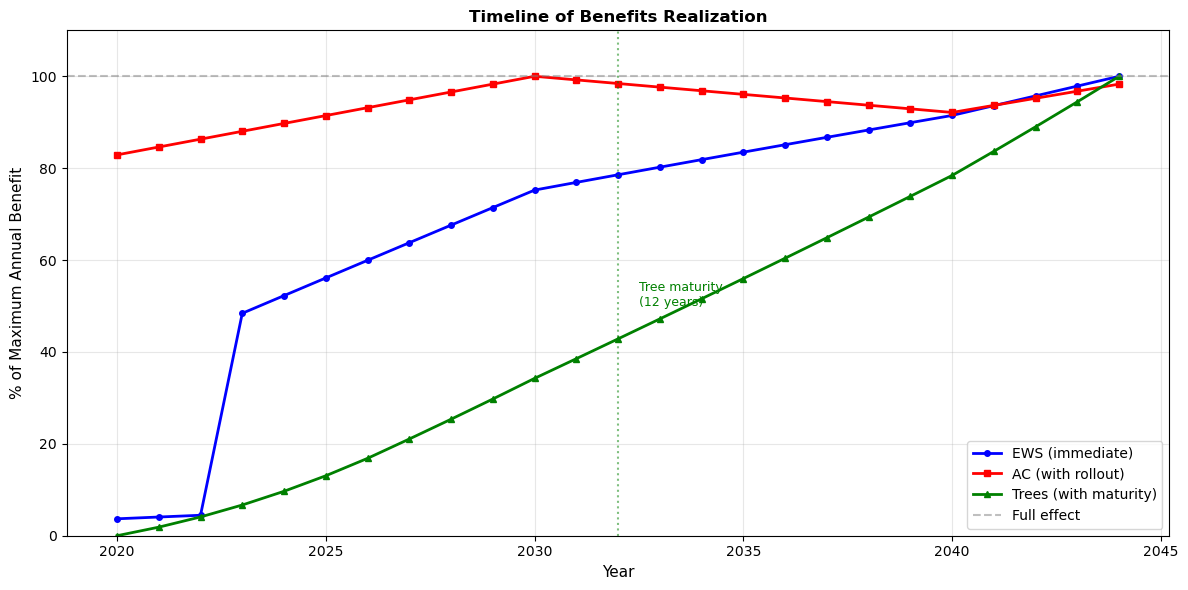


✓ Saved: rome_benefits_timeline.png

Time to 50% of maximum annual benefit:
  EWS: Year 2024 (5 years from start)
  AC: Year 2020 (1 years from start)
  Trees: Year 2034 (15 years from start)

ADDITIONAL ANALYSES COMPLETE


In [33]:
print("\n" + "="*70)
print("SECTION 9G: BENEFITS TIMELINE")
print("="*70)

# timeline visualization
fig, ax = plt.subplots(figsize=(12, 6))

# EWS: Immediate full effect (with ramp if specified)
ews_timeline = np.ones(T)
if 'ews_25y' in dir():
    ews_timeline = ews_25y / ews_25y.max() if ews_25y.max() > 0 else ews_timeline

# AC: Immediate after installation (scales with coverage)
ac_timeline = ac_gross_25y / ac_gross_25y.max() if 'ac_gross_25y' in dir() and ac_gross_25y.max() > 0 else np.ones(T)

# Trees: Delayed maturity
trees_timeline = trees_only_25y / trees_only_25y.max() if 'trees_only_25y' in dir() and trees_only_25y.max() > 0 else np.linspace(0.1, 1, T)

ax.plot(YEARS, ews_timeline * 100, 'b-', linewidth=2, label='EWS (immediate)', marker='o', markersize=4)
ax.plot(YEARS, ac_timeline * 100, 'r-', linewidth=2, label='AC (with rollout)', marker='s', markersize=4)
ax.plot(YEARS, trees_timeline * 100, 'g-', linewidth=2, label='Trees (with maturity)', marker='^', markersize=4)

ax.axhline(y=100, color='gray', linestyle='--', alpha=0.5, label='Full effect')
ax.axvline(x=YEARS[0] + TREE_RAMP_YEARS, color='green', linestyle=':', alpha=0.5)
ax.text(YEARS[0] + TREE_RAMP_YEARS + 0.5, 50, f'Tree maturity\n({TREE_RAMP_YEARS} years)', fontsize=9, color='green')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('% of Maximum Annual Benefit', fontsize=11)
ax.set_title('Timeline of Benefits Realization', fontweight='bold', fontsize=12)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 110)

plt.tight_layout()
plt.savefig(FIG_DIR / f"{SLUG}_benefits_timeline.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ Saved: {SLUG}_benefits_timeline.png")

# Summary statistics
print("\nTime to 50% of maximum annual benefit:")
for name, timeline in [("EWS", ews_timeline), ("AC", ac_timeline), ("Trees", trees_timeline)]:
    idx_50 = np.argmax(timeline >= 0.5)
    print(f"  {name}: Year {YEARS[idx_50]} ({idx_50 + 1} years from start)")


print("\n" + "="*70)
print("ADDITIONAL ANALYSES COMPLETE")
print("="*70)

# SECTION 9H: POLICY EFFECTIVENESS COMPARISON

In [34]:
# Comparing policies using % reduction in heat deaths (HAF-style metrics)
# Aligned with Urban et al. (2025) methodology for comparability

In [35]:
print("\n" + "="*70)
print("SECTION 9H: POLICY EFFECTIVENESS (% REDUCTION IN HEAT DEATHS)")
print("Comparable to Urban et al. (2025) HAF change methodology")
print("="*70)


SECTION 9H: POLICY EFFECTIVENESS (% REDUCTION IN HEAT DEATHS)
Comparable to Urban et al. (2025) HAF change methodology


I'm trying to compare what I get to the paper of Urban on EWS

In [36]:
# Load baseline deaths from NB6 output
baseline_deaths_path = TAB_DIR / f"annual_heat_deaths_baseline_current_ac_{SLUG}.csv"

if not baseline_deaths_path.exists():
    raise FileNotFoundError(
        f"Missing baseline deaths file: {baseline_deaths_path}. Run NB6 first."
    )

baseline_df = pd.read_csv(baseline_deaths_path)
print(f"\n✓ Loaded: {baseline_deaths_path.name}")
print(f"  Columns: {list(baseline_df.columns)}")

if "deaths_overall" not in baseline_df.columns:
    raise KeyError(
        f"Expected 'deaths_overall' column in {baseline_deaths_path.name}; got {list(baseline_df.columns)}"
    )

anchor_years = baseline_df["year"].to_numpy(int)
anchor_deaths = baseline_df["deaths_overall"].to_numpy(float)

print("\n  Baseline heat deaths (anchor years):")
for y, d in zip(anchor_years, anchor_deaths):
    print(f"    {int(y)}: {d:.1f} deaths")

# Interpolate to 25-year horizon
baseline_deaths_25y = np.interp(YEARS, anchor_years, anchor_deaths)
BASELINE_DEATHS_CUM = float(baseline_deaths_25y.sum())

print("\n  25-year baseline heat deaths (interpolated):")
print(f"    Year 1 ({YEARS[0]}):  {baseline_deaths_25y[0]:.1f}")
print(f"    Year 25 ({YEARS[-1]}): {baseline_deaths_25y[-1]:.1f}")
print(f"    TOTAL:           {BASELINE_DEATHS_CUM:,.1f} deaths")

# Population for per-100K calculations
pop_avg = np.mean([pop_total_for_year(y) for y in YEARS])
print(f"\n  Average population (25y): {pop_avg:,.0f}")



✓ Loaded: annual_heat_deaths_baseline_current_ac_rome.csv
  Columns: ['year', 'deaths_overall', 'deaths_on_warning_days', 'frac_deaths_on_warning_days', 'n_warning_days']

  Baseline heat deaths (anchor years):
    2020: 662.5 deaths
    2030: 822.3 deaths
    2040: 885.5 deaths
    2050: 1023.8 deaths

  25-year baseline heat deaths (interpolated):
    Year 1 (2020):  662.5
    Year 25 (2044): 940.8
    TOTAL:           20,417.6 deaths

  Average population (25y): 2,547,981


In [37]:
# PART 2: COMPUTE % REDUCTION BY POLICY

In [38]:
print("\n" + "─"*60)
print("PART 2: POLICY EFFECTIVENESS (% Reduction in Heat Deaths)")
print("─"*60)

# Calculate % reduction for each policy (safe when baseline is zero)
def safe_pct(value, baseline):
    return float(100.0 * value / baseline) if baseline > 1e-9 else 0.0

baseline_has_signal = BASELINE_DEATHS_CUM > 1e-9
pct_trees = safe_pct(CUM_trees, BASELINE_DEATHS_CUM)
pct_ac_gross = safe_pct(CUM_ac_gross, BASELINE_DEATHS_CUM)
pct_ac_net = safe_pct(CUM_ac_net, BASELINE_DEATHS_CUM)
pct_ews = safe_pct(CUM_ews, BASELINE_DEATHS_CUM) if CUM_ews > 0 else 0.0
pct_penalty = safe_pct(CUM_penalty, BASELINE_DEATHS_CUM)
if not baseline_has_signal:
    print("  Note: baseline cumulative heat deaths = 0, so % reductions are set to 0.0 by convention.")

# Calculate deaths per 100K per year
deaths_per_100k_trees = (CUM_trees / T) / (pop_avg / 100_000)
deaths_per_100k_ac_net = (CUM_ac_net / T) / (pop_avg / 100_000)
deaths_per_100k_ews = (CUM_ews / T) / (pop_avg / 100_000) if CUM_ews > 0 else 0

ews_mode = str(ews_cfg.get("interpretation", "marginal")).strip().lower()
ews_label = f"EWS ({ews_mode})"

print(f"""
  ┌─────────────────────────────────────────────────────────────────┐
  │  POLICY              │ Avoided │ % of Heat │ Deaths/100K │
  │                      │ Deaths  │  Deaths   │   per year  │
  ├─────────────────────────────────────────────────────────────────┤
  │  Trees (uniform)     │ {CUM_trees:>7.1f} │   {pct_trees:>5.1f}%  │    {deaths_per_100k_trees:>5.2f}    │
  │  AC (GROSS)          │ {CUM_ac_gross:>7.1f} │   {pct_ac_gross:>5.1f}%  │      —      │
  │  AC (NET)            │ {CUM_ac_net:>7.1f} │   {pct_ac_net:>5.1f}%  │    {deaths_per_100k_ac_net:>5.2f}    │
  │  {ews_label:<18} │ {CUM_ews:>7.1f} │   {pct_ews:>5.1f}%  │    {deaths_per_100k_ews:>5.2f}    │
  ├─────────────────────────────────────────────────────────────────┤
  │  AC waste heat       │ {CUM_penalty:>+7.1f} │  {pct_penalty:>+5.1f}%  │      —      │
  │  (penalty)           │         │           │             │
  └─────────────────────────────────────────────────────────────────┘

  Baseline: {BASELINE_DEATHS_CUM:,.0f} heat deaths over 25 years
""")



────────────────────────────────────────────────────────────
PART 2: POLICY EFFECTIVENESS (% Reduction in Heat Deaths)
────────────────────────────────────────────────────────────

  ┌─────────────────────────────────────────────────────────────────┐
  │  POLICY              │ Avoided │ % of Heat │ Deaths/100K │
  │                      │ Deaths  │  Deaths   │   per year  │
  ├─────────────────────────────────────────────────────────────────┤
  │  Trees (uniform)     │   181.3 │     0.9%  │     0.28    │
  │  AC (GROSS)          │   818.2 │     4.0%  │      —      │
  │  AC (NET)            │   698.2 │     3.4%  │     1.10    │
  │  EWS (marginal)     │   973.7 │     4.8%  │     1.53    │
  ├─────────────────────────────────────────────────────────────────┤
  │  AC waste heat       │  +120.0 │   +0.6%  │      —      │
  │  (penalty)           │         │           │             │
  └─────────────────────────────────────────────────────────────────┘

  Baseline: 20,418 heat deaths over

In [39]:
# PART 3: COMPARISON WITH LITERATURE

In [40]:
print("─"*60)
print("PART 3: COMPARISON WITH LITERATURE")
print("─"*60)

ews_mode = str(ews_cfg.get("interpretation", "marginal")).strip().lower()

city_system_note = {
    "rome": "the city HHWWS operational since 2004 → part of total effect already embedded in baseline",
    "copenhagen": "the city baseline warning system assumptions differ from Mediterranean mature systems",
    "copenhagen": "the city has no mature baseline HHWWS in the model setup → effect is treated as system introduction",
}

if ews_mode == "counterfactual":
    interp_block = (
        "    • Urban measures TOTAL HPP effect (counterfactual: no HPP)\n"
        "    • We also use COUNTERFACTUAL interpretation for this city\n"
        "    • This makes our % reduction directly comparable to total-effect literature"
    )
else:
    note = city_system_note.get(SLUG, "Baseline embeds existing adaptation context for this city")
    interp_block = (
        "    • Urban measures TOTAL HPP effect (counterfactual: no HPP)\n"
        "    • We measure MARGINAL enhancement on top of existing baseline adaptation\n"
        f"    • {note}\n"
        f"    • Gap: 11.6% - {pct_ews:.1f}% ≈ {11.6 - pct_ews:.1f}% (embedded effect + scope differences)"
    )

print(f"""
  Urban et al. (2025) - Italy HPP effectiveness:
    HAF change:        -11.6% [-16.4; -6.7]
    Deaths/100K/year:  -0.9 [-1.2; -0.5]

  Our EWS ({ews_mode}):
    % reduction:       -{pct_ews:.1f}%
    Deaths/100K/year:  -{deaths_per_100k_ews:.1f}

  Interpretation:
{interp_block}
""")


────────────────────────────────────────────────────────────
PART 3: COMPARISON WITH LITERATURE
────────────────────────────────────────────────────────────

  Urban et al. (2025) - Italy HPP effectiveness:
    HAF change:        -11.6% [-16.4; -6.7]
    Deaths/100K/year:  -0.9 [-1.2; -0.5]

  Our EWS (marginal):
    % reduction:       -4.8%
    Deaths/100K/year:  -1.5

  Interpretation:
    • Urban measures TOTAL HPP effect (counterfactual: no HPP)
    • We measure MARGINAL enhancement on top of existing baseline adaptation
    • the city HHWWS operational since 2004 → part of total effect already embedded in baseline
    • Gap: 11.6% - 4.8% ≈ 6.8% (embedded effect + scope differences)



In [41]:
# PART 4: BUILD EFFECTIVENESS DATAFRAME

In [42]:
effectiveness_df = pd.DataFrame([
    {
        "policy": "Trees (uniform)",
        "avoided_deaths_25y": CUM_trees,
        "pct_reduction": pct_trees,
        "deaths_per_100k_year": deaths_per_100k_trees,
        "interpretation": "Hazard modification (cooling)",
    },
    {
        "policy": "AC (GROSS)",
        "avoided_deaths_25y": CUM_ac_gross,
        "pct_reduction": pct_ac_gross,
        "deaths_per_100k_year": (CUM_ac_gross / T) / (pop_avg / 100_000),
        "interpretation": "Exposure reduction (indoor cooling)",
    },
    {
        "policy": "AC (NET)",
        "avoided_deaths_25y": CUM_ac_net,
        "pct_reduction": pct_ac_net,
        "deaths_per_100k_year": deaths_per_100k_ac_net,
        "interpretation": "Net of waste heat feedback",
    },
    {
        "policy": f"EWS ({str(ews_cfg.get('interpretation', 'marginal')).strip().lower()})",
        "avoided_deaths_25y": CUM_ews,
        "pct_reduction": pct_ews,
        "deaths_per_100k_year": deaths_per_100k_ews,
        "interpretation": "Vulnerability reduction (behavior)",
    },
])

print("\n  POLICY EFFECTIVENESS SUMMARY")
print("  " + "─"*70)
print(effectiveness_df.to_string(index=False))
print("  " + "─"*70)

# Save to CSV
effectiveness_df.to_csv(TAB_DIR / f"{SLUG}_policy_effectiveness.csv", index=False)
print(f"\n  ✓ Saved: {SLUG}_policy_effectiveness.csv")



  POLICY EFFECTIVENESS SUMMARY
  ──────────────────────────────────────────────────────────────────────
         policy  avoided_deaths_25y  pct_reduction  deaths_per_100k_year                      interpretation
Trees (uniform)          181.312828       0.888022              0.284638       Hazard modification (cooling)
     AC (GROSS)          818.212761       4.007389              1.284488 Exposure reduction (indoor cooling)
       AC (NET)          698.166324       3.419434              1.096031          Net of waste heat feedback
 EWS (marginal)          973.653370       4.768696              1.528510  Vulnerability reduction (behavior)
  ──────────────────────────────────────────────────────────────────────

  ✓ Saved: rome_policy_effectiveness.csv


In [43]:
# FIGURE 9H.1: FOREST PLOT - % REDUCTION BY POLICY
# (Urban et al. 2025, Figure 5)


────────────────────────────────────────────────────────────
FIGURE 9H.1: Policy Effectiveness Forest Plot
────────────────────────────────────────────────────────────


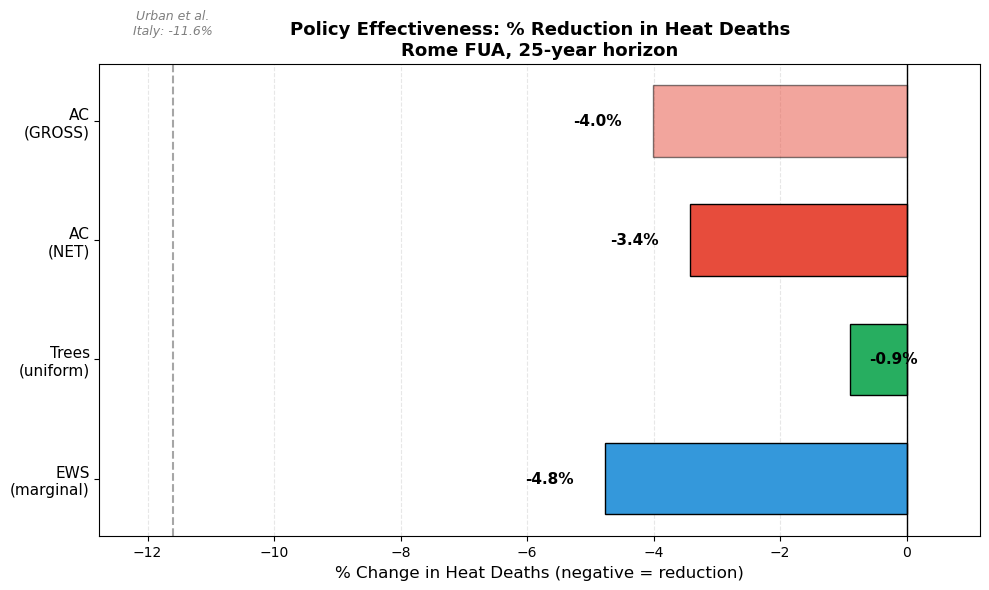

✓ Saved: rome_policy_effectiveness_forest.png


In [44]:
print("\n" + "─"*60)
print("FIGURE 9H.1: Policy Effectiveness Forest Plot")
print("─"*60)

fig, ax = plt.subplots(figsize=(10, 6))

ews_mode = str(ews_cfg.get("interpretation", "marginal")).strip().lower()
policies = [f"EWS\n({ews_mode})", "Trees\n(uniform)", "AC\n(NET)", "AC\n(GROSS)"]
reductions = [-pct_ews, -pct_trees, -pct_ac_net, -pct_ac_gross]  # Negative = reduction
colors = ["#3498db", "#27ae60", "#e74c3c", "#e74c3c"]
alphas = [1.0, 1.0, 1.0, 0.5]

y_pos = np.arange(len(policies))

# Plot bars individually to handle different alphas
for i, (y, val, color, alpha) in enumerate(zip(y_pos, reductions, colors, alphas)):
    ax.barh(y, val, color=color, alpha=alpha, edgecolor="black", height=0.6)

# Add value labels
for i, (y, val) in enumerate(zip(y_pos, reductions)):
    label_x = val - 0.5 if val < -2 else val + 0.3
    ha = "right" if val < -2 else "left"
    ax.text(label_x, y, f"{val:.1f}%", va="center", ha=ha, fontsize=11, fontweight="bold")

# Reference line
ax.axvline(0, color="black", linewidth=1)

# Urban et al. Italy reference
ax.axvline(-11.6, color="gray", linestyle="--", linewidth=1.5, alpha=0.7)
ax.text(-11.6, len(policies) - 0.3, "Urban et al.\nItaly: -11.6%", ha="center", va="bottom", fontsize=9, color="gray", style="italic")

ax.set_yticks(y_pos)
ax.set_yticklabels(policies, fontsize=11)
ax.set_xlabel("% Change in Heat Deaths (negative = reduction)", fontsize=12)
ax.set_title(f"Policy Effectiveness: % Reduction in Heat Deaths\n{CITY.title()} FUA, 25-year horizon", fontsize=13, fontweight="bold")

# Add grid
ax.xaxis.grid(True, linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

# Dynamic x-limits
axis_vals = np.array([*reductions, -11.6, 0.0], dtype=float)
xmin = float(np.nanmin(axis_vals))
xmax = float(np.nanmax(axis_vals))
pad = max(0.5, 0.10 * (xmax - xmin if xmax > xmin else 1.0))
ax.set_xlim(xmin - pad, xmax + pad)

plt.tight_layout()
plt.savefig(FIG_DIR / f"{SLUG}_policy_effectiveness_forest.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Saved: {SLUG}_policy_effectiveness_forest.png")


In [45]:
# FIGURE 9H.2: STACKED BAR - DEATHS BY SCENARIO
# (Inspired by Urban et al. 2025, Figure 4)


────────────────────────────────────────────────────────────
FIGURE 9H.2: Heat Deaths by Policy Scenario
────────────────────────────────────────────────────────────


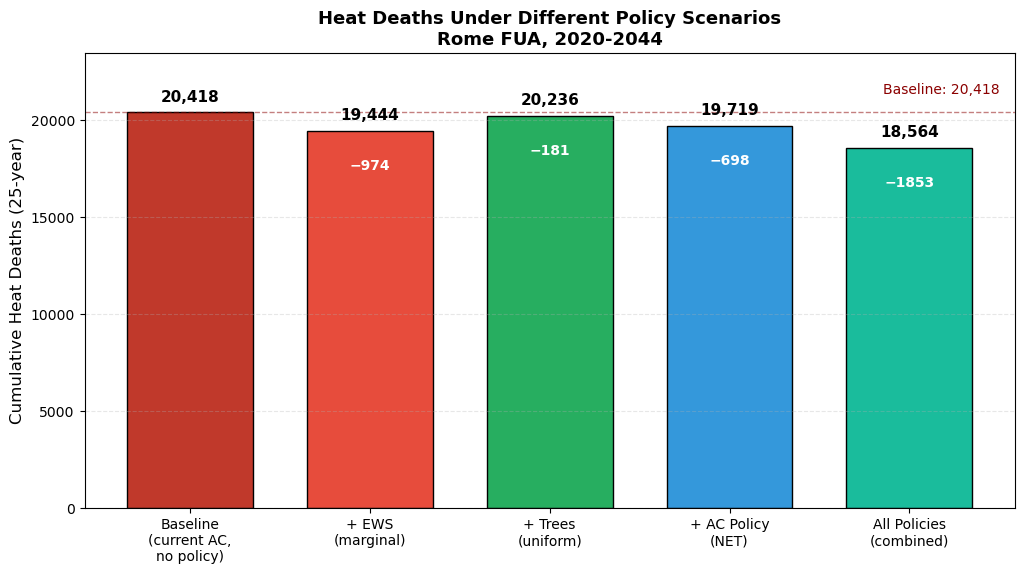

✓ Saved: rome_deaths_by_scenario.png


In [46]:
print("\n" + "─"*60)
print("FIGURE 9H.2: Heat Deaths by Policy Scenario")
print("─"*60)

fig, ax = plt.subplots(figsize=(12, 7))

# Define scenarios
scenarios = [
    "Baseline\n(current AC,\nno policy)",
    "+ EWS\n(marginal)",
    "+ Trees\n(uniform)",
    "+ AC Policy\n(NET)",
    "All Policies\n(combined)"
]

# Calculate deaths under each scenario
# Note: These are sequential additions, not independent
deaths_baseline = BASELINE_DEATHS_CUM
deaths_with_ews = deaths_baseline - CUM_ews
deaths_with_trees = deaths_baseline - CUM_trees
deaths_with_ac = deaths_baseline - CUM_ac_net

# Combined (assuming independence - upper bound estimate)
# More conservative: take max of individual effects
combined_avoided = CUM_ews + CUM_trees + CUM_ac_net  # Simple sum (upper bound)
deaths_combined = deaths_baseline - combined_avoided

deaths_values = [
    deaths_baseline,
    deaths_with_ews,
    deaths_with_trees,
    deaths_with_ac,
    max(0, deaths_combined)  # Don't go negative
]

# Colors: darker = more deaths
colors = ['#c0392b', '#e74c3c', '#27ae60', '#3498db', '#1abc9c']

x = np.arange(len(scenarios))
bars = ax.bar(x, deaths_values, color=colors, edgecolor='black', width=0.7)
y_max_data = max(max(deaths_values), deaths_baseline, 1.0)
label_offset = max(0.02 * y_max_data, 1.0)

# Add value labels on bars
for bar, val in zip(bars, deaths_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + label_offset, f'{val:,.0f}', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add avoided deaths annotations
avoided = [0, CUM_ews, CUM_trees, CUM_ac_net, combined_avoided]
for i, (bar, avo) in enumerate(zip(bars, avoided)):
    if avo > 0:
        ax.annotate(f'−{avo:.0f}', 
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, -20), textcoords='offset points',
                    ha='center', va='top', fontsize=10, color='white', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(scenarios, fontsize=10)
ax.set_ylabel("Cumulative Heat Deaths (25-year)", fontsize=12)
ax.set_title(f"Heat Deaths Under Different Policy Scenarios\n{CITY.title()} FUA, 2020-2044", 
             fontsize=13, fontweight='bold')

# Add horizontal line for baseline reference
ax.axhline(deaths_baseline, color='darkred', linestyle='--', linewidth=1, alpha=0.5)
ax.text(len(scenarios)-0.5, deaths_baseline + 2 * label_offset, f'Baseline: {deaths_baseline:,.0f}', 
        ha='right', va='bottom', fontsize=10, color='darkred')

ax.set_ylim(0, max(1.15 * y_max_data, y_max_data + 3 * label_offset))
ax.yaxis.grid(True, linestyle='--', alpha=0.3)

fig.subplots_adjust(bottom=0.23)
plt.savefig(FIG_DIR / f"{SLUG}_deaths_by_scenario.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {SLUG}_deaths_by_scenario.png")

In [47]:
# FIGURE 9H.3: DEATHS PER 100K COMPARISON (Table 1 style)


────────────────────────────────────────────────────────────
FIGURE 9H.3: Deaths per 100K Comparison Table
────────────────────────────────────────────────────────────

  POLICY EFFECTIVENESS COMPARISON
                Policy          % Reduction  Deaths/100K/year                 Mechanism
        EWS (marginal)                -4.8%             -1.53  Vulnerability (behavior)
       Trees (uniform)                -0.9%             -0.28          Hazard (cooling)
              AC (NET)                -3.4%             -1.10         Exposure (indoor)
Urban et al. Italy HPP -11.6% [-16.4; -6.7] -0.9 [-1.2; -0.5] Full HPP (counterfactual)

✓ Saved: rome_policy_effectiveness_comparison.csv

────────────────────────────────────────────────────────────
FIGURE 9H.4: Combined Policy Effectiveness Dashboard
────────────────────────────────────────────────────────────


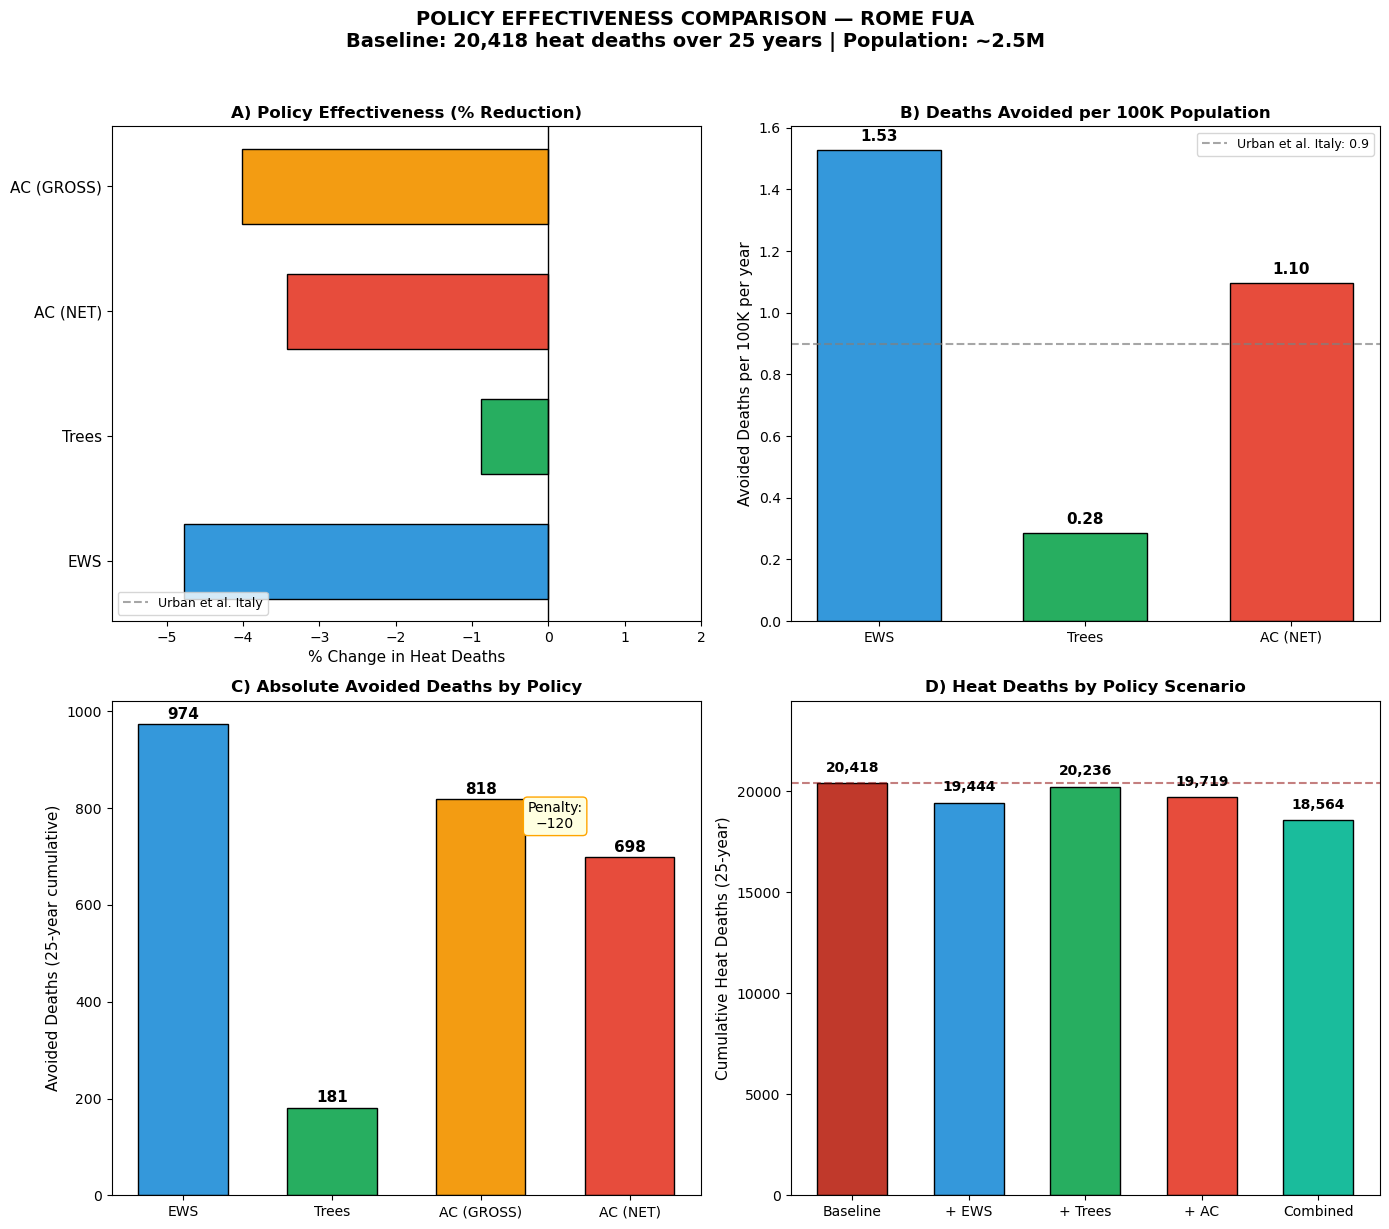

✓ Saved: rome_policy_effectiveness_dashboard.png


In [48]:
print("\n" + "─"*60)
print("FIGURE 9H.3: Deaths per 100K Comparison Table")
print("─"*60)

# Create comparison table similar to Urban et al. Table 1
comparison_table = pd.DataFrame({
    "Policy": ["EWS (marginal)", "Trees (uniform)", "AC (NET)", "Urban et al. Italy HPP"],
    "% Reduction": [f"-{pct_ews:.1f}%", f"-{pct_trees:.1f}%", f"-{pct_ac_net:.1f}%", "-11.6% [-16.4; -6.7]"],
    "Deaths/100K/year": [f"-{deaths_per_100k_ews:.2f}", f"-{deaths_per_100k_trees:.2f}", 
                         f"-{deaths_per_100k_ac_net:.2f}", "-0.9 [-1.2; -0.5]"],
    "Mechanism": ["Vulnerability (behavior)", "Hazard (cooling)", "Exposure (indoor)", "Full HPP (counterfactual)"]
})

print("\n  POLICY EFFECTIVENESS COMPARISON")
print("  " + "="*70)
print(comparison_table.to_string(index=False))
print("  " + "="*70)

# Save table
comparison_table.to_csv(TAB_DIR / f"{SLUG}_policy_effectiveness_comparison.csv", index=False)
print(f"\n✓ Saved: {SLUG}_policy_effectiveness_comparison.csv")

# FIGURE 9H.4: COMBINED VISUALIZATION (4-panel)

print("\n" + "─"*60)
print("FIGURE 9H.4: Combined Policy Effectiveness Dashboard")
print("─"*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Panel A: Forest plot (% reduction)
ax = axes[0, 0]
policies_short = ["EWS", "Trees", "AC (NET)", "AC (GROSS)"]
reductions = [-pct_ews, -pct_trees, -pct_ac_net, -pct_ac_gross]
colors = ["#3498db", "#27ae60", "#e74c3c", "#f39c12"]
y_pos = np.arange(len(policies_short))

bars = ax.barh(y_pos, reductions, color=colors, edgecolor='black', height=0.6)
for bar, val in zip(bars, reductions):
    width = bar.get_width()
    ax.text(width - 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', 
            va='center', ha='right', fontsize=10, fontweight='bold', color='white')

ax.axvline(0, color='black', linewidth=1)
ax.axvline(-11.6, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='Urban et al. Italy')
ax.set_yticks(y_pos)
ax.set_yticklabels(policies_short, fontsize=11)
ax.set_xlabel("% Change in Heat Deaths", fontsize=11)
ax.set_title("A) Policy Effectiveness (% Reduction)", fontsize=12, fontweight='bold')
ax.legend(loc='lower left', fontsize=9)
ax.set_xlim(min(reductions)*1.2, 2)

# Panel B: Deaths per 100K
ax = axes[0, 1]
policies_100k = ["EWS", "Trees", "AC (NET)"]
deaths_100k = [deaths_per_100k_ews, deaths_per_100k_trees, deaths_per_100k_ac_net]
colors_100k = ["#3498db", "#27ae60", "#e74c3c"]

bars = ax.bar(policies_100k, deaths_100k, color=colors_100k, edgecolor='black', width=0.6)
for bar, val in zip(bars, deaths_100k):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.2f}', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.axhline(0.9, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='Urban et al. Italy: 0.9')
ax.set_ylabel("Avoided Deaths per 100K per year", fontsize=11)
ax.set_title("B) Deaths Avoided per 100K Population", fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)

# Panel C: Absolute avoided deaths
ax = axes[1, 0]
policies_abs = ["EWS", "Trees", "AC (GROSS)", "AC (NET)"]
avoided_abs = [CUM_ews, CUM_trees, CUM_ac_gross, CUM_ac_net]
colors_abs = ["#3498db", "#27ae60", "#f39c12", "#e74c3c"]

bars = ax.bar(policies_abs, avoided_abs, color=colors_abs, edgecolor='black', width=0.6)
for bar, val in zip(bars, avoided_abs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{val:.0f}', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add waste heat penalty annotation
ax.annotate(f'Penalty:\n−{CUM_penalty:.0f}', 
            xy=(2.5, (CUM_ac_gross + CUM_ac_net)/2), fontsize=10, ha='center',
            bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='orange'))

ax.set_ylabel("Avoided Deaths (25-year cumulative)", fontsize=11)
ax.set_title("C) Absolute Avoided Deaths by Policy", fontsize=12, fontweight='bold')

# Panel D: Deaths by scenario (stacked style)
ax = axes[1, 1]
scenario_labels = ["Baseline", "+ EWS", "+ Trees", "+ AC", "Combined"]
scenario_deaths = [deaths_baseline, deaths_with_ews, deaths_with_trees, deaths_with_ac, max(0, deaths_combined)]
scenario_colors = ['#c0392b', '#3498db', '#27ae60', '#e74c3c', '#1abc9c']

bars = ax.bar(scenario_labels, scenario_deaths, color=scenario_colors, edgecolor='black', width=0.6)
scenario_ymax = max(max(scenario_deaths), deaths_baseline, 1.0)
scenario_label_offset = max(0.02 * scenario_ymax, 1.0)
for bar, val in zip(bars, scenario_deaths):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + scenario_label_offset, f'{val:,.0f}', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(deaths_baseline, color='darkred', linestyle='--', alpha=0.5)
ax.set_ylabel("Cumulative Heat Deaths (25-year)", fontsize=11)
ax.set_title("D) Heat Deaths by Policy Scenario", fontsize=12, fontweight='bold')
ax.set_ylim(0, max(1.2 * scenario_ymax, scenario_ymax + 3 * scenario_label_offset))

plt.suptitle(f"POLICY EFFECTIVENESS COMPARISON — {CITY.upper()} FUA\n"
             f"Baseline: {BASELINE_DEATHS_CUM:,.0f} heat deaths over 25 years | "
             f"Population: ~{pop_avg/1e6:.1f}M", 
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig(FIG_DIR / f"{SLUG}_policy_effectiveness_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {SLUG}_policy_effectiveness_dashboard.png")

In [49]:
print("\n" + "="*70)
print("SECTION 9H SUMMARY: POLICY EFFECTIVENESS")
print("="*70)
print(f"""
  Baseline heat deaths (25-year): {BASELINE_DEATHS_CUM:,.0f}
  
  Policy effectiveness (% reduction / deaths per 100K per year):
    • EWS (marginal):   -{pct_ews:.1f}%  /  {deaths_per_100k_ews:.2f} deaths/100K/year
    • Trees (uniform):  -{pct_trees:.1f}%  /  {deaths_per_100k_trees:.2f} deaths/100K/year
    • AC (NET):         -{pct_ac_net:.1f}%  /  {deaths_per_100k_ac_net:.2f} deaths/100K/year
    • AC (GROSS):       -{pct_ac_gross:.1f}%
    
  Literature comparison (Urban et al. 2025, Italy):
    • HPP effect: -11.6% / 0.9 deaths/100K/year
    • Our EWS: -{pct_ews:.1f}% (marginal enhancement)
    • Gap ({11.6 - pct_ews:.1f}%) = effect already embedded in baseline
    
  Files saved:
    • {SLUG}_policy_effectiveness_forest.png
    • {SLUG}_deaths_by_scenario.png  
    • {SLUG}_policy_effectiveness_comparison.csv
    • {SLUG}_policy_effectiveness_dashboard.png
""")


SECTION 9H SUMMARY: POLICY EFFECTIVENESS

  Baseline heat deaths (25-year): 20,418
  
  Policy effectiveness (% reduction / deaths per 100K per year):
    • EWS (marginal):   -4.8%  /  1.53 deaths/100K/year
    • Trees (uniform):  -0.9%  /  0.28 deaths/100K/year
    • AC (NET):         -3.4%  /  1.10 deaths/100K/year
    • AC (GROSS):       -4.0%
    
  Literature comparison (Urban et al. 2025, Italy):
    • HPP effect: -11.6% / 0.9 deaths/100K/year
    • Our EWS: -4.8% (marginal enhancement)
    • Gap (6.8%) = effect already embedded in baseline
    
  Files saved:
    • rome_policy_effectiveness_forest.png
    • rome_deaths_by_scenario.png  
    • rome_policy_effectiveness_comparison.csv
    • rome_policy_effectiveness_dashboard.png



# SECTION 10: FIGURES

Figures for the CBA results.


In [50]:
print("\n" + "="*70)
print("SECTION 10: FIGURES")
print("="*70)

# Set matplotlib style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11


SECTION 10: FIGURES


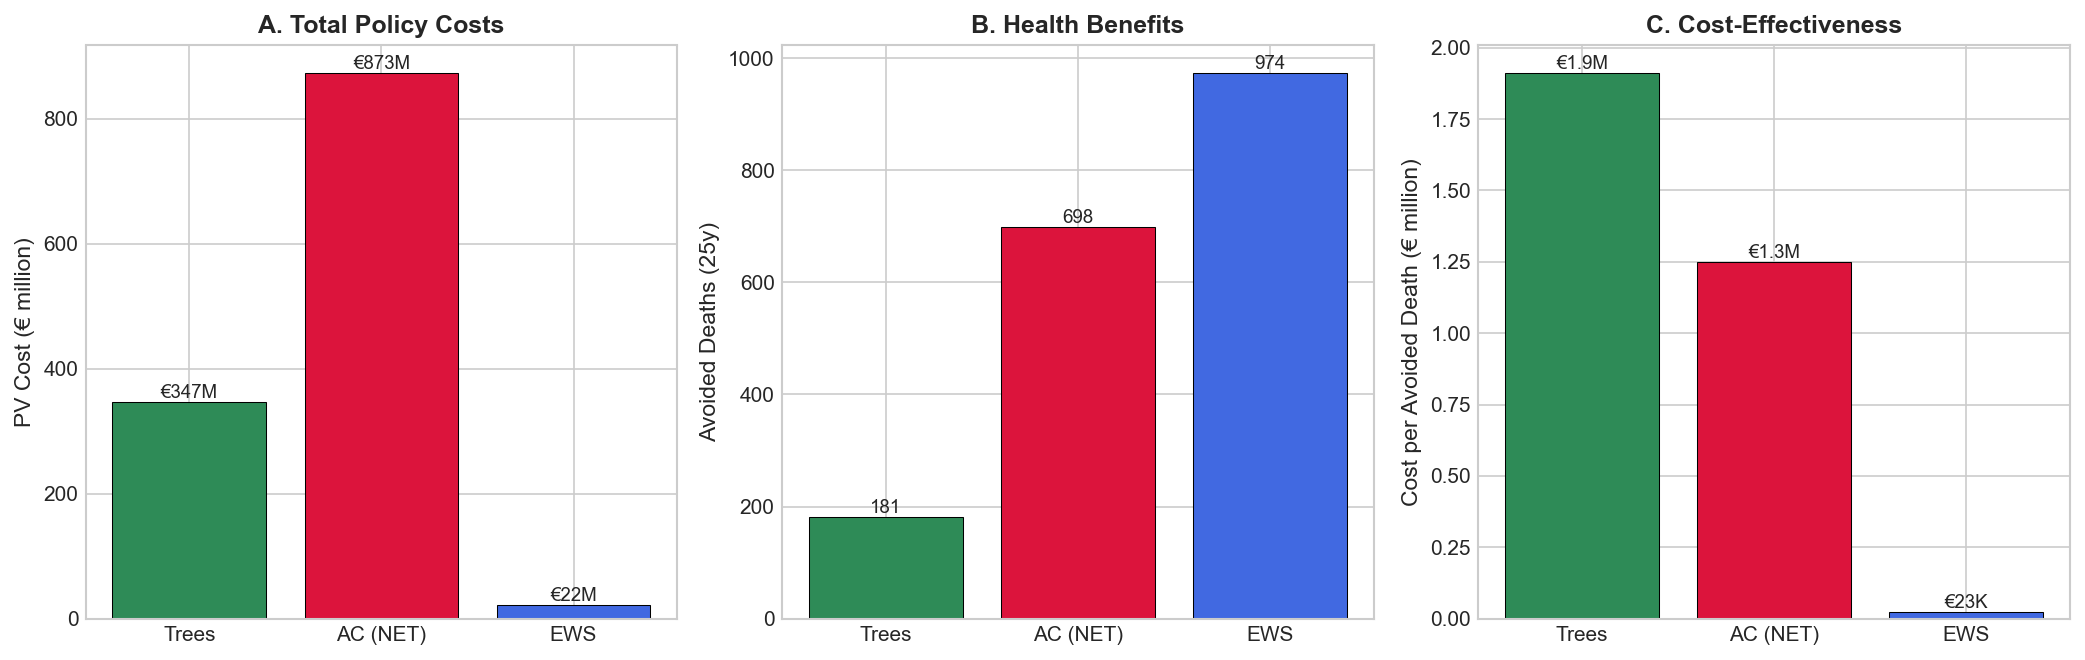

✓ Saved: rome_policy_comparison.png


In [51]:
# Figure 1: Policy Comparison - Costs and Benefits
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# Policy names and colors
policies = ["Trees", "AC (NET)", "EWS"]
colors = ["#2E8B57", "#DC143C", "#4169E1"]  

# Data
pv_costs = [PV_trees_total/1e6, PV_ac_total/1e6, PV_ews_total/1e6 if PV_ews_total > 0 else 0]
benefits = [CUM_trees, CUM_ac_net, CUM_ews]

# Cost per avoided death - raw values 
cost_per_death_raw = [
    safe_ratio(PV_trees_total, CUM_trees),
    safe_ratio(PV_ac_total, CUM_ac_net),
    safe_ratio(PV_ews_total, CUM_ews) if CUM_ews > 0 else 0
]

# For plotting, convert to millions
cost_per_death = [c/1e6 for c in cost_per_death_raw]

# Panel A: PV Costs
ax = axes[0]
bars = ax.bar(policies, pv_costs, color=colors, edgecolor='black', linewidth=0.5)
ax.set_ylabel("PV Cost (€ million)")
ax.set_title("A. Total Policy Costs", fontweight='bold')
for bar, val in zip(bars, pv_costs):
    ax.annotate(f'€{val:.0f}M', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=9)

# Panel B: Benefits
ax = axes[1]
bars = ax.bar(policies, benefits, color=colors, edgecolor='black', linewidth=0.5)
ax.set_ylabel("Avoided Deaths (25y)")
ax.set_title("B. Health Benefits", fontweight='bold')
for bar, val in zip(bars, benefits):
    ax.annotate(f'{val:.0f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=9)

# Panel C: Cost-Effectiveness 
ax = axes[2]
bars = ax.bar(policies, cost_per_death, color=colors, edgecolor='black', linewidth=0.5)
ax.set_ylabel("Cost per Avoided Death (€ million)")
ax.set_title("C. Cost-Effectiveness", fontweight='bold')

for bar, val_raw, val_M in zip(bars, cost_per_death_raw, cost_per_death):
    if val_raw > 0:
        # appropriate unit based on magnitude
        if val_raw < 100_000:  # Less than €100K - show in thousands
            label = f'€{val_raw/1e3:.0f}K'
        elif val_raw < 1_000_000:  # Less than €1M - show in thousands
            label = f'€{val_raw/1e3:.0f}K'
        else:  # €1M or more - show in millions
            label = f'€{val_M:.1f}M'
        
        ax.annotate(label, xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
fig.savefig(FIG_DIR / f"{SLUG}_policy_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {SLUG}_policy_comparison.png")

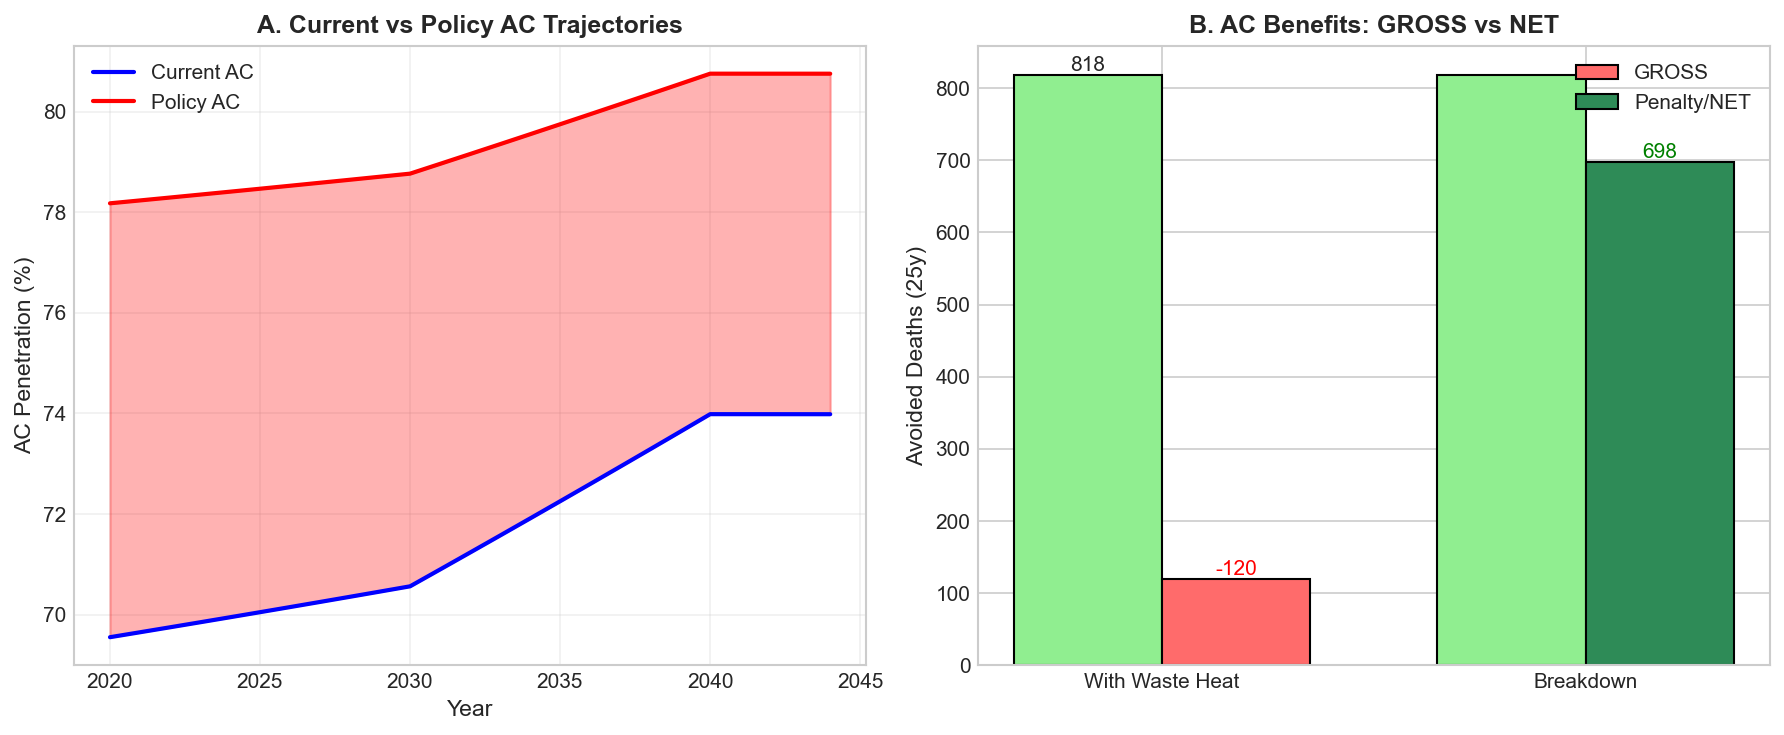

✓ Saved: rome_waste_heat_effect.png


In [52]:
# Figure 2: Waste Heat Feedback Effect
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: AC penetration over time
ax = axes[0]
ax.plot(YEARS, pen_current_t * 100, 'b-', linewidth=2, label='Current AC')
ax.plot(YEARS, pen_policy_t * 100, 'r-', linewidth=2, label='Policy AC')
ax.fill_between(YEARS, pen_current_t * 100, pen_policy_t * 100, alpha=0.3, color='red')
ax.set_xlabel("Year")
ax.set_ylabel("AC Penetration (%)")
ax.set_title("A. Current vs Policy AC Trajectories", fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel B: AC benefits breakdown
ax = axes[1]
width = 0.35
x = np.arange(2)

bars1 = ax.bar(x - width/2, [CUM_ac_gross, CUM_ac_gross], width, label='GROSS benefit', color='#90EE90', edgecolor='black')
bars2 = ax.bar(x + width/2, [CUM_penalty, CUM_ac_net], width, label=['Waste heat penalty', 'NET benefit'], 
               color=['#FF6B6B', '#2E8B57'], edgecolor='black')

ax.set_ylabel("Avoided Deaths (25y)")
ax.set_title("B. AC Benefits: GROSS vs NET", fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['With Waste Heat', 'Breakdown'])
ax.legend(['GROSS', 'Penalty/NET'], loc='upper right')

# Add annotations
ax.annotate(f'{CUM_ac_gross:.0f}', xy=(x[0] - width/2, CUM_ac_gross), ha='center', va='bottom', fontsize=10)
ax.annotate(f'-{CUM_penalty:.0f}', xy=(x[0] + width/2, CUM_penalty), ha='center', va='bottom', fontsize=10, color='red')
ax.annotate(f'{CUM_ac_net:.0f}', xy=(x[1] + width/2, CUM_ac_net), ha='center', va='bottom', fontsize=10, color='green')

plt.tight_layout()
fig.savefig(FIG_DIR / f"{SLUG}_waste_heat_effect.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {SLUG}_waste_heat_effect.png")


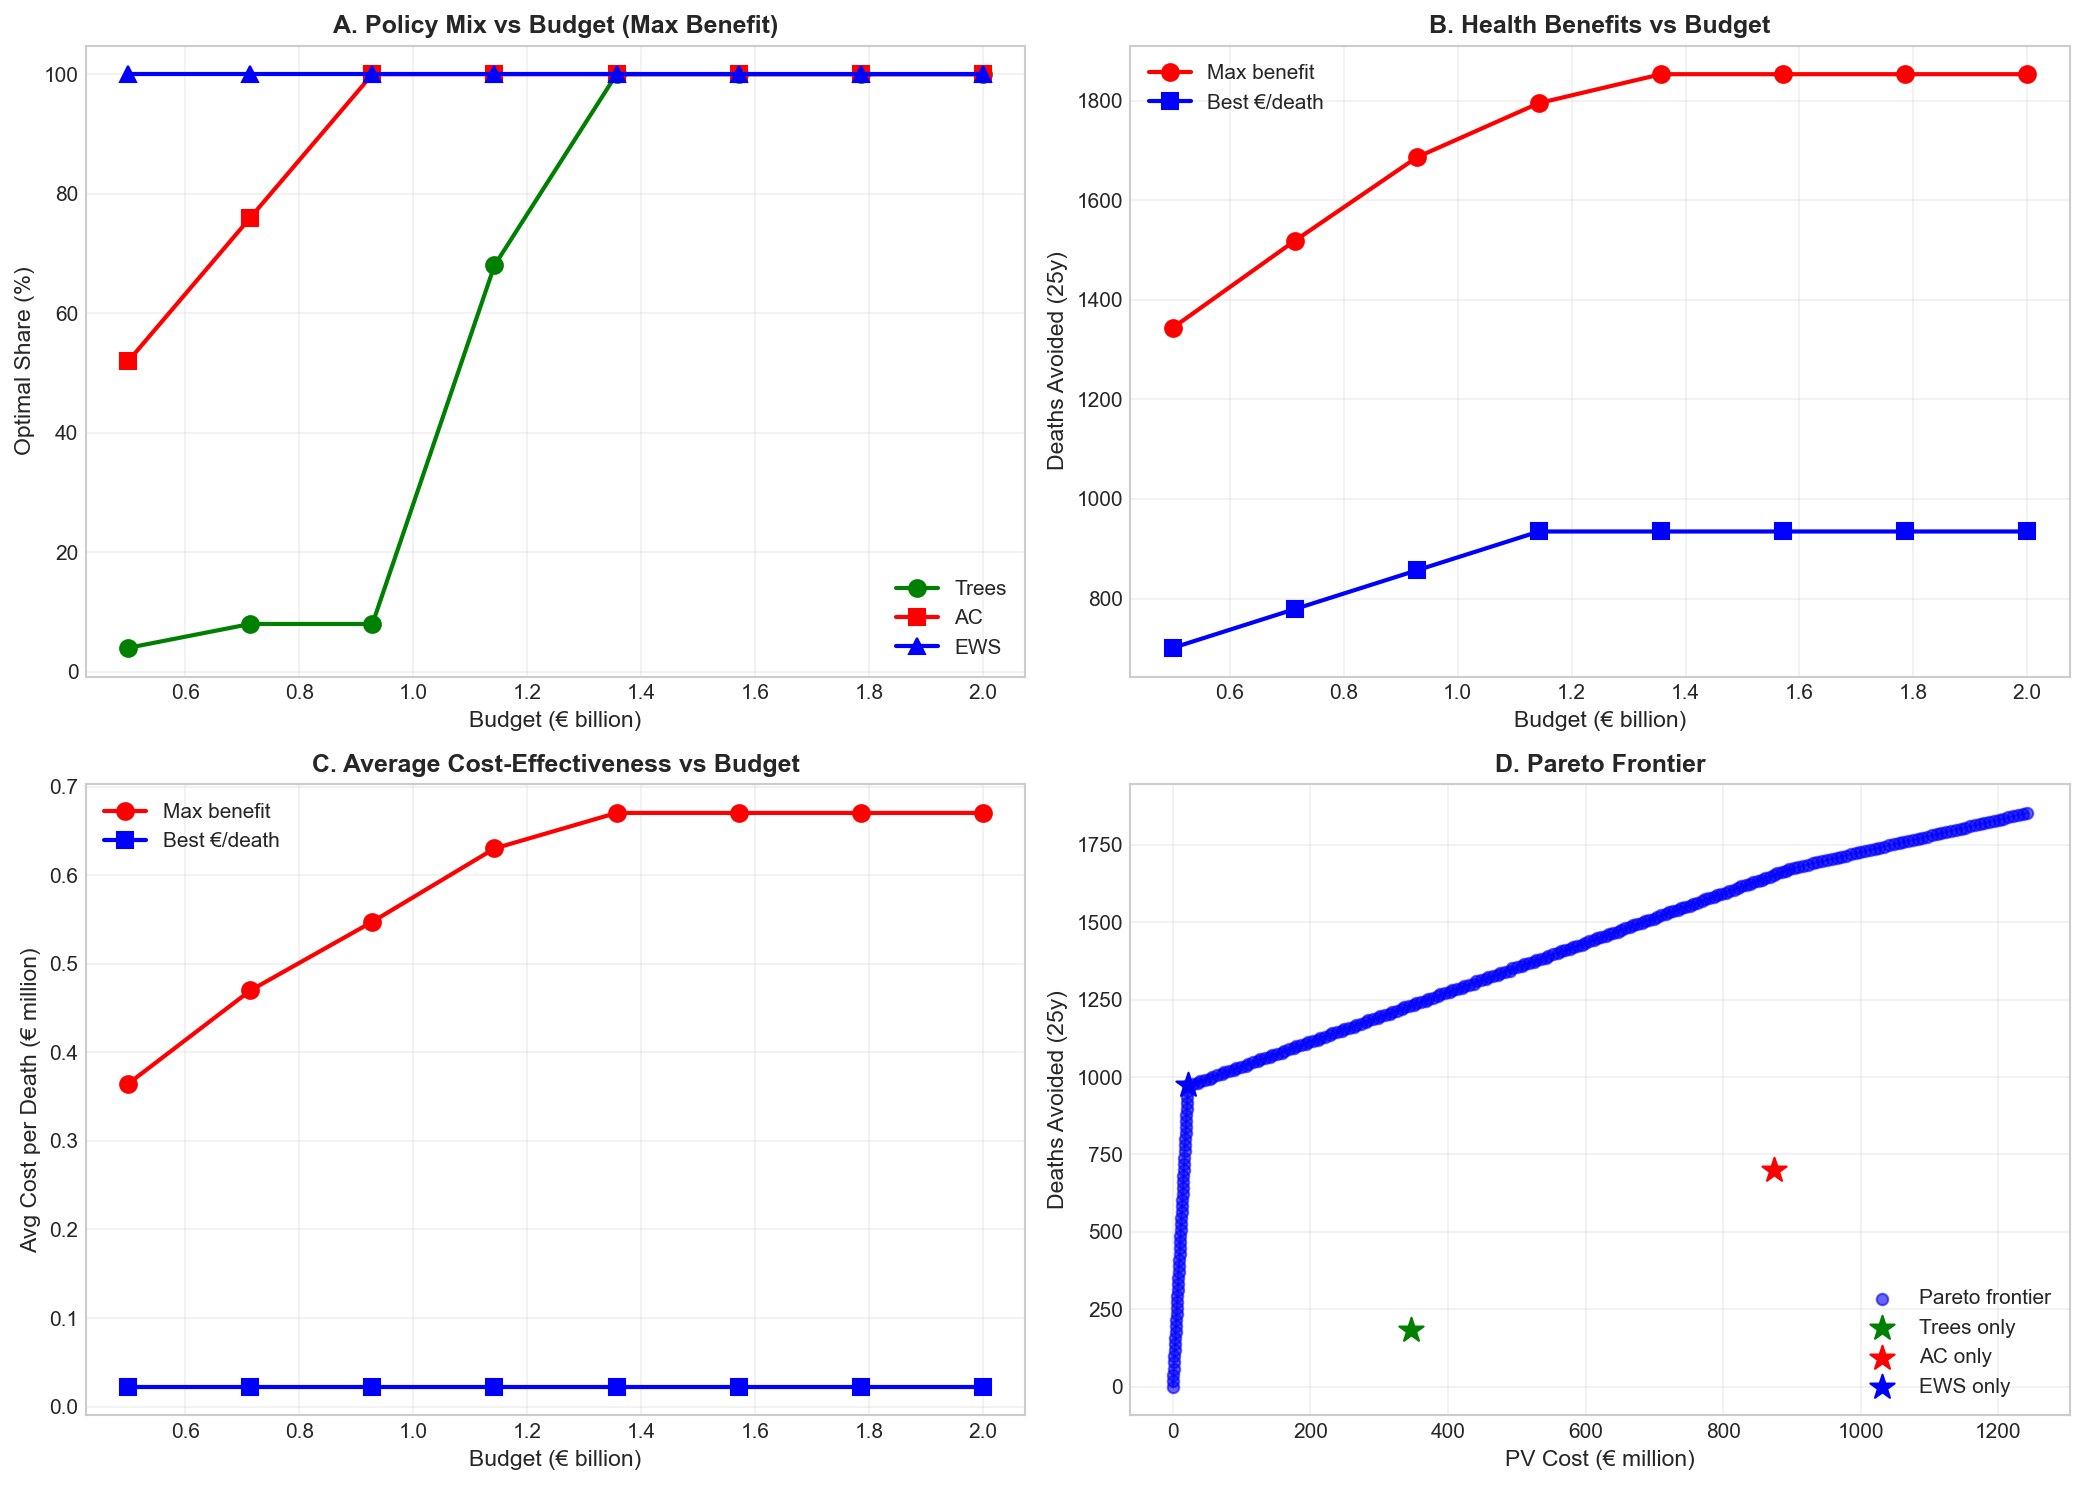

✓ Saved: rome_budget_optimization.png


In [53]:
# Figure 3: Budget Optimization
if not sens_df.empty:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Panel A: Optimal policy mix vs budget (max benefit)
    ax = axes[0, 0]
    ax.plot(sens_df["budget"]/1e9, sens_df["max_ben_trees"]*100, 'g-o', linewidth=2, markersize=8, label='Trees')
    ax.plot(sens_df["budget"]/1e9, sens_df["max_ben_ac"]*100, 'r-s', linewidth=2, markersize=8, label='AC')
    ax.plot(sens_df["budget"]/1e9, sens_df["max_ben_ews"]*100, 'b-^', linewidth=2, markersize=8, label='EWS')
    ax.set_xlabel("Budget (€ billion)")
    ax.set_ylabel("Optimal Share (%)")
    ax.set_title("A. Policy Mix vs Budget (Max Benefit)", fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Panel B: Benefits vs budget
    ax = axes[0, 1]
    ax.plot(sens_df["budget"]/1e9, sens_df["max_benefit"], 'r-o', linewidth=2, markersize=8, label='Max benefit')
    ax.plot(sens_df["budget"]/1e9, sens_df["best_ce_benefit"], 'b-s', linewidth=2, markersize=8, label='Best €/death')
    ax.set_xlabel("Budget (€ billion)")
    ax.set_ylabel("Deaths Avoided (25y)")
    ax.set_title("B. Health Benefits vs Budget", fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Panel C: Cost-effectiveness vs budget
    ax = axes[1, 0]
    sens_df["max_avg_ce"] = sens_df["max_cost"] / sens_df["max_benefit"]
    sens_df["best_avg_ce"] = sens_df["best_ce_cost"] / sens_df["best_ce_benefit"]
    
    ax.plot(sens_df["budget"]/1e9, sens_df["max_avg_ce"]/1e6, 'r-o', linewidth=2, markersize=8, label='Max benefit')
    ax.plot(sens_df["budget"]/1e9, sens_df["best_avg_ce"]/1e6, 'b-s', linewidth=2, markersize=8, label='Best €/death')
    ax.set_xlabel("Budget (€ billion)")
    ax.set_ylabel("Avg Cost per Death (€ million)")
    ax.set_title("C. Average Cost-Effectiveness vs Budget", fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Panel D: Pareto frontier 
    ax = axes[1, 1]
    if 'pareto_df' in dir() and not pareto_df.empty:
        ax.scatter(pareto_df["PV_cost"]/1e6, pareto_df["benefit_deaths"], 
                   c='blue', s=30, alpha=0.6, label='Pareto frontier')
        ax.plot(pareto_df["PV_cost"]/1e6, pareto_df["benefit_deaths"], 
                'b-', linewidth=1, alpha=0.5)
    
    # adding reference points for pure policies
    ax.scatter([PV_trees_total/1e6], [CUM_trees], c='green', s=150, marker='*', 
               zorder=5, label='Trees only')
    ax.scatter([PV_ac_total/1e6], [CUM_ac_net], c='red', s=150, marker='*', 
               zorder=5, label='AC only')
    if PV_ews_total > 0:
        ax.scatter([PV_ews_total/1e6], [CUM_ews], c='blue', s=150, marker='*', 
                   zorder=5, label='EWS only')
    
    ax.set_xlabel("PV Cost (€ million)")
    ax.set_ylabel("Deaths Avoided (25y)")
    ax.set_title("D. Pareto Frontier", fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    fig.savefig(FIG_DIR / f"{SLUG}_budget_optimization.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {SLUG}_budget_optimization.png")


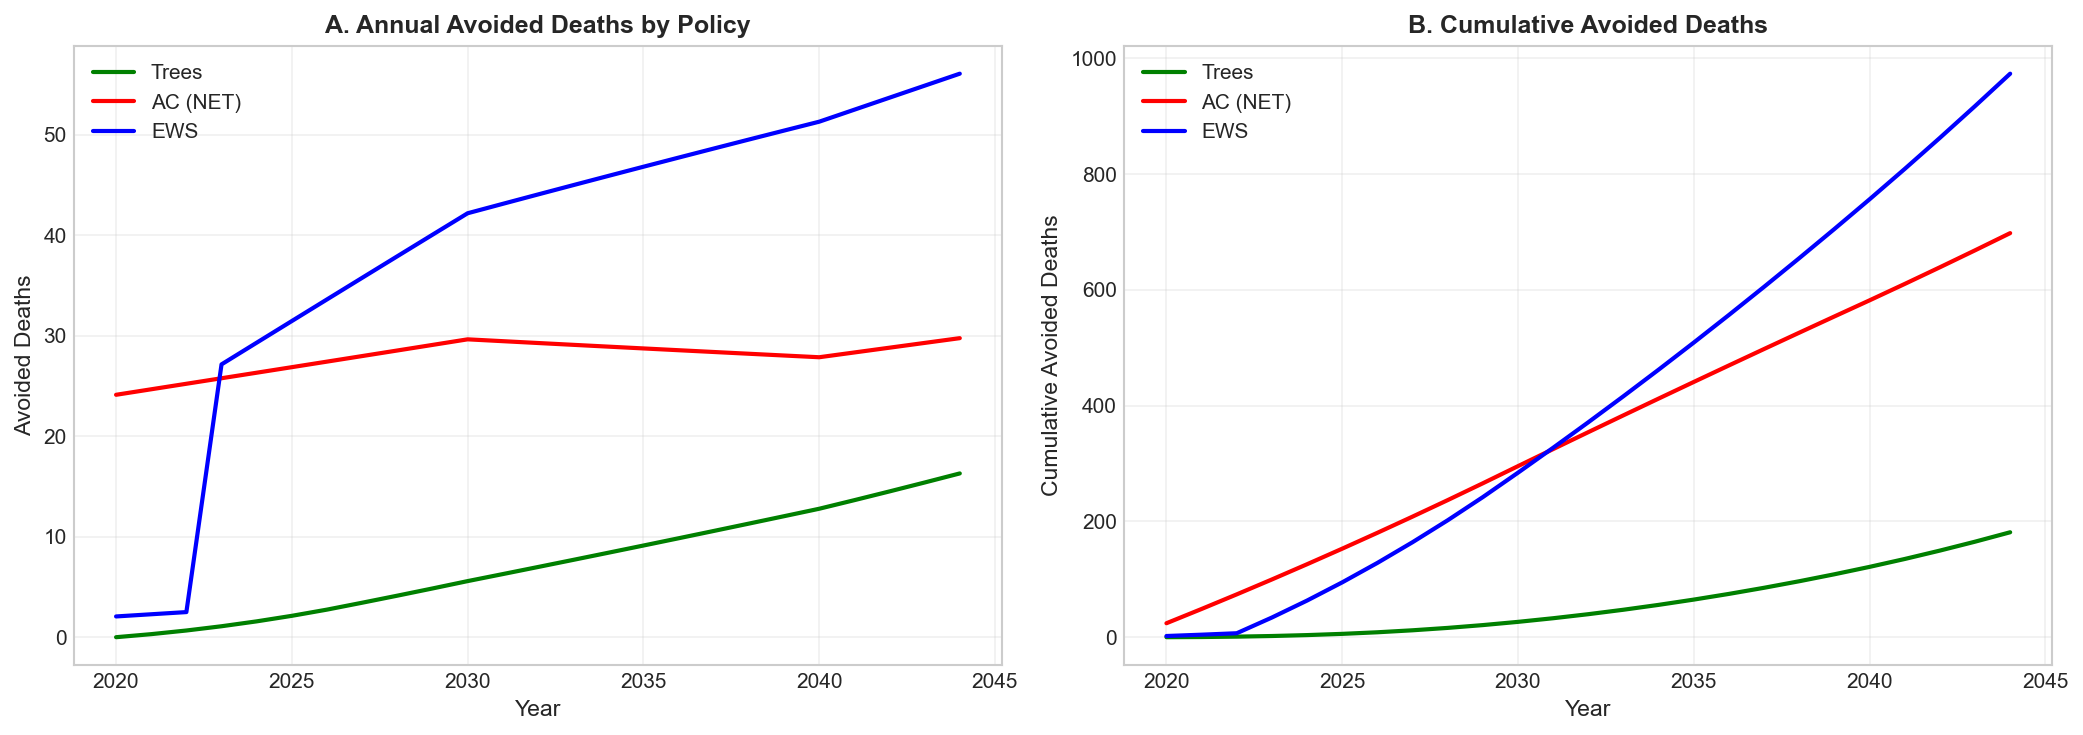

✓ Saved: rome_benefits_timeseries.png


In [54]:
# Figure 4: Time Series of Benefits
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: Annual avoided deaths by policy
ax = axes[0]
ax.plot(YEARS, trees_only_25y, 'g-', linewidth=2, label='Trees')
ax.plot(YEARS, ac_net_25y, 'r-', linewidth=2, label='AC (NET)')
ax.plot(YEARS, ews_25y, 'b-', linewidth=2, label='EWS')
ax.set_xlabel("Year")
ax.set_ylabel("Avoided Deaths")
ax.set_title("A. Annual Avoided Deaths by Policy", fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel B: Cumulative avoided deaths
ax = axes[1]
ax.plot(YEARS, np.cumsum(trees_only_25y), 'g-', linewidth=2, label='Trees')
ax.plot(YEARS, np.cumsum(ac_net_25y), 'r-', linewidth=2, label='AC (NET)')
ax.plot(YEARS, np.cumsum(ews_25y), 'b-', linewidth=2, label='EWS')
ax.set_xlabel("Year")
ax.set_ylabel("Cumulative Avoided Deaths")
ax.set_title("B. Cumulative Avoided Deaths", fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(FIG_DIR / f"{SLUG}_benefits_timeseries.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {SLUG}_benefits_timeseries.png")


# SECTION 11: OUTPUTS AND FINAL SUMMARY

In [55]:
print("\n" + "="*70)
print("SECTION 11: OUTPUTS AND FINAL SUMMARY")
print("="*70)

# Save all key outputs
outputs = {}

# 1. Cost summary
outputs["costs"] = {
    "trees": {
        "pv_capex": float(PV_trees_capex),
        "pv_om_base": float(PV_trees_om),
        "pv_om_5x": float(PV_trees_om_5x),
        "pv_total_base": float(PV_trees_total),
        "pv_total_5x": float(PV_trees_total_5x),
        "eac_base": float(EAC_trees),
        "eac_5x": float(EAC_trees_5x),
    },
    "ac": {
        "pv_capex": float(PV_ac_capex),
        "pv_maint": float(PV_ac_maint),
        "pv_elec": float(PV_ac_elec),
        "pv_elec_no_veg": float(PV_ac_elec_no_veg),
        "pv_elec_veg_saving": float(PV_ac_elec_veg_saving),
        "pv_total": float(PV_ac_total),
        "eac": float(EAC_ac_total),
        "added_users_final": float(added_users_final),
    },
    "ac_with_trees_interaction": {
        "pv_capex": float(PV_ac_capex),
        "pv_maint": float(PV_ac_maint),
        "pv_elec": float(PV_ac_elec_with_trees),
        "pv_total": float(PV_ac_total_with_trees),
        "eac": float(EAC_ac_total_with_trees),
        "added_users_final": float(added_users_final),
    },
    "ews": {
        "pv_total": float(PV_ews_total),
        "eac": float(EAC_ews),
    }
}

# 2. Benefits summary
trees_benefits_dict = {
    "avoided_deaths_25y": float(CUM_trees),
    "on_top_of_ac_25y": float(trees_on_top_25y.sum()),
}

outputs["benefits"] = {
    "trees": trees_benefits_dict,
    "ac": {
        "gross_25y": float(CUM_ac_gross),
        "net_25y": float(CUM_ac_net),
        "waste_heat_penalty_25y": float(CUM_penalty),
    },
    "ac_with_trees_interaction": {
        "gross_25y": float(CUM_ac_gross),
        "net_25y": float(CUM_ac_net_with_trees),
        "waste_heat_penalty_25y": float(CUM_penalty_with_trees),
    },
    "ews": {
        "avoided_deaths_25y": float(CUM_ews),
    }
}

# 3. Cost-effectiveness
ce_dict = {
    "trees_base": float(safe_ratio(PV_trees_total, CUM_trees)),
    "trees_5x": float(safe_ratio(PV_trees_total_5x, CUM_trees)),
    "ac_net": float(safe_ratio(PV_ac_total, CUM_ac_net)),
    "ac_net_with_trees": float(safe_ratio(PV_ac_total_with_trees, CUM_ac_net_with_trees)),
    "ac_gross": float(safe_ratio(PV_ac_total, CUM_ac_gross)),
    "ews": float(safe_ratio(PV_ews_total, CUM_ews)) if CUM_ews > 0 else None,
}
outputs["cost_effectiveness"] = ce_dict

# 4. Vegetation feedbacks
outputs["vegetation_feedbacks"] = {
    "falchetta_electricity": {
        "enabled": ELEC_FB_ENABLED,
        "pct_per_gvi_point": float(VEG_ELEC_PCT_PER_PT),
        "summer_fraction": float(VEG_ELEC_SUMMER_FRAC),
        "pv_ac_elec_saving": float(PV_ac_elec_veg_saving),
        "pv_ac_elec_saving_incremental_users": float(PV_ac_elec_veg_saving),
        "pv_total_elec_saving_all_users": float(PV_veg_eur_all),
        "pv_tree_elec_saving_current_ac_users": float(PV_veg_eur_base),
        "pv_tree_elec_saving_all_policy_ac_users": float(PV_veg_eur_all),
        "cum_kwh_saved_25y": float(CUM_veg_kwh_all),
        "cum_kwh_saved_current_ac_users_25y": float(CUM_veg_kwh_base),
        "cum_kwh_saved_all_policy_ac_users_25y": float(CUM_veg_kwh_all),
        "cum_co2_avoided_t_25y": float(CUM_veg_co2_t),
        "cum_co2_avoided_current_ac_users_t_25y": float(CUM_veg_co2_base_t),
        "cum_co2_avoided_all_policy_ac_users_t_25y": float(CUM_veg_co2_t),
        "tree_cost_coverage_current_ac_users_pct": float(100.0 * PV_veg_eur_base / max(PV_trees_total, 1e-6)),
        "tree_cost_coverage_all_policy_ac_users_pct": float(100.0 * PV_veg_eur_all / max(PV_trees_total, 1e-6)),
        "co2_intensity_gCO2_per_kwh": float(VEG_CO2_gCO2_PER_KWH),
    },
    "lambda_y_waste_heat": {
        "enabled": LAMBDA_Y_ENABLED,
        "mean_lambda": float(lambda_y_t.mean()),
        "lambda_year_0": float(lambda_y_t[0]),
        "lambda_year_final": float(lambda_y_t[-1]),
        "penalty_standalone_25y": float(CUM_penalty),
        "penalty_with_trees_25y": float(CUM_penalty_with_trees),
    },
}

# 5. Parameters
outputs["parameters"] = {
    "discount_rate": R,
    "horizon_years": T,
    "tree_maturity_years": TREE_RAMP_YEARS,
    "tree_start_age": TREE_START_AGE_CENTRAL,
    "delta_gvi": float(DELTA_INDEX),
    "waste_heat_case": DELTA_T_CASE,
    "waste_heat_enabled": USE_AC_FEEDBACK,
}

# Save to JSON
output_path = TAB_DIR / f"{SLUG}_cba_summary.json"
with open(output_path, "w") as f:
    json.dump(outputs, f, indent=2)
print(f"  Saved: {output_path.name}")



SECTION 11: OUTPUTS AND FINAL SUMMARY
  Saved: rome_cba_summary.json


In [56]:
# Final summary print
print("\n" + "="*70)
print("FINAL CBA SUMMARY")
print("="*70)

print(f"\nCity: {CITY}")
print(f"Horizon: {T} years ({START_YEAR}-{START_YEAR + T - 1})")
print(f"Discount rate: {R*100:.0f}%")

print(f"\n{'='*70}")
print("COSTS (25-year PV)")
print(f"{'='*70}")
print(f"  Trees (base O&M):     €{PV_trees_total/1e6:>10.1f}M")
print(f"  Trees (5× O&M):       €{PV_trees_total_5x/1e6:>10.1f}M")
print(f"  AC:                   €{PV_ac_total/1e6:>10.1f}M")
print(f"  EWS:                  €{PV_ews_total/1e6:>10.1f}M")

print(f"\n{'='*70}")
print("BENEFITS (Avoided Deaths, 25-year)")
print(f"{'='*70}")
print(f"  Trees only:           {CUM_trees:>10.1f}")
print(f"  AC GROSS:             {CUM_ac_gross:>10.1f}")
print(f"  AC NET:               {CUM_ac_net:>10.1f}  (penalty: -{CUM_penalty:.1f})")
print(f"  EWS:                  {CUM_ews:>10.1f}")

print(f"\n{'='*70}")
print("COST-EFFECTIVENESS (€/Avoided Death)")
print(f"{'='*70}")
print(f"  Trees (base O&M):     €{safe_ratio(PV_trees_total, CUM_trees)/1e6:>10.1f}M")
print(f"  Trees (5× O&M):       €{safe_ratio(PV_trees_total_5x, CUM_trees)/1e6:>10.1f}M")
print(f"  AC (NET):             €{safe_ratio(PV_ac_total, CUM_ac_net)/1e6:>10.1f}M")
ews_cpd = safe_ratio(PV_ews_total, CUM_ews)
ews_cpd_str = f"€{ews_cpd/1e3:.0f}K" if ews_cpd < 1_000_000 else f"€{ews_cpd/1e6:.1f}M"
print(f"  EWS:                  {ews_cpd_str:>10}")

print(f"\n{'='*70}")
print("KEY FINDINGS")
print(f"{'='*70}")

# Rank policies by cost-effectiveness
policies_ce = [
    ("Trees (base)", safe_ratio(PV_trees_total, CUM_trees)),
    ("AC (NET)", safe_ratio(PV_ac_total, CUM_ac_net)),
    ("EWS", safe_ratio(PV_ews_total, CUM_ews) if CUM_ews > 0 else np.inf),
]
policies_ce.sort(key=lambda x: x[1])

print(f"\n1. Most cost-effective: {policies_ce[0][0]} (€{policies_ce[0][1]/1e6:.1f}M/death)")
print(f"   Least cost-effective: {policies_ce[-1][0]} (€{policies_ce[-1][1]/1e6:.1f}M/death)")

print(f"\n2. Waste heat reduces AC benefits by {100*(CUM_ac_gross - CUM_ac_net)/CUM_ac_gross:.0f}%")
print(f"   ({CUM_ac_gross:.0f} GROSS → {CUM_ac_net:.0f} NET)")

if not sens_df.empty:
    mb = sens_df.iloc[-1]
    print(f"\n3. At €{mb['budget']/1e9:.1f}B budget, max benefit mix:")
    print(f"   Trees: {mb['max_ben_trees']*100:.0f}%, AC: {mb['max_ben_ac']*100:.0f}%, EWS: {mb['max_ben_ews']*100:.0f}%")
    print(f"   → {mb['max_benefit']:.0f} deaths avoided")

print(f"\n{'='*70}")
print("NB8 CBA COMPLETE")
print(f"{'='*70}")

# List all output files
print("\nOutput files:")
for f in TAB_DIR.glob(f"{SLUG}_*.csv"):
    print(f"  {f.name}")
for f in TAB_DIR.glob(f"{SLUG}_*.json"):
    print(f"  {f.name}")
for f in FIG_DIR.glob(f"{SLUG}_*.png"):
    print(f"  {f.name}")



FINAL CBA SUMMARY

City: Rome
Horizon: 25 years (2020-2044)
Discount rate: 3%

COSTS (25-year PV)
  Trees (base O&M):     €     346.7M
  Trees (5× O&M):       €     965.6M
  AC:                   €     873.5M
  EWS:                  €      22.0M

BENEFITS (Avoided Deaths, 25-year)
  Trees only:                181.3
  AC GROSS:                  818.2
  AC NET:                    698.2  (penalty: -120.0)
  EWS:                       973.7

COST-EFFECTIVENESS (€/Avoided Death)
  Trees (base O&M):     €       1.9M
  Trees (5× O&M):       €       5.3M
  AC (NET):             €       1.3M
  EWS:                        €23K

KEY FINDINGS

1. Most cost-effective: EWS (€0.0M/death)
   Least cost-effective: Trees (base) (€1.9M/death)

2. Waste heat reduces AC benefits by 15%
   (818 GROSS → 698 NET)

3. At €2.0B budget, max benefit mix:
   Trees: 100%, AC: 100%, EWS: 100%
   → 1853 deaths avoided

NB8 CBA COMPLETE

Output files:
  rome_cea_summary.csv
  rome_policy_effectiveness.csv
  rome_mass